# **INIT LIBRARY**

In [1]:
# =========================
# 0) Init Library (Baseline - Official)
# =========================

import os, sys, re, json, math, random, warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Optional, Dict, Any, List, Tuple

import numpy as np
import pandas as pd

# (opsional) progress bar
from tqdm.auto import tqdm

# (opsional) ML util dasar
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Torch optional (kalau nanti SSL / deep regressor)
try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(SEED)
    if DEVICE == "cuda":
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except Exception:
    torch = None
    DEVICE = "cpu"

print("Init OK")
print("SEED  :", SEED)
print("DEVICE:", DEVICE)
print("pandas:", pd.__version__)
print("numpy :", np.__version__)
print("sklearn:", __import__("sklearn").__version__)
if torch is not None:
    print("torch :", torch.__version__)


e:\tugas-akhir-qiqi\venv_infer\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Init OK
SEED  : 42
DEVICE: cpu
pandas: 3.0.0
numpy : 2.3.5
sklearn: 1.8.0
torch : 2.10.0+cpu


# **SETUP PATH + LOAD METADATA (EXCLUDE VAD DROP)**


In [2]:
# =========================
# 1) Setup path + Load metadata (official) + Exclude VAD drop
# =========================

CWD = Path.cwd().resolve()
ROOT = CWD.parent.parent
PREP_DIR = ROOT / "output" / "preprocessing"

print("ROOT    :", ROOT)
print("PREP_DIR:", PREP_DIR)

# --- load metadata official
train_path = PREP_DIR / "meta_train_official.csv"
val_path   = PREP_DIR / "meta_val_official.csv"
test_path  = PREP_DIR / "meta_test_official.csv"

df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)
df_test  = pd.read_csv(test_path)

print("\n[Loaded official metadata]")
print("Train:", df_train.shape, "| Val:", df_val.shape, "| Test:", df_test.shape)


# load vad drop 
VAD_DROP = ROOT / "output" / "preprocessing" / "vad" / "vad_drop.csv"

def exclude_vad_drop(df: pd.DataFrame, vad_drop_path: Path) -> pd.DataFrame:
    drop_path = pd.read_csv(vad_drop_path)
    initial_len = len(df)
    df = df[~df["clip_id"].isin(drop_path["clip_id"].values)].reset_index(drop=True)
    final_len = len(df)
    print(f"Excluded {initial_len - final_len} samples due to VAD drop.")
    print(f"New shape: {df.shape}")
    print(f"Size before drop: {initial_len}, size after drop: {final_len}\n")
    return df

df_train = exclude_vad_drop(df_train, VAD_DROP)
df_val   = exclude_vad_drop(df_val, VAD_DROP)
df_test  = exclude_vad_drop(df_test, VAD_DROP)




ROOT    : E:\tugas-akhir-qiqi
PREP_DIR: E:\tugas-akhir-qiqi\output\preprocessing

[Loaded official metadata]
Train: (6000, 13) | Val: (2000, 13) | Test: (2000, 13)
Excluded 12 samples due to VAD drop.
New shape: (5988, 13)
Size before drop: 6000, size after drop: 5988

Excluded 6 samples due to VAD drop.
New shape: (1994, 13)
Size before drop: 2000, size after drop: 1994

Excluded 8 samples due to VAD drop.
New shape: (1992, 13)
Size before drop: 2000, size after drop: 1992



# **REUSE EMBEDDING V1 - HUBERT**

In [5]:
# =========================
# 2) Reuse embedding dari baseline_official -> align ke STRICT split (by clip_id)
# =========================

import numpy as np
import pandas as pd
from pathlib import Path

assert "ROOT" in globals()
assert "df_train" in globals() and "df_val" in globals() and "df_test" in globals()

BACKBONE_KEY = "hubert"   # ganti: "wav2vec2" / "wavlm"

# lokasi embedding yang sudah ada (official)
EMB_DIR_OFF = ROOT / "output" / "V1" / "baseline_official" / "embeddings" / BACKBONE_KEY
assert EMB_DIR_OFF.exists(), f"Folder embedding official tidak ada: {EMB_DIR_OFF}"

def load_official_split(split: str):
    X = np.load(EMB_DIR_OFF / f"{split}_emb.npy", mmap_mode="r")
    ids = pd.read_csv(EMB_DIR_OFF / f"{split}_clip_id.csv")["clip_id"].astype(str).tolist()
    return X, ids

# load pool embedding dari official train/val/test
X_off = {}
ids_off = {}

for split in ["train", "val", "test"]:
    X_off[split], ids_off[split] = load_official_split(split)
    print(f"[OFFICIAL] {split}: X={X_off[split].shape} ids={len(ids_off[split])}")

# build mapping clip_id -> (split, idx)
id2loc = {}
dup = 0
for split in ["train", "val", "test"]:
    for i, cid in enumerate(ids_off[split]):
        if cid in id2loc:
            dup += 1
        id2loc[cid] = (split, i)

if dup > 0:
    print(f"[WARN] Duplicated clip_id across official splits: {dup} (harusnya 0).")

H = int(X_off["train"].shape[1])
print("Hidden size (H):", H)

def build_X_from_strict(df_split: pd.DataFrame, name: str):
    ids = df_split["clip_id"].astype(str).tolist()
    X = np.zeros((len(ids), H), dtype=np.float32)

    missing = []
    for j, cid in enumerate(ids):
        loc = id2loc.get(cid)
        if loc is None:
            missing.append(cid)
            continue
        sp, i = loc
        X[j] = X_off[sp][i]  # ambil dari memmap official

    if missing:
        print(f"[WARN] {name}: missing embeddings = {len(missing)} / {len(ids)} (contoh 5): {missing[:5]}")
        # kalau kamu mau strict fail biar ketahuan:
        # raise ValueError(f"Missing embeddings in {name}: {len(missing)}")

    print(f"[STRICT] {name}: X={X.shape} ids={len(ids)}")
    return X, ids

# align ke strict split
X_train, train_ids = build_X_from_strict(df_train, "train")
X_val,   val_ids   = build_X_from_strict(df_val,   "val")
X_test,  test_ids  = build_X_from_strict(df_test,  "test")

# (opsional) cache ulang supaya notebook strict mirip baseline official
OFFICIAL_EMB_DIR = ROOT / "output" / "V2" / "baseline_official" / "embeddings" / BACKBONE_KEY
OFFICIAL_EMB_DIR.mkdir(parents=True, exist_ok=True)

np.save(OFFICIAL_EMB_DIR / "train_emb.npy", X_train)
np.save(OFFICIAL_EMB_DIR / "val_emb.npy",   X_val)
np.save(OFFICIAL_EMB_DIR / "test_emb.npy",  X_test)

pd.DataFrame({"clip_id": train_ids}).to_csv(OFFICIAL_EMB_DIR / "train_clip_id.csv", index=False)
pd.DataFrame({"clip_id": val_ids}).to_csv(OFFICIAL_EMB_DIR / "val_clip_id.csv", index=False)
pd.DataFrame({"clip_id": test_ids}).to_csv(OFFICIAL_EMB_DIR / "test_clip_id.csv", index=False)

print("Saved embeddings to:", OFFICIAL_EMB_DIR)


[OFFICIAL] train: X=(5988, 768) ids=5988
[OFFICIAL] val: X=(1994, 768) ids=1994
[OFFICIAL] test: X=(1992, 768) ids=1992
Hidden size (H): 768
[STRICT] train: X=(5988, 768) ids=5988
[STRICT] val: X=(1994, 768) ids=1994
[STRICT] test: X=(1992, 768) ids=1992
Saved embeddings to: E:\tugas-akhir-qiqi\output\V2\baseline_official\embeddings\hubert


X_train: (5988, 768) | X_val: (1994, 768) | X_test: (1992, 768)
Label cols: ['extraversion', 'neuroticism', 'agreeableness', 'conscientiousness', 'openness']
alpha=    0.001 | val MAE=0.099668 | val Acc=0.900332 | val RMSE=0.125557 | val R2=0.240877
alpha=    0.003 | val MAE=0.099667 | val Acc=0.900333 | val RMSE=0.125557 | val R2=0.240882
alpha=     0.01 | val MAE=0.099666 | val Acc=0.900334 | val RMSE=0.125556 | val R2=0.240896
alpha=     0.03 | val MAE=0.099664 | val Acc=0.900336 | val RMSE=0.125552 | val R2=0.240936
alpha=      0.1 | val MAE=0.099656 | val Acc=0.900344 | val RMSE=0.125542 | val R2=0.241064
alpha=      0.3 | val MAE=0.099632 | val Acc=0.900368 | val RMSE=0.125511 | val R2=0.241431
alpha=        1 | val MAE=0.099554 | val Acc=0.900446 | val RMSE=0.125408 | val R2=0.242669
alpha=        3 | val MAE=0.099357 | val Acc=0.900643 | val RMSE=0.125147 | val R2=0.245791
alpha=       10 | val MAE=0.098862 | val Acc=0.901138 | val RMSE=0.124493 | val R2=0.253604
alpha=       3

,split,trait,Acc(1-MAE),MAE,RMSE,R2
0,val,extraversion,0.902301,0.097699,0.121477,0.324524
1,val,neuroticism,0.903291,0.096709,0.121568,0.338137
2,val,agreeableness,0.909544,0.090456,0.115469,0.176252
3,val,conscientiousness,0.900503,0.099497,0.125963,0.344237
4,val,openness,0.904624,0.095376,0.119500,0.303570
5,val,mean,0.904053,0.095947,0.120795,0.297344



== hubert | BASELINE_OFFICIAL | TEST ==


,split,trait,Acc(1-MAE),MAE,RMSE,R2
0,test,extraversion,0.900828,0.099172,0.123520,0.317287
1,test,neuroticism,0.900854,0.099146,0.124455,0.336162
2,test,agreeableness,0.904803,0.095197,0.119822,0.185865
3,test,conscientiousness,0.901100,0.098900,0.123793,0.336354
4,test,openness,0.905044,0.094956,0.118129,0.328589
5,test,mean,0.902526,0.097474,0.121944,0.300851


,trait,target_mean,target_std,target_var,pred_mean,pred_std,pred_std_over_target_std,MAE_model,RMSE_model,R2_model,MAE_naive_train_mean,RMSE_naive_train_mean,R2_naive_train_mean,RMSE_improvement_vs_naive,RMSE_over_target_std
0,extraversion,0.478489,0.149493,0.022348,0.475267,0.092060,0.615817,0.099172,0.123520,0.317287,0.121490,0.149510,-0.000230,0.025989,0.826265
1,neuroticism,0.522392,0.152750,0.023333,0.518329,0.092548,0.605878,0.099146,0.124455,0.336162,0.122308,0.152762,-0.000156,0.028307,0.814763
2,agreeableness,0.552341,0.132797,0.017635,0.546146,0.064657,0.486883,0.095197,0.119822,0.185865,0.106054,0.132856,-0.000886,0.013034,0.902294
3,conscientiousness,0.526017,0.151960,0.023092,0.520339,0.093377,0.614484,0.098900,0.123793,0.336354,0.124981,0.151992,-0.000426,0.028199,0.814644
4,openness,0.568753,0.144165,0.020784,0.565899,0.085817,0.595265,0.094956,0.118129,0.328589,0.116458,0.144185,-0.000270,0.026056,0.819397


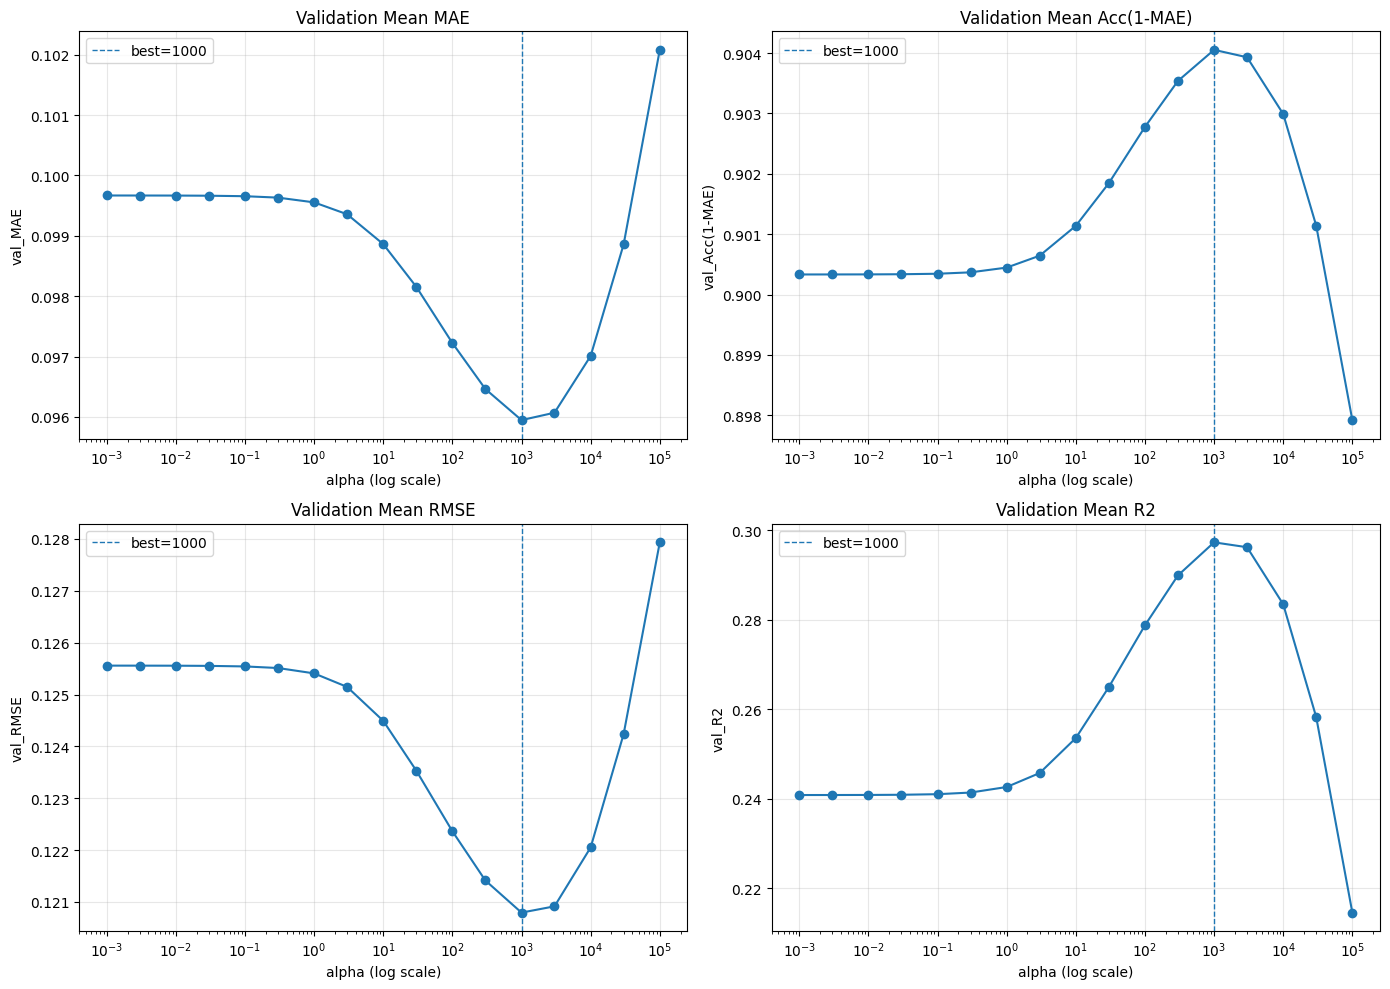

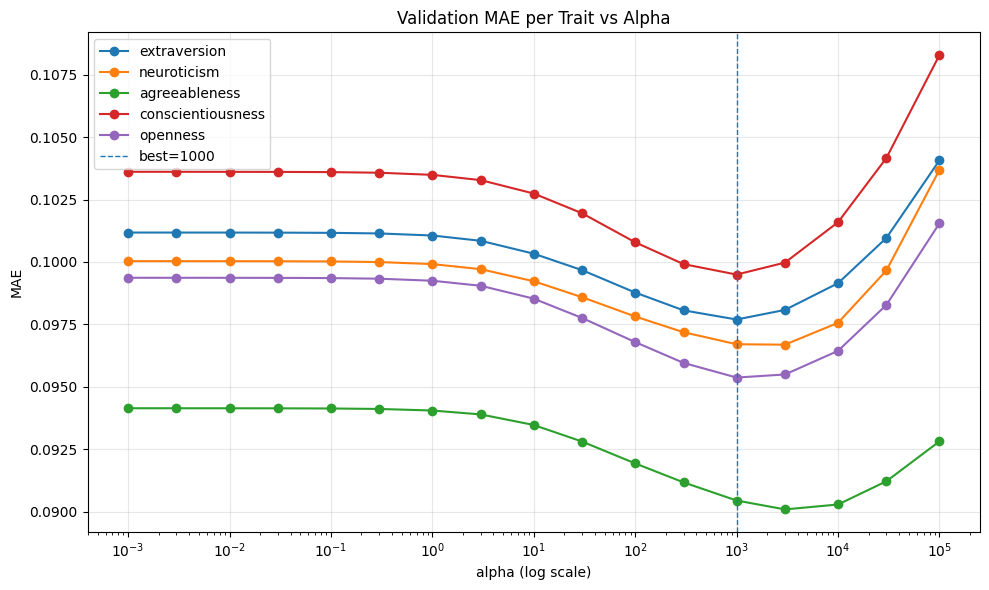

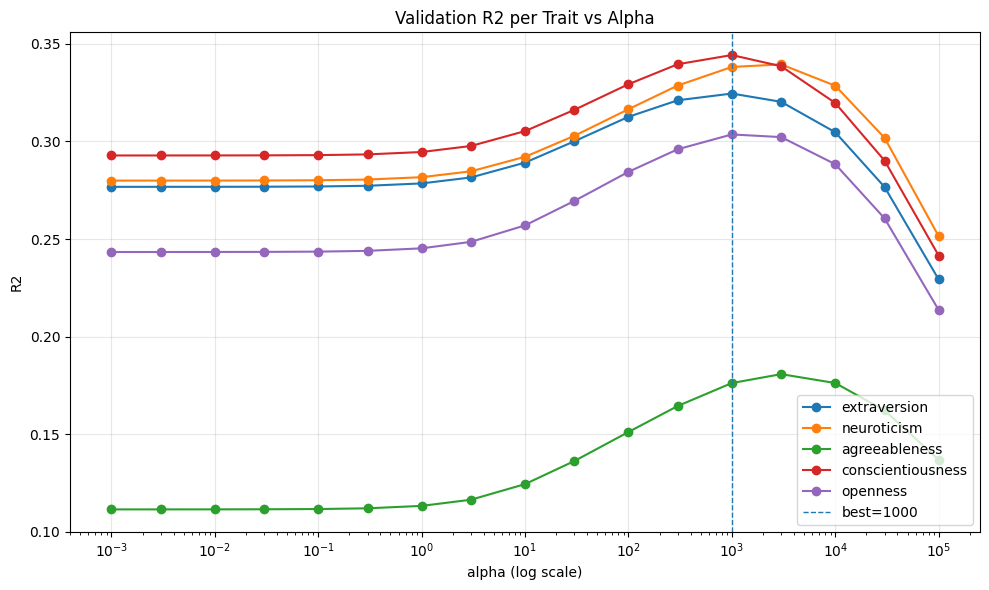

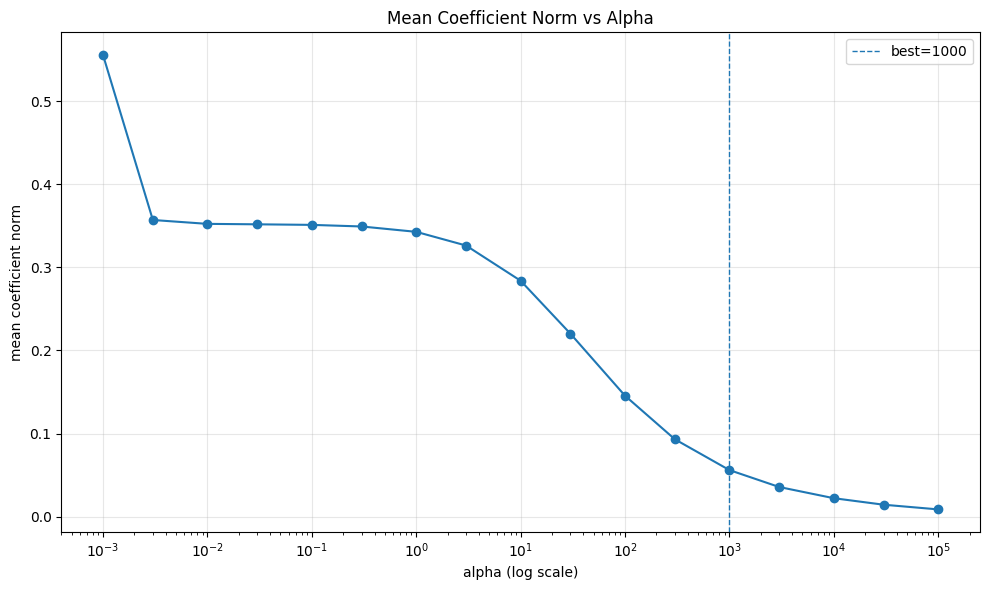

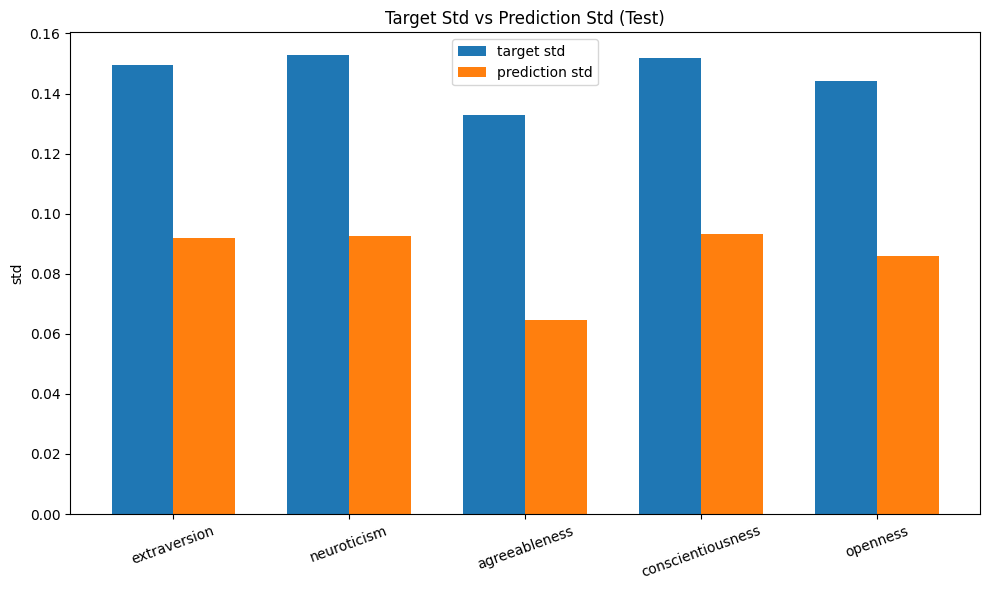

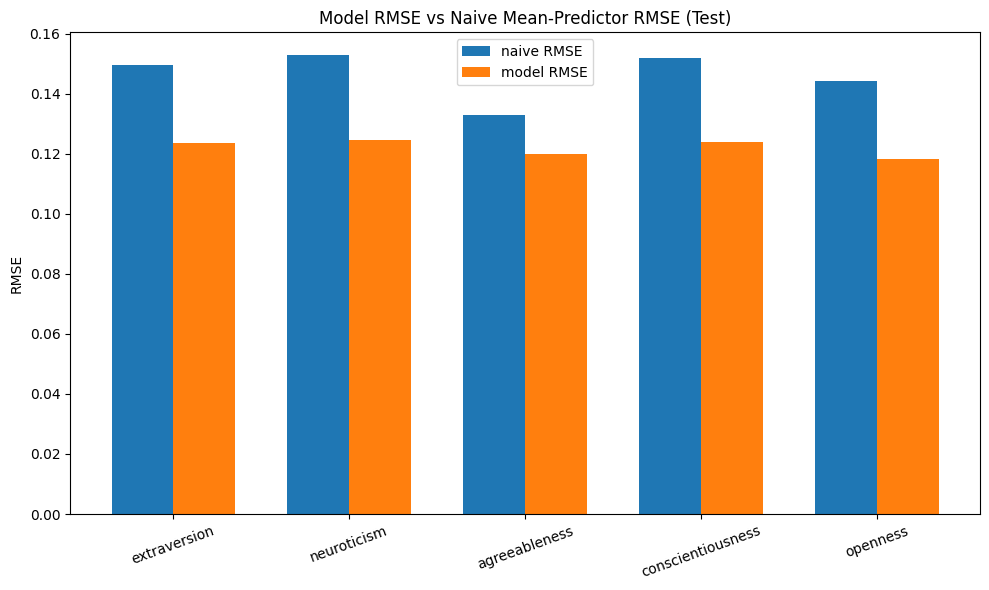

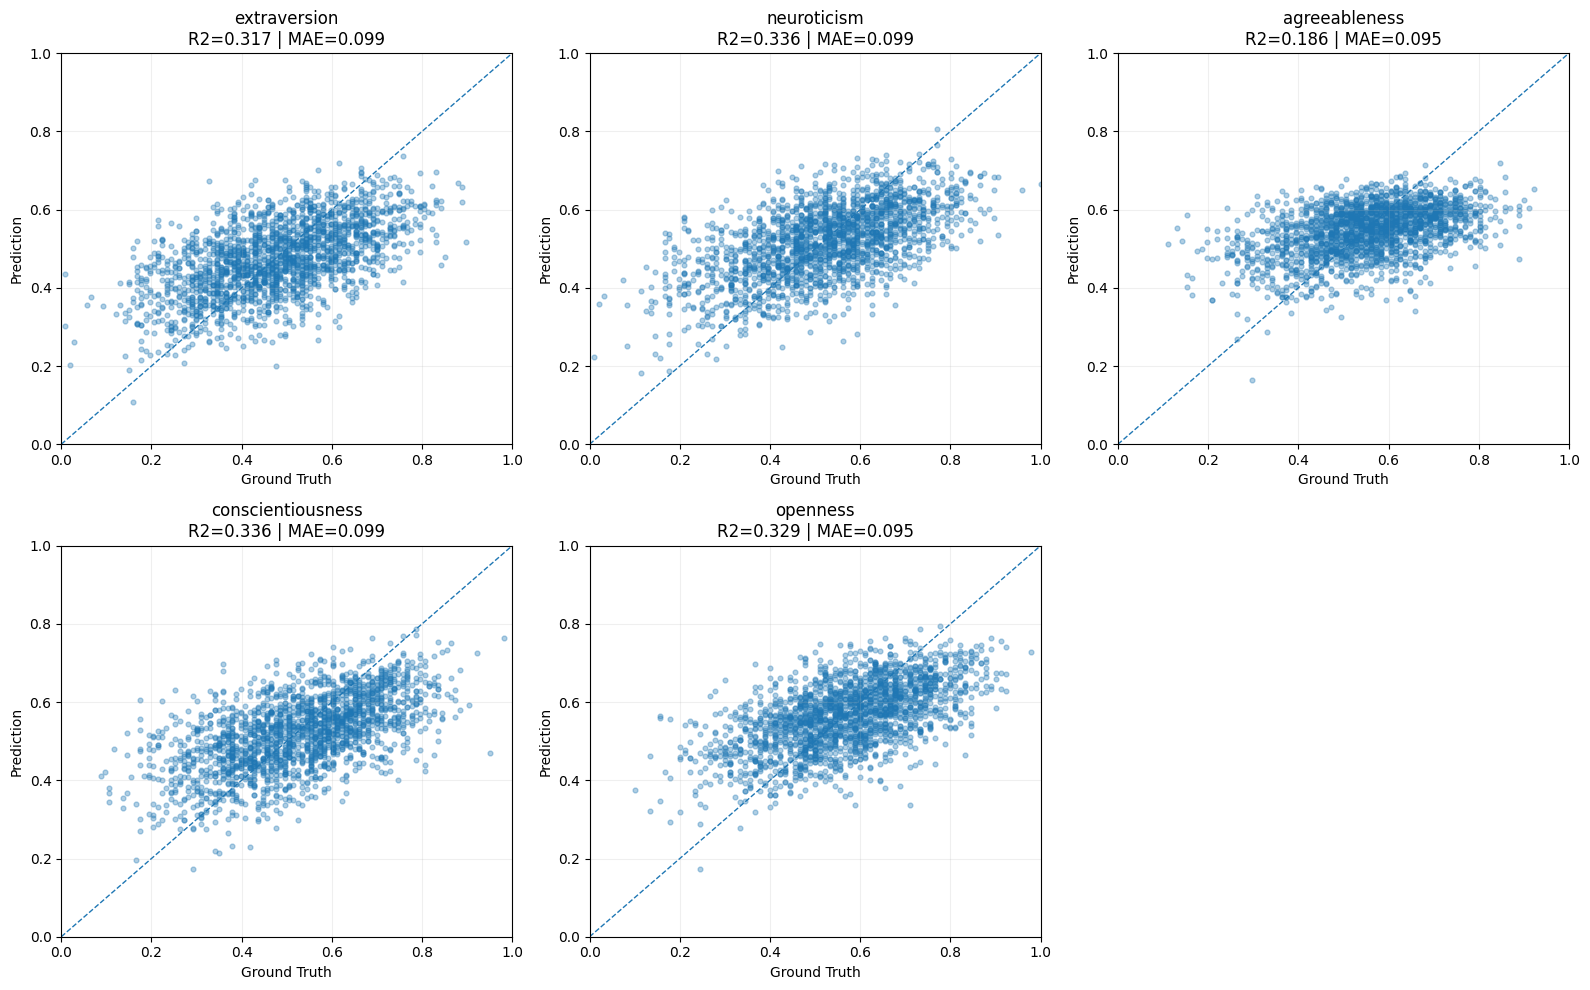

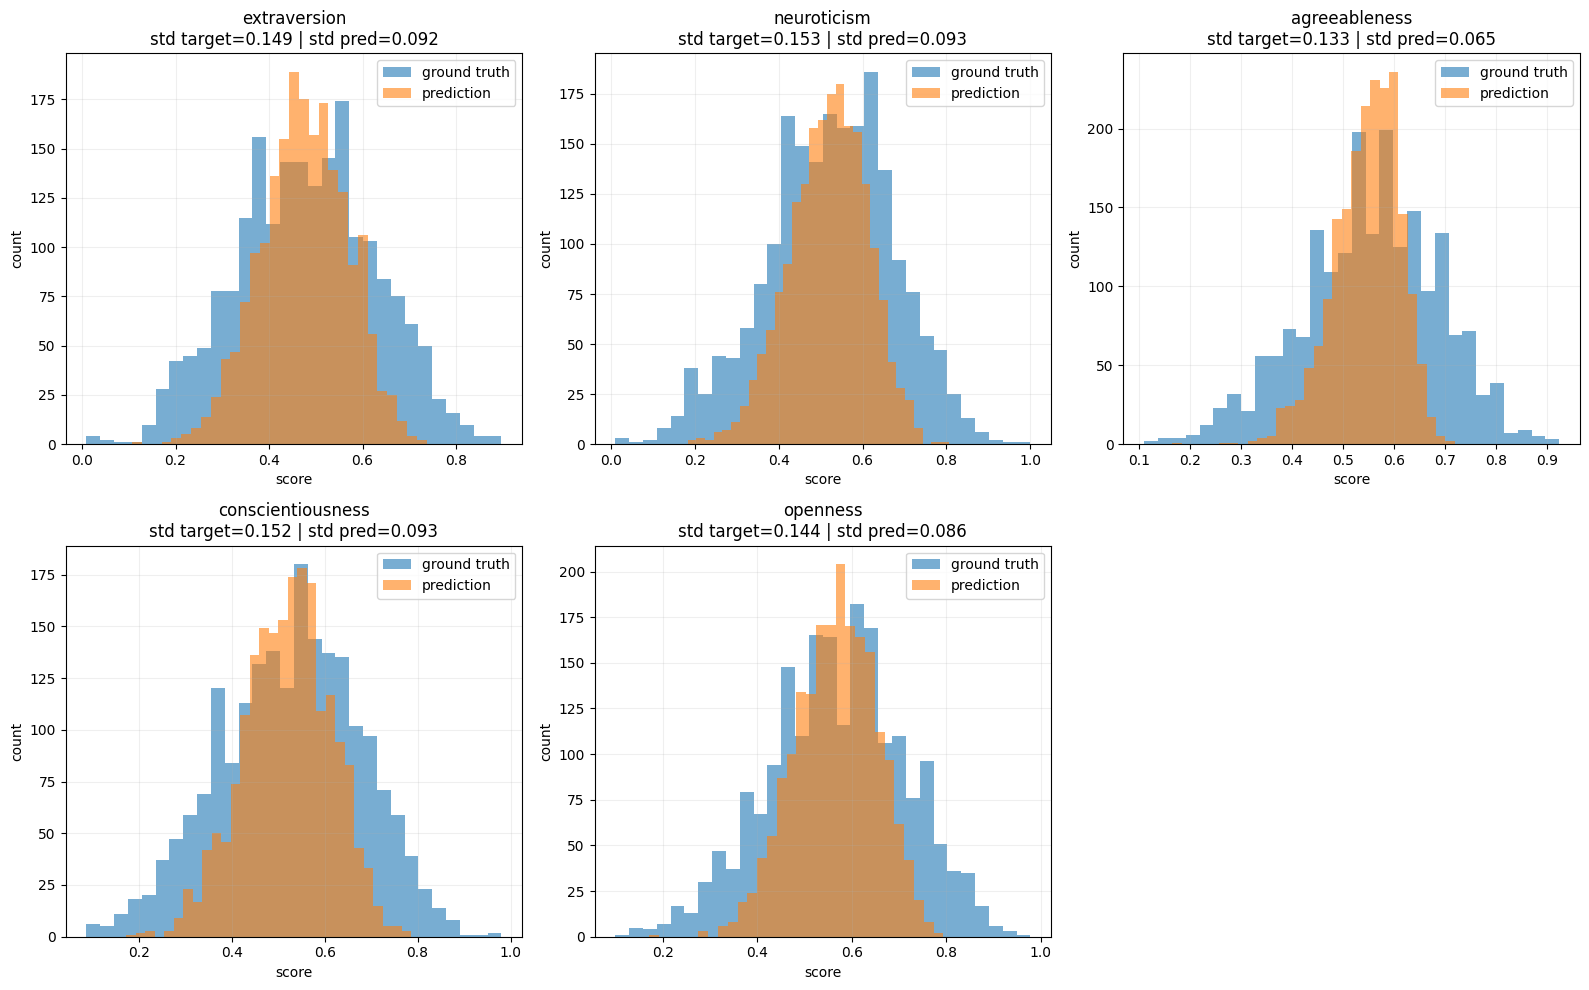


Backbone: hubert
Split tag folder: baseline_official
Best alpha by validation mean MAE: 1000.0
Best validation mean MAE: 0.095947
Best validation mean Acc(1-MAE): 0.904053
Best validation mean RMSE: 0.120795
Best validation mean R2: 0.297344
Interpretation: best alpha tidak berada di ujung kanan grid. Artinya sudah mulai terlihat titik optimal / titik balik, sehingga alpha yang terlalu besar tidak selalu memperbaiki performa.

Kenapa R2 bisa kecil walau Acc(1-MAE) tinggi?
1) Acc(1-MAE) adalah transformasi langsung dari MAE pada target [0,1], jadi MAE 0.09 otomatis terlihat seperti 'akurasi' 0.91.
2) R2 mengukur seberapa besar error relatif terhadap variasi target. Kalau sebaran target sempit / variance kecil, error kecil pun bisa tetap menghasilkan R2 yang tidak tinggi.
3) Ridge dengan alpha besar cenderung melakukan shrinkage, sehingga prediksi mendekati rata-rata dan varians prediksi mengecil. Ini bagus untuk stabilitas MAE, tetapi bisa menahan R2.
4) Jika std prediksi jauh lebih ke

In [6]:
# =========================
# 3) Train Ridge Regressor + Alpha Sweep + Diagnostics
# =========================

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# CONFIG
# =========================

# pilih backbone yang embedding-nya kamu reuse
BACKBONE_KEY = "hubert"   # "wav2vec2" / "wavlm"

# NOTE:
# Aku pertahankan struktur folder mengikuti cell kamu yang sekarang.
# Kalau foldermu sebenarnya versi strict, ganti "baseline_official" -> "baseline_strict"
SPLIT_TAG = "baseline_official"

# alpha grid diperluas untuk membuktikan:
# apakah makin besar alpha terus membaik, atau ada titik balik
ALPHAS = np.array([
    1e-3, 3e-3,
    1e-2, 3e-2,
    1e-1, 3e-1,
    1, 3,
    10, 30,
    100, 300,
    1_000, 3_000,
    10_000, 30_000,
    100_000
], dtype=float)

assert "ROOT" in globals()
assert "df_train" in globals() and "df_val" in globals() and "df_test" in globals()

EMB_DIR = ROOT / "output" / "V2" / SPLIT_TAG / "embeddings" / BACKBONE_KEY
OUT_DIR = ROOT / "output" / "V2" / SPLIT_TAG / "results" / BACKBONE_KEY
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

assert EMB_DIR.exists(), f"EMB_DIR tidak ada: {EMB_DIR}"

# =========================
# LOAD DATA
# =========================

def load_split(split: str):
    X = np.load(EMB_DIR / f"{split}_emb.npy")
    ids = pd.read_csv(EMB_DIR / f"{split}_clip_id.csv")["clip_id"].astype(str).tolist()
    return X, ids

def align_X_to_df(X, ids, df, name=""):
    id2i = {cid: i for i, cid in enumerate(ids)}
    target_ids = df["clip_id"].astype(str).tolist()

    order = []
    missing = []
    for cid in target_ids:
        i = id2i.get(cid)
        if i is None:
            missing.append(cid)
            order.append(-1)
        else:
            order.append(i)

    if missing:
        print(f"[WARN] {name}: missing embeddings = {len(missing)} / {len(target_ids)} | contoh 5: {missing[:5]}")
        raise ValueError(f"Missing embeddings for {name}: {len(missing)}")

    X_aligned = X[np.array(order)]
    return X_aligned, target_ids

# load + align
X_train_raw, train_ids_raw = load_split("train")
X_val_raw,   val_ids_raw   = load_split("val")
X_test_raw,  test_ids_raw  = load_split("test")

X_train, train_ids = align_X_to_df(X_train_raw, train_ids_raw, df_train, "train")
X_val,   val_ids   = align_X_to_df(X_val_raw,   val_ids_raw,   df_val,   "val")
X_test,  test_ids  = align_X_to_df(X_test_raw,  test_ids_raw,  df_test,  "test")

print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)

# =========================
# LABEL DETECTION
# =========================

def detect_label_cols(df):
    exclude = set([
        c for c in df.columns
        if any(k in c.lower() for k in [
            "clip", "id", "path", "file", "group", "split",
            "ethnicity", "gender", "avg_trait"
        ])
    ])
    num_cols = [c for c in df.columns if (c not in exclude) and pd.api.types.is_numeric_dtype(df[c])]
    if len(num_cols) < 5:
        raise ValueError(f"Kolom numerik kandidat label kurang dari 5: {num_cols}")
    return num_cols[:5]

label_cols = detect_label_cols(df_train)
print("Label cols:", label_cols)

y_train = df_train[label_cols].to_numpy(dtype=np.float32)
y_val   = df_val[label_cols].to_numpy(dtype=np.float32)
y_test  = df_test[label_cols].to_numpy(dtype=np.float32)

# =========================
# SCALE EMBEDDINGS
# =========================

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# =========================
# METRIC HELPERS
# =========================

def make_metrics_df(y_true, y_pred, split_name=""):
    mae  = mean_absolute_error(y_true, y_pred, multioutput="raw_values")
    rmse = np.sqrt(mean_squared_error(y_true, y_pred, multioutput="raw_values"))
    r2   = r2_score(y_true, y_pred, multioutput="raw_values")
    acc  = 1.0 - mae

    dfm = pd.DataFrame({
        "split": split_name,
        "trait": label_cols,
        "Acc(1-MAE)": acc,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    })

    mean_row = pd.DataFrame([{
        "split": split_name,
        "trait": "mean",
        "Acc(1-MAE)": acc.mean(),
        "MAE": mae.mean(),
        "RMSE": rmse.mean(),
        "R2": r2.mean(),
    }])

    return pd.concat([dfm, mean_row], ignore_index=True)

def show_metrics(dfm, title):
    print(f"\n== {title} ==")
    try:
        display(dfm)
    except Exception:
        print(dfm)

def extract_mean_row(dfm):
    row = dfm[dfm["trait"] == "mean"].iloc[0]
    return {
        "Acc(1-MAE)": float(row["Acc(1-MAE)"]),
        "MAE": float(row["MAE"]),
        "RMSE": float(row["RMSE"]),
        "R2": float(row["R2"]),
    }

# =========================
# ALPHA SWEEP (VALIDATION ONLY FOR MODEL SELECTION)
# =========================

alpha_rows = []
alpha_trait_rows = []

best_alpha = None
best_val_mae = np.inf
best_model = None

for a in ALPHAS:
    ridge = Ridge(alpha=float(a), random_state=42)
    model = MultiOutputRegressor(ridge)
    model.fit(X_train_s, y_train)

    pred_val = model.predict(X_val_s)
    df_val_metrics = make_metrics_df(y_val, pred_val, split_name="val")
    mean_metrics = extract_mean_row(df_val_metrics)

    # mean coefficient norm, buat lihat efek shrinkage saat alpha membesar
    coef_norms = [np.linalg.norm(est.coef_) for est in model.estimators_]
    intercept_norms = [np.linalg.norm(np.atleast_1d(est.intercept_)) for est in model.estimators_]

    alpha_rows.append({
        "alpha": float(a),
        "val_Acc(1-MAE)": mean_metrics["Acc(1-MAE)"],
        "val_MAE": mean_metrics["MAE"],
        "val_RMSE": mean_metrics["RMSE"],
        "val_R2": mean_metrics["R2"],
        "mean_coef_norm": float(np.mean(coef_norms)),
        "mean_intercept_norm": float(np.mean(intercept_norms)),
    })

    tmp_trait = df_val_metrics[df_val_metrics["trait"] != "mean"].copy()
    tmp_trait["alpha"] = float(a)
    alpha_trait_rows.append(tmp_trait)

    print(
        f"alpha={a:>9.4g} | "
        f"val MAE={mean_metrics['MAE']:.6f} | "
        f"val Acc={mean_metrics['Acc(1-MAE)']:.6f} | "
        f"val RMSE={mean_metrics['RMSE']:.6f} | "
        f"val R2={mean_metrics['R2']:.6f}"
    )

    if mean_metrics["MAE"] < best_val_mae:
        best_val_mae = mean_metrics["MAE"]
        best_alpha = float(a)
        best_model = model

alpha_sweep_df = pd.DataFrame(alpha_rows).sort_values("alpha").reset_index(drop=True)
alpha_trait_df = pd.concat(alpha_trait_rows, ignore_index=True)

print(f"\nBest alpha = {best_alpha} | best val mean MAE = {best_val_mae:.6f}")

# simpan summary alpha sweep
alpha_sweep_df.to_csv(OUT_DIR / "alpha_sweep_summary.csv", index=False)
alpha_trait_df.to_csv(OUT_DIR / "alpha_sweep_per_trait.csv", index=False)

# =========================
# FINAL EVAL WITH BEST ALPHA
# =========================

model = best_model
pred_val  = model.predict(X_val_s)
pred_test = model.predict(X_test_s)

m_val  = make_metrics_df(y_val, pred_val, split_name="val")
m_test = make_metrics_df(y_test, pred_test, split_name="test")

show_metrics(m_val,  f"{BACKBONE_KEY} | {SPLIT_TAG.upper()} | VAL")
show_metrics(m_test, f"{BACKBONE_KEY} | {SPLIT_TAG.upper()} | TEST")

# =========================
# SAVE PREDICTIONS
# =========================

pred_val_df = pd.DataFrame({
    "clip_id": val_ids,
    **{f"gt_{c}": y_val[:, i] for i, c in enumerate(label_cols)},
    **{f"pred_{c}": pred_val[:, i] for i, c in enumerate(label_cols)},
})
pred_test_df = pd.DataFrame({
    "clip_id": test_ids,
    **{f"gt_{c}": y_test[:, i] for i, c in enumerate(label_cols)},
    **{f"pred_{c}": pred_test[:, i] for i, c in enumerate(label_cols)},
})

pred_val_df.to_csv(OUT_DIR / "pred_val_full.csv", index=False)
pred_test_df.to_csv(OUT_DIR / "pred_test_full.csv", index=False)

# metrik final
m_val.to_csv(OUT_DIR / "metrics_val.csv", index=False)
m_test.to_csv(OUT_DIR / "metrics_test.csv", index=False)

# model + scaler
joblib.dump(scaler, OUT_DIR / "scaler.joblib")
joblib.dump(model,  OUT_DIR / "ridge_multioutput.joblib")

# =========================
# DIAGNOSIS: KENAPA R2 KECIL?
# =========================

# baseline naif: prediksi selalu mean train
train_mean = y_train.mean(axis=0)
naive_pred_test = np.tile(train_mean, (len(y_test), 1))

test_mae  = mean_absolute_error(y_test, pred_test, multioutput="raw_values")
test_rmse = np.sqrt(mean_squared_error(y_test, pred_test, multioutput="raw_values"))
test_r2   = r2_score(y_test, pred_test, multioutput="raw_values")

naive_mae  = mean_absolute_error(y_test, naive_pred_test, multioutput="raw_values")
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred_test, multioutput="raw_values"))
naive_r2   = r2_score(y_test, naive_pred_test, multioutput="raw_values")

target_mean = y_test.mean(axis=0)
target_std  = y_test.std(axis=0, ddof=0)
target_var  = y_test.var(axis=0, ddof=0)

pred_mean = pred_test.mean(axis=0)
pred_std  = pred_test.std(axis=0, ddof=0)

diag_rows = []
for i, trait in enumerate(label_cols):
    diag_rows.append({
        "trait": trait,
        "target_mean": float(target_mean[i]),
        "target_std": float(target_std[i]),
        "target_var": float(target_var[i]),
        "pred_mean": float(pred_mean[i]),
        "pred_std": float(pred_std[i]),
        "pred_std_over_target_std": float(pred_std[i] / target_std[i]) if target_std[i] > 0 else np.nan,
        "MAE_model": float(test_mae[i]),
        "RMSE_model": float(test_rmse[i]),
        "R2_model": float(test_r2[i]),
        "MAE_naive_train_mean": float(naive_mae[i]),
        "RMSE_naive_train_mean": float(naive_rmse[i]),
        "R2_naive_train_mean": float(naive_r2[i]),
        "RMSE_improvement_vs_naive": float(naive_rmse[i] - test_rmse[i]),
        "RMSE_over_target_std": float(test_rmse[i] / target_std[i]) if target_std[i] > 0 else np.nan,
    })

diag_df = pd.DataFrame(diag_rows)
diag_df.to_csv(OUT_DIR / "r2_diagnosis_test.csv", index=False)

try:
    display(diag_df)
except Exception:
    print(diag_df)

# =========================
# PLOTS
# =========================

# 1) mean metric sweep
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metric_map = [
    ("val_MAE", "Validation Mean MAE"),
    ("val_Acc(1-MAE)", "Validation Mean Acc(1-MAE)"),
    ("val_RMSE", "Validation Mean RMSE"),
    ("val_R2", "Validation Mean R2"),
]

for ax, (col, title) in zip(axes.flatten(), metric_map):
    ax.plot(alpha_sweep_df["alpha"], alpha_sweep_df[col], marker="o")
    ax.axvline(best_alpha, linestyle="--", linewidth=1, label=f"best={best_alpha:g}")
    ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel("alpha (log scale)")
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "alpha_sweep_mean_metrics.png", dpi=200, bbox_inches="tight")
plt.show()

# 2) per-trait MAE vs alpha
plt.figure(figsize=(10, 6))
for trait in label_cols:
    d = alpha_trait_df[alpha_trait_df["trait"] == trait].sort_values("alpha")
    plt.plot(d["alpha"], d["MAE"], marker="o", label=trait)
plt.axvline(best_alpha, linestyle="--", linewidth=1, label=f"best={best_alpha:g}")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("MAE")
plt.title("Validation MAE per Trait vs Alpha")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "alpha_sweep_per_trait_mae.png", dpi=200, bbox_inches="tight")
plt.show()

# 3) per-trait R2 vs alpha
plt.figure(figsize=(10, 6))
for trait in label_cols:
    d = alpha_trait_df[alpha_trait_df["trait"] == trait].sort_values("alpha")
    plt.plot(d["alpha"], d["R2"], marker="o", label=trait)
plt.axvline(best_alpha, linestyle="--", linewidth=1, label=f"best={best_alpha:g}")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("R2")
plt.title("Validation R2 per Trait vs Alpha")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "alpha_sweep_per_trait_r2.png", dpi=200, bbox_inches="tight")
plt.show()

# 4) coefficient norm vs alpha (melihat shrinkage ridge)
plt.figure(figsize=(10, 6))
plt.plot(alpha_sweep_df["alpha"], alpha_sweep_df["mean_coef_norm"], marker="o")
plt.axvline(best_alpha, linestyle="--", linewidth=1, label=f"best={best_alpha:g}")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("mean coefficient norm")
plt.title("Mean Coefficient Norm vs Alpha")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "alpha_sweep_coef_norm.png", dpi=200, bbox_inches="tight")
plt.show()

# 5) target std vs prediction std (diagnosis regression-to-the-mean)
x = np.arange(len(label_cols))
w = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - w/2, diag_df["target_std"], width=w, label="target std")
plt.bar(x + w/2, diag_df["pred_std"], width=w, label="prediction std")
plt.xticks(x, label_cols, rotation=20)
plt.ylabel("std")
plt.title("Target Std vs Prediction Std (Test)")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "diagnosis_target_std_vs_pred_std.png", dpi=200, bbox_inches="tight")
plt.show()

# 6) RMSE model vs RMSE naive
plt.figure(figsize=(10, 6))
plt.bar(x - w/2, diag_df["RMSE_naive_train_mean"], width=w, label="naive RMSE")
plt.bar(x + w/2, diag_df["RMSE_model"], width=w, label="model RMSE")
plt.xticks(x, label_cols, rotation=20)
plt.ylabel("RMSE")
plt.title("Model RMSE vs Naive Mean-Predictor RMSE (Test)")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "diagnosis_rmse_model_vs_naive.png", dpi=200, bbox_inches="tight")
plt.show()

# 7) scatter pred vs gt per trait
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, trait in enumerate(label_cols):
    ax = axes[i]
    ax.scatter(y_test[:, i], pred_test[:, i], s=12, alpha=0.35)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_title(f"{trait}\nR2={test_r2[i]:.3f} | MAE={test_mae[i]:.3f}")
    ax.set_xlabel("Ground Truth")
    ax.set_ylabel("Prediction")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.2)

# hapus subplot kosong kalau ada
for j in range(len(label_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(FIG_DIR / "scatter_pred_vs_gt_test.png", dpi=200, bbox_inches="tight")
plt.show()

# 8) histogram distribusi prediksi vs target
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, trait in enumerate(label_cols):
    ax = axes[i]
    ax.hist(y_test[:, i], bins=30, alpha=0.6, label="ground truth")
    ax.hist(pred_test[:, i], bins=30, alpha=0.6, label="prediction")
    ax.set_title(
        f"{trait}\nstd target={target_std[i]:.3f} | std pred={pred_std[i]:.3f}"
    )
    ax.set_xlabel("score")
    ax.set_ylabel("count")
    ax.grid(True, alpha=0.2)
    ax.legend()

for j in range(len(label_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(FIG_DIR / "hist_target_vs_prediction_test.png", dpi=200, bbox_inches="tight")
plt.show()

# =========================
# AUTO SUMMARY
# =========================

best_idx = alpha_sweep_df["val_MAE"].idxmin()
best_alpha_from_df = alpha_sweep_df.loc[best_idx, "alpha"]
is_best_at_right_edge = np.isclose(best_alpha_from_df, alpha_sweep_df["alpha"].max())

summary_lines = []
summary_lines.append(f"Backbone: {BACKBONE_KEY}")
summary_lines.append(f"Split tag folder: {SPLIT_TAG}")
summary_lines.append(f"Best alpha by validation mean MAE: {best_alpha}")
summary_lines.append(f"Best validation mean MAE: {best_val_mae:.6f}")
summary_lines.append(f"Best validation mean Acc(1-MAE): {alpha_sweep_df.loc[best_idx, 'val_Acc(1-MAE)']:.6f}")
summary_lines.append(f"Best validation mean RMSE: {alpha_sweep_df.loc[best_idx, 'val_RMSE']:.6f}")
summary_lines.append(f"Best validation mean R2: {alpha_sweep_df.loc[best_idx, 'val_R2']:.6f}")

if is_best_at_right_edge:
    summary_lines.append(
        "Interpretation: best alpha masih berada di ujung kanan grid. "
        "Ini berarti belum ada bukti kuat bahwa performa sudah mencapai titik balik. "
        "Kalau dosen ingin pembuktian lebih jauh, alpha bisa diperbesar lagi."
    )
else:
    summary_lines.append(
        "Interpretation: best alpha tidak berada di ujung kanan grid. "
        "Artinya sudah mulai terlihat titik optimal / titik balik, sehingga alpha yang terlalu besar "
        "tidak selalu memperbaiki performa."
    )

summary_lines.append("")
summary_lines.append("Kenapa R2 bisa kecil walau Acc(1-MAE) tinggi?")
summary_lines.append(
    "1) Acc(1-MAE) adalah transformasi langsung dari MAE pada target [0,1], "
    "jadi MAE 0.09 otomatis terlihat seperti 'akurasi' 0.91."
)
summary_lines.append(
    "2) R2 mengukur seberapa besar error relatif terhadap variasi target. "
    "Kalau sebaran target sempit / variance kecil, error kecil pun bisa tetap menghasilkan R2 yang tidak tinggi."
)
summary_lines.append(
    "3) Ridge dengan alpha besar cenderung melakukan shrinkage, sehingga prediksi mendekati rata-rata "
    "dan varians prediksi mengecil. Ini bagus untuk stabilitas MAE, tetapi bisa menahan R2."
)
summary_lines.append(
    "4) Jika std prediksi jauh lebih kecil daripada std target, itu tanda regresi menuju mean "
    "(under-dispersed prediction), yang sering membuat R2 rendah."
)

summary_text = "\n".join(summary_lines)
print("\n" + "="*80)
print(summary_text)
print("="*80)

(OUT_DIR / "ridge_analysis_summary.txt").write_text(summary_text, encoding="utf-8")

# =========================
# SAVE META
# =========================

meta = {
    "backbone": BACKBONE_KEY,
    "split_tag": SPLIT_TAG,
    "best_alpha": float(best_alpha),
    "alpha_grid": [float(a) for a in ALPHAS],
    "label_cols": label_cols,
    "shapes": {
        "train": list(X_train.shape),
        "val": list(X_val.shape),
        "test": list(X_test.shape),
    },
    "saved_files": [
        "alpha_sweep_summary.csv",
        "alpha_sweep_per_trait.csv",
        "metrics_val.csv",
        "metrics_test.csv",
        "pred_val_full.csv",
        "pred_test_full.csv",
        "r2_diagnosis_test.csv",
        "ridge_analysis_summary.txt",
        "scaler.joblib",
        "ridge_multioutput.joblib",
    ],
    "saved_figures": [
        "alpha_sweep_mean_metrics.png",
        "alpha_sweep_per_trait_mae.png",
        "alpha_sweep_per_trait_r2.png",
        "alpha_sweep_coef_norm.png",
        "diagnosis_target_std_vs_pred_std.png",
        "diagnosis_rmse_model_vs_naive.png",
        "scatter_pred_vs_gt_test.png",
        "hist_target_vs_prediction_test.png",
    ],
}
(OUT_DIR / "meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")

print(f"\nSaved all outputs to: {OUT_DIR}")
print(f"Saved figures to    : {FIG_DIR}")

# **REUSE EMBEDDING V1 - WAV2VEC2**

In [8]:
# =========================
# 2) Reuse embedding dari baseline_official -> align ke STRICT split (by clip_id)
# =========================

import numpy as np
import pandas as pd
from pathlib import Path

assert "ROOT" in globals()
assert "df_train" in globals() and "df_val" in globals() and "df_test" in globals()

BACKBONE_KEY = "wav2vec2"   # ganti: "wav2vec2" / "wavlm"

# lokasi embedding yang sudah ada (official)
EMB_DIR_OFF = ROOT / "output" / "V1" / "baseline_official" / "embeddings" / BACKBONE_KEY
assert EMB_DIR_OFF.exists(), f"Folder embedding official tidak ada: {EMB_DIR_OFF}"

def load_official_split(split: str):
    X = np.load(EMB_DIR_OFF / f"{split}_emb.npy", mmap_mode="r")
    ids = pd.read_csv(EMB_DIR_OFF / f"{split}_clip_id.csv")["clip_id"].astype(str).tolist()
    return X, ids

# load pool embedding dari official train/val/test
X_off = {}
ids_off = {}

for split in ["train", "val", "test"]:
    X_off[split], ids_off[split] = load_official_split(split)
    print(f"[OFFICIAL] {split}: X={X_off[split].shape} ids={len(ids_off[split])}")

# build mapping clip_id -> (split, idx)
id2loc = {}
dup = 0
for split in ["train", "val", "test"]:
    for i, cid in enumerate(ids_off[split]):
        if cid in id2loc:
            dup += 1
        id2loc[cid] = (split, i)

if dup > 0:
    print(f"[WARN] Duplicated clip_id across official splits: {dup} (harusnya 0).")

H = int(X_off["train"].shape[1])
print("Hidden size (H):", H)

def build_X_from_strict(df_split: pd.DataFrame, name: str):
    ids = df_split["clip_id"].astype(str).tolist()
    X = np.zeros((len(ids), H), dtype=np.float32)

    missing = []
    for j, cid in enumerate(ids):
        loc = id2loc.get(cid)
        if loc is None:
            missing.append(cid)
            continue
        sp, i = loc
        X[j] = X_off[sp][i]  # ambil dari memmap official

    if missing:
        print(f"[WARN] {name}: missing embeddings = {len(missing)} / {len(ids)} (contoh 5): {missing[:5]}")
        # kalau kamu mau strict fail biar ketahuan:
        # raise ValueError(f"Missing embeddings in {name}: {len(missing)}")

    print(f"[STRICT] {name}: X={X.shape} ids={len(ids)}")
    return X, ids

# align ke strict split
X_train, train_ids = build_X_from_strict(df_train, "train")
X_val,   val_ids   = build_X_from_strict(df_val,   "val")
X_test,  test_ids  = build_X_from_strict(df_test,  "test")

# (opsional) cache ulang supaya notebook strict mirip baseline official
OFFICIAL_EMB_DIR = ROOT / "output" / "V2" / "baseline_official" / "embeddings" / BACKBONE_KEY
OFFICIAL_EMB_DIR.mkdir(parents=True, exist_ok=True)

np.save(OFFICIAL_EMB_DIR / "train_emb.npy", X_train)
np.save(OFFICIAL_EMB_DIR / "val_emb.npy",   X_val)
np.save(OFFICIAL_EMB_DIR / "test_emb.npy",  X_test)

pd.DataFrame({"clip_id": train_ids}).to_csv(OFFICIAL_EMB_DIR / "train_clip_id.csv", index=False)
pd.DataFrame({"clip_id": val_ids}).to_csv(OFFICIAL_EMB_DIR / "val_clip_id.csv", index=False)
pd.DataFrame({"clip_id": test_ids}).to_csv(OFFICIAL_EMB_DIR / "test_clip_id.csv", index=False)

print("Saved embeddings to:", OFFICIAL_EMB_DIR)


[OFFICIAL] train: X=(5988, 768) ids=5988
[OFFICIAL] val: X=(1994, 768) ids=1994
[OFFICIAL] test: X=(1992, 768) ids=1992
Hidden size (H): 768
[STRICT] train: X=(5988, 768) ids=5988
[STRICT] val: X=(1994, 768) ids=1994
[STRICT] test: X=(1992, 768) ids=1992
Saved embeddings to: E:\tugas-akhir-qiqi\output\V2\baseline_official\embeddings\wav2vec2


X_train: (5988, 768) | X_val: (1994, 768) | X_test: (1992, 768)
Label cols: ['extraversion', 'neuroticism', 'agreeableness', 'conscientiousness', 'openness']
alpha=    0.001 | val MAE=0.100322 | val Acc=0.899678 | val RMSE=0.126305 | val R2=0.232204
alpha=    0.003 | val MAE=0.100323 | val Acc=0.899677 | val RMSE=0.126305 | val R2=0.232204
alpha=     0.01 | val MAE=0.100319 | val Acc=0.899681 | val RMSE=0.126298 | val R2=0.232285
alpha=     0.03 | val MAE=0.100310 | val Acc=0.899690 | val RMSE=0.126286 | val R2=0.232428
alpha=      0.1 | val MAE=0.100282 | val Acc=0.899718 | val RMSE=0.126246 | val R2=0.232920
alpha=      0.3 | val MAE=0.100202 | val Acc=0.899798 | val RMSE=0.126131 | val R2=0.234317
alpha=        1 | val MAE=0.099958 | val Acc=0.900042 | val RMSE=0.125779 | val R2=0.238584
alpha=        3 | val MAE=0.099479 | val Acc=0.900521 | val RMSE=0.125076 | val R2=0.247081
alpha=       10 | val MAE=0.098698 | val Acc=0.901302 | val RMSE=0.123920 | val R2=0.260928
alpha=       3

,split,trait,Acc(1-MAE),MAE,RMSE,R2
0,val,extraversion,0.900374,0.099626,0.124055,0.295543
1,val,neuroticism,0.901755,0.098245,0.122599,0.326856
2,val,agreeableness,0.907822,0.092178,0.116163,0.166323
3,val,conscientiousness,0.899152,0.100848,0.127339,0.329830
4,val,openness,0.902832,0.097168,0.121957,0.274644
5,val,mean,0.902387,0.097613,0.122423,0.278639



== wav2vec2 | BASELINE_OFFICIAL | TEST ==


,split,trait,Acc(1-MAE),MAE,RMSE,R2
0,test,extraversion,0.899859,0.100141,0.124337,0.308226
1,test,neuroticism,0.900310,0.099690,0.125201,0.328178
2,test,agreeableness,0.903250,0.096750,0.120607,0.175170
3,test,conscientiousness,0.900084,0.099916,0.124596,0.327717
4,test,openness,0.902692,0.097308,0.121734,0.286984
5,test,mean,0.901239,0.098761,0.123295,0.285255


,trait,target_mean,target_std,target_var,pred_mean,pred_std,pred_std_over_target_std,MAE_model,RMSE_model,R2_model,MAE_naive_train_mean,RMSE_naive_train_mean,R2_naive_train_mean,RMSE_improvement_vs_naive,RMSE_over_target_std
0,extraversion,0.478489,0.149493,0.022348,0.476734,0.094583,0.632690,0.100141,0.124337,0.308226,0.121490,0.149510,-0.000230,0.025172,0.831730
1,neuroticism,0.522392,0.152750,0.023333,0.519319,0.094867,0.621062,0.099690,0.125201,0.328178,0.122308,0.152762,-0.000156,0.027561,0.819648
2,agreeableness,0.552341,0.132797,0.017635,0.547827,0.068488,0.515736,0.096750,0.120607,0.175170,0.106054,0.132856,-0.000886,0.012249,0.908202
3,conscientiousness,0.526017,0.151960,0.023092,0.521133,0.096173,0.632882,0.099916,0.124596,0.327717,0.124981,0.151992,-0.000426,0.027396,0.819929
4,openness,0.568753,0.144165,0.020784,0.566618,0.089797,0.622877,0.097308,0.121734,0.286984,0.116458,0.144185,-0.000270,0.022451,0.844403


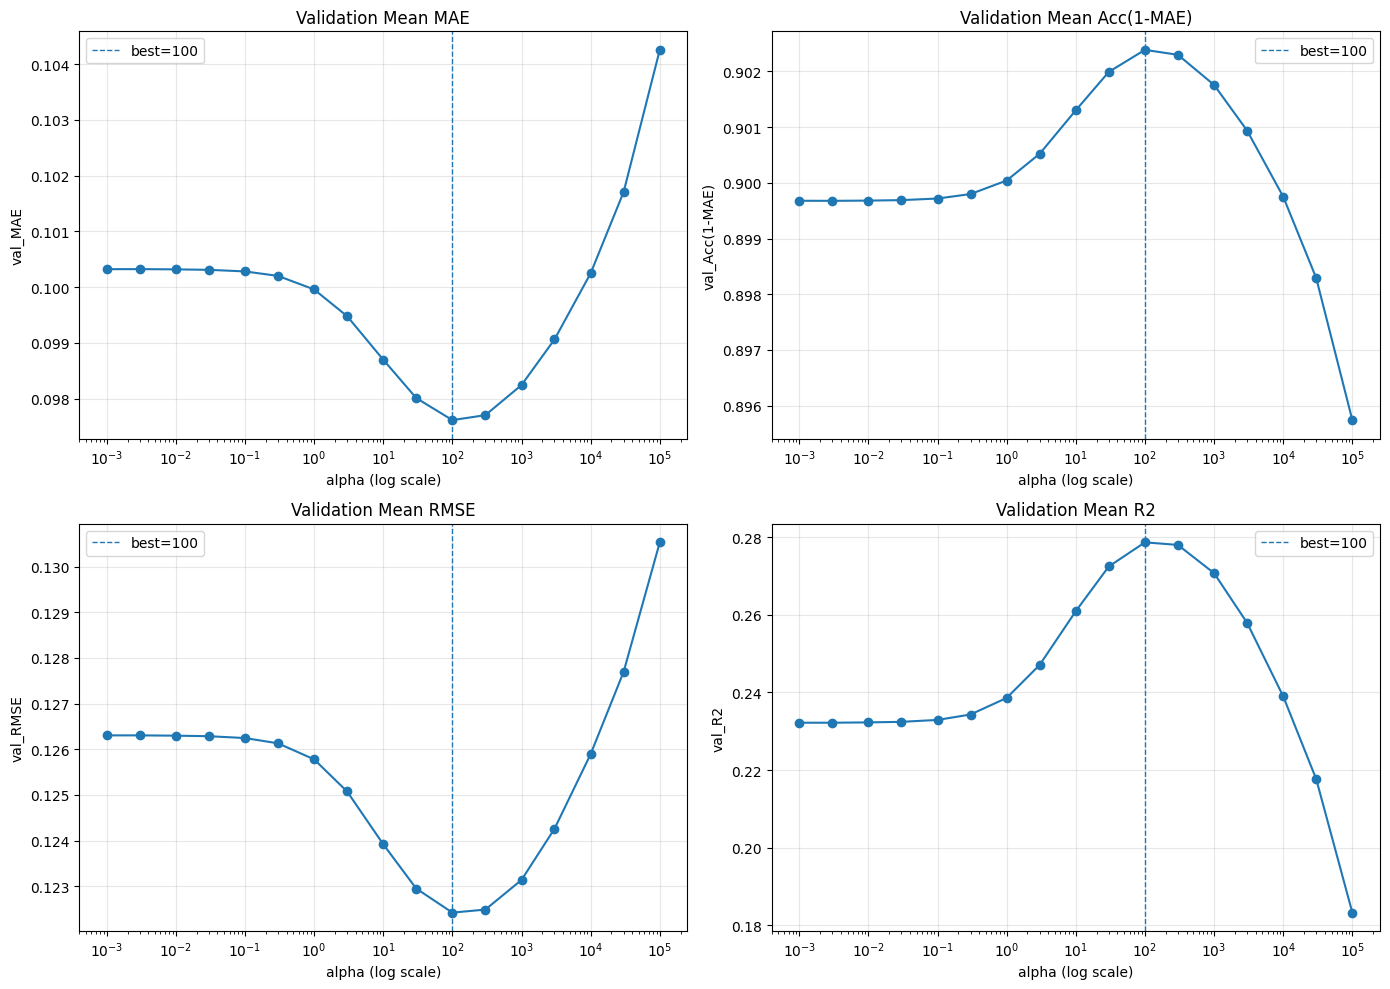

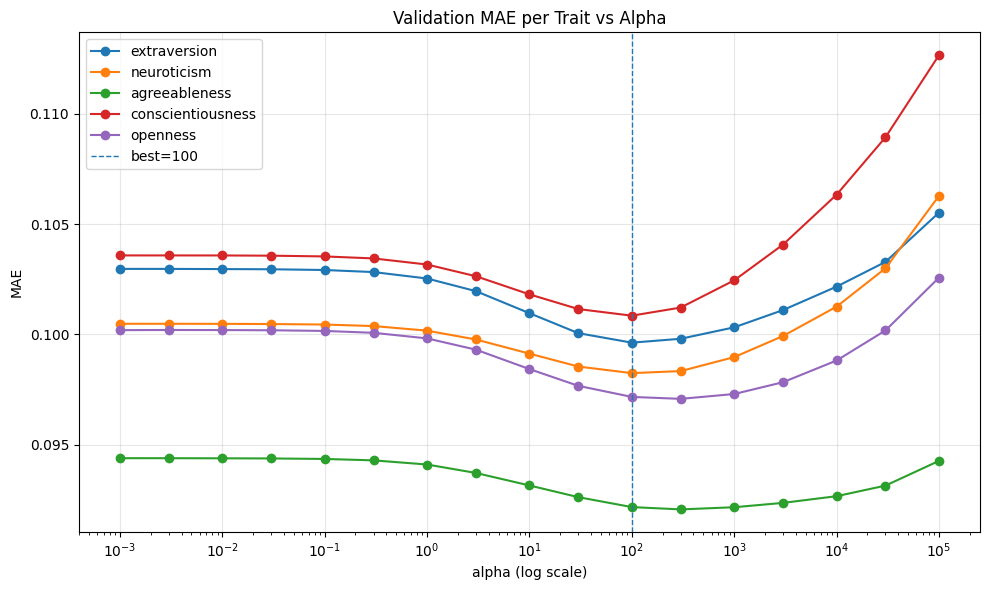

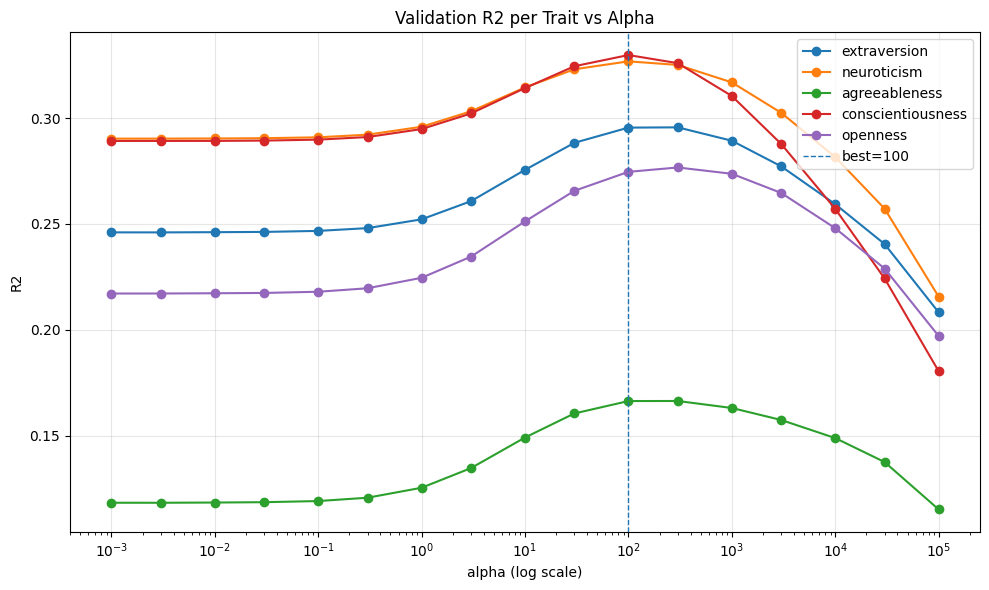

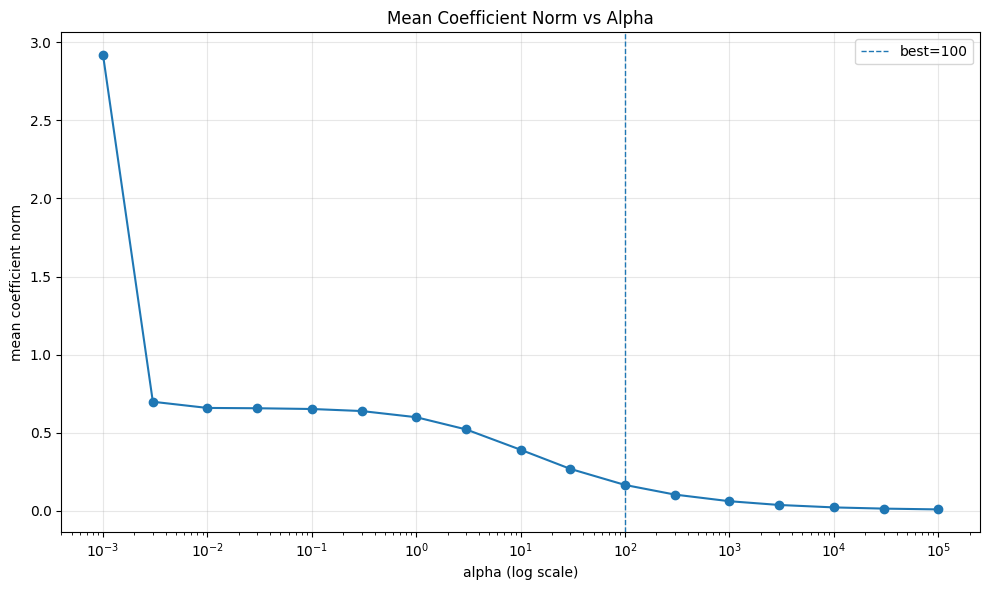

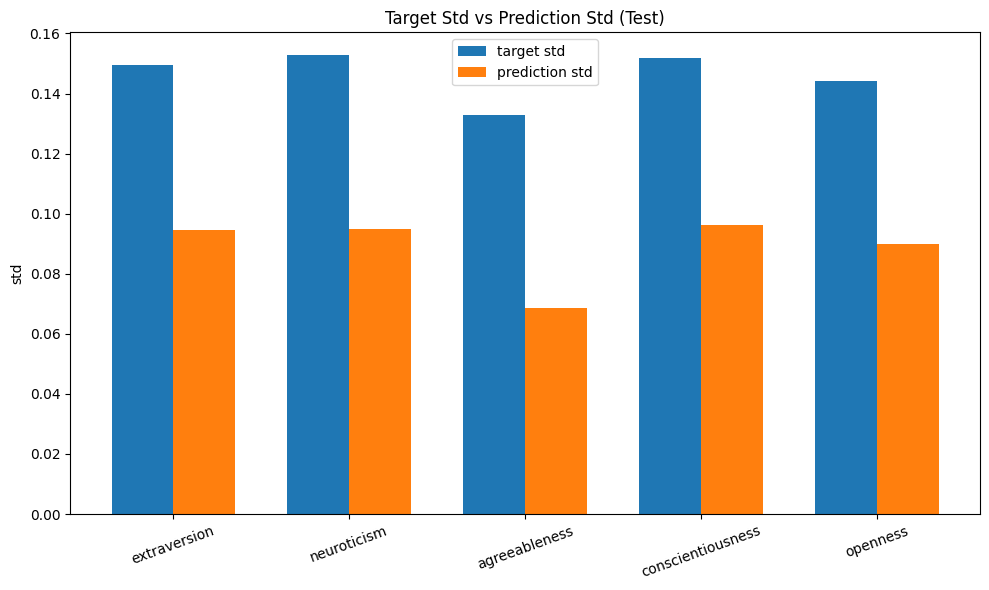

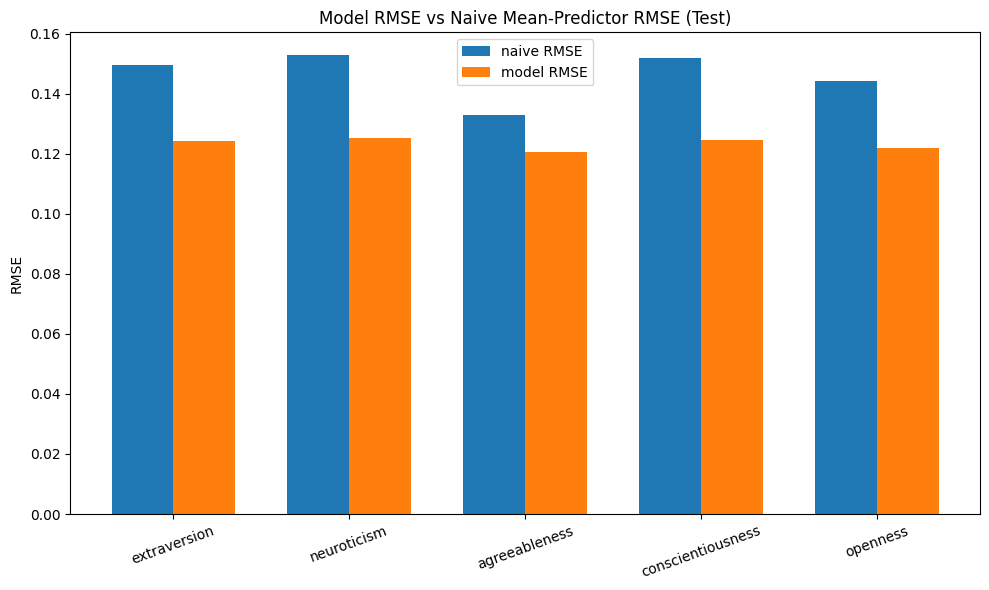

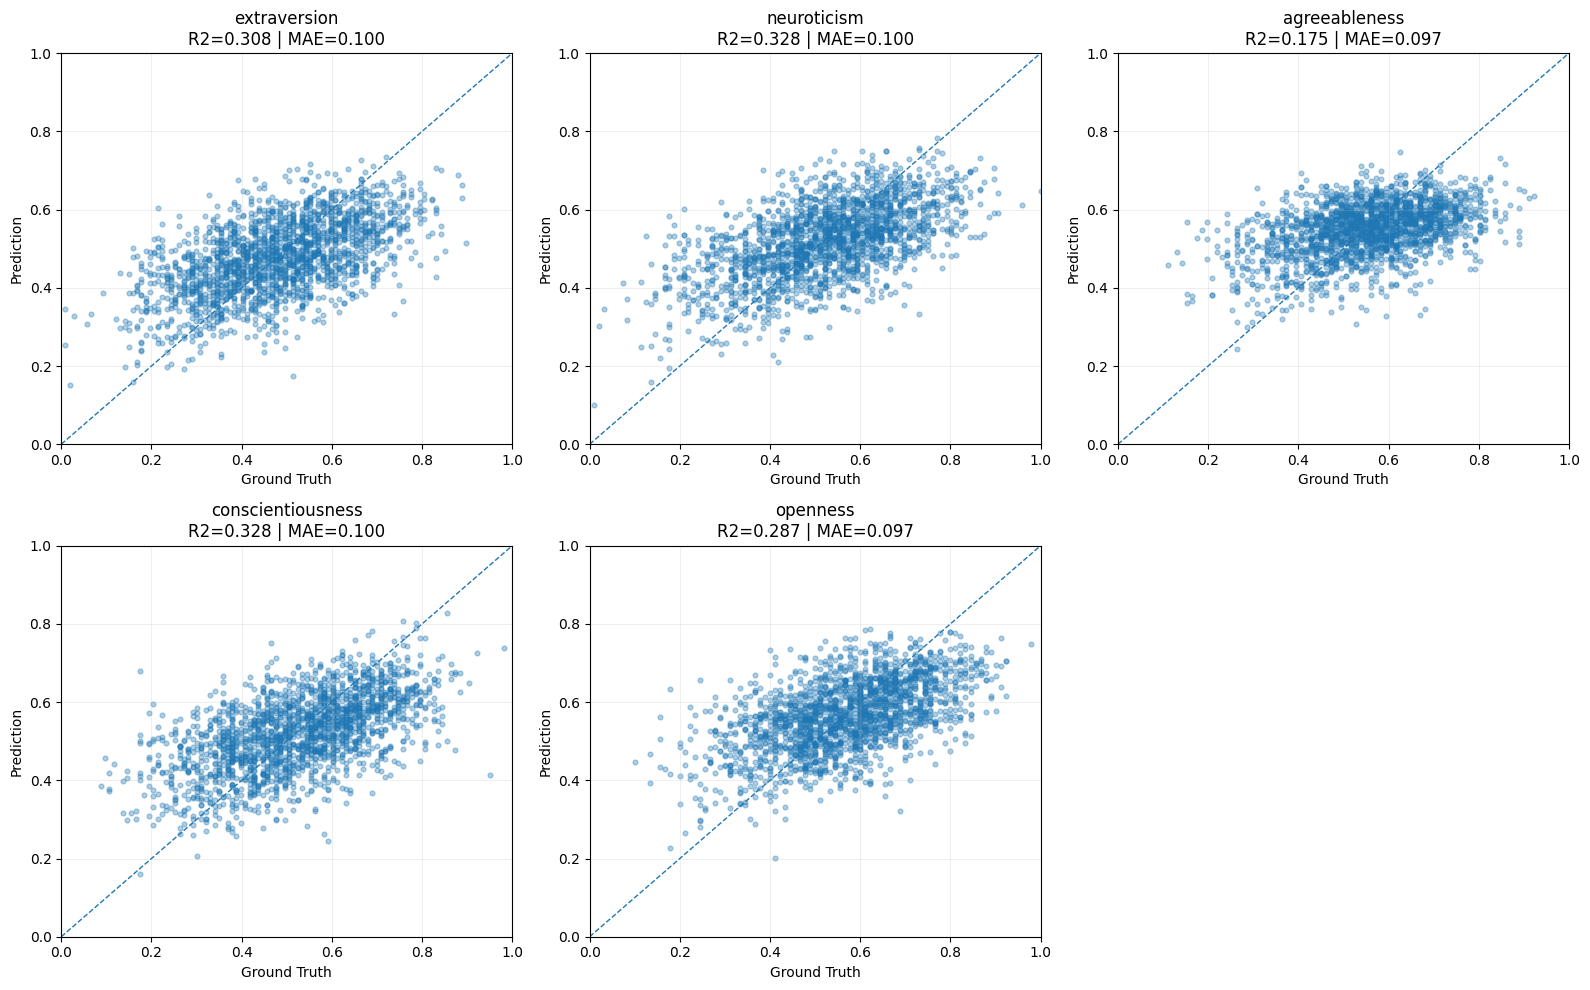

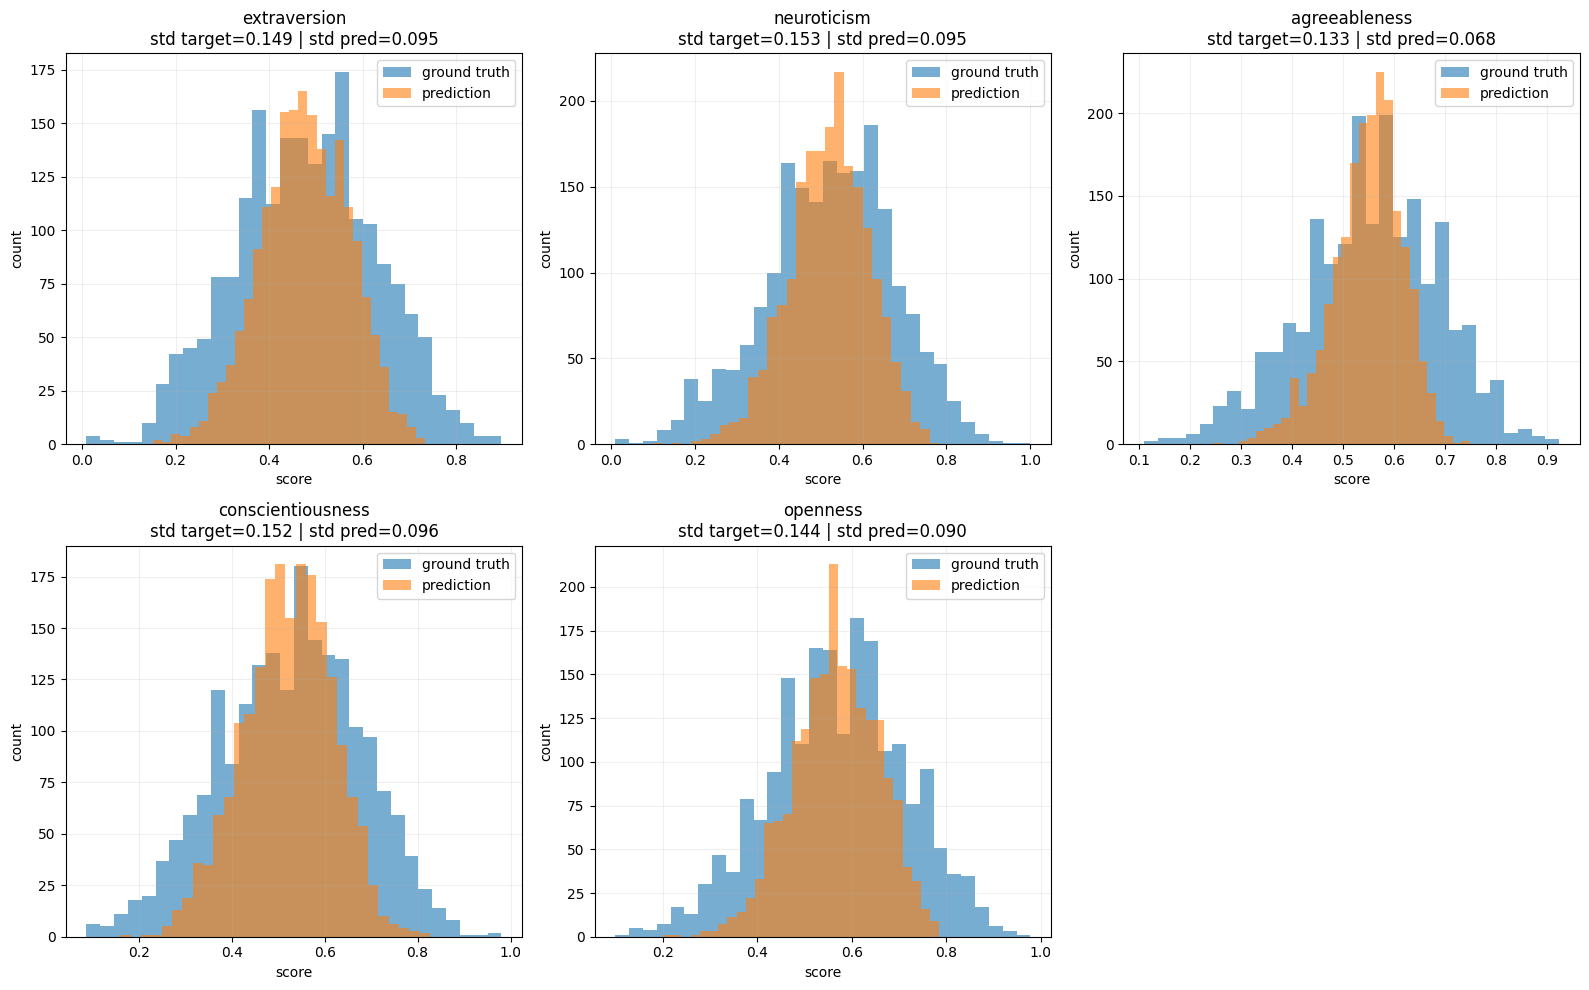


Backbone: wav2vec2
Split tag folder: baseline_official
Best alpha by validation mean MAE: 100.0
Best validation mean MAE: 0.097613
Best validation mean Acc(1-MAE): 0.902387
Best validation mean RMSE: 0.122423
Best validation mean R2: 0.278639
Interpretation: best alpha tidak berada di ujung kanan grid. Artinya sudah mulai terlihat titik optimal / titik balik, sehingga alpha yang terlalu besar tidak selalu memperbaiki performa.

Saved all outputs to: E:\tugas-akhir-qiqi\output\V2\baseline_official\results\wav2vec2
Saved figures to    : E:\tugas-akhir-qiqi\output\V2\baseline_official\results\wav2vec2\figures


In [9]:
# =========================
# 3) Train Ridge Regressor + Alpha Sweep + Diagnostics
# =========================

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# CONFIG
# =========================

# pilih backbone yang embedding-nya kamu reuse
BACKBONE_KEY = "wav2vec2"   # "wav2vec2" / "wavlm"

# NOTE:
# Aku pertahankan struktur folder mengikuti cell kamu yang sekarang.
# Kalau foldermu sebenarnya versi strict, ganti "baseline_official" -> "baseline_strict"
SPLIT_TAG = "baseline_official"

# alpha grid diperluas untuk membuktikan:
# apakah makin besar alpha terus membaik, atau ada titik balik
ALPHAS = np.array([
    1e-3, 3e-3,
    1e-2, 3e-2,
    1e-1, 3e-1,
    1, 3,
    10, 30,
    100, 300,
    1_000, 3_000,
    10_000, 30_000,
    100_000
], dtype=float)

assert "ROOT" in globals()
assert "df_train" in globals() and "df_val" in globals() and "df_test" in globals()

EMB_DIR = ROOT / "output" / "V2" / SPLIT_TAG / "embeddings" / BACKBONE_KEY
OUT_DIR = ROOT / "output" / "V2" / SPLIT_TAG / "results" / BACKBONE_KEY
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

assert EMB_DIR.exists(), f"EMB_DIR tidak ada: {EMB_DIR}"

# =========================
# LOAD DATA
# =========================

def load_split(split: str):
    X = np.load(EMB_DIR / f"{split}_emb.npy")
    ids = pd.read_csv(EMB_DIR / f"{split}_clip_id.csv")["clip_id"].astype(str).tolist()
    return X, ids

def align_X_to_df(X, ids, df, name=""):
    id2i = {cid: i for i, cid in enumerate(ids)}
    target_ids = df["clip_id"].astype(str).tolist()

    order = []
    missing = []
    for cid in target_ids:
        i = id2i.get(cid)
        if i is None:
            missing.append(cid)
            order.append(-1)
        else:
            order.append(i)

    if missing:
        print(f"[WARN] {name}: missing embeddings = {len(missing)} / {len(target_ids)} | contoh 5: {missing[:5]}")
        raise ValueError(f"Missing embeddings for {name}: {len(missing)}")

    X_aligned = X[np.array(order)]
    return X_aligned, target_ids

# load + align
X_train_raw, train_ids_raw = load_split("train")
X_val_raw,   val_ids_raw   = load_split("val")
X_test_raw,  test_ids_raw  = load_split("test")

X_train, train_ids = align_X_to_df(X_train_raw, train_ids_raw, df_train, "train")
X_val,   val_ids   = align_X_to_df(X_val_raw,   val_ids_raw,   df_val,   "val")
X_test,  test_ids  = align_X_to_df(X_test_raw,  test_ids_raw,  df_test,  "test")

print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)

# =========================
# LABEL DETECTION
# =========================

def detect_label_cols(df):
    exclude = set([
        c for c in df.columns
        if any(k in c.lower() for k in [
            "clip", "id", "path", "file", "group", "split",
            "ethnicity", "gender", "avg_trait"
        ])
    ])
    num_cols = [c for c in df.columns if (c not in exclude) and pd.api.types.is_numeric_dtype(df[c])]
    if len(num_cols) < 5:
        raise ValueError(f"Kolom numerik kandidat label kurang dari 5: {num_cols}")
    return num_cols[:5]

label_cols = detect_label_cols(df_train)
print("Label cols:", label_cols)

y_train = df_train[label_cols].to_numpy(dtype=np.float32)
y_val   = df_val[label_cols].to_numpy(dtype=np.float32)
y_test  = df_test[label_cols].to_numpy(dtype=np.float32)

# =========================
# SCALE EMBEDDINGS
# =========================

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# =========================
# METRIC HELPERS
# =========================

def make_metrics_df(y_true, y_pred, split_name=""):
    mae  = mean_absolute_error(y_true, y_pred, multioutput="raw_values")
    rmse = np.sqrt(mean_squared_error(y_true, y_pred, multioutput="raw_values"))
    r2   = r2_score(y_true, y_pred, multioutput="raw_values")
    acc  = 1.0 - mae

    dfm = pd.DataFrame({
        "split": split_name,
        "trait": label_cols,
        "Acc(1-MAE)": acc,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    })

    mean_row = pd.DataFrame([{
        "split": split_name,
        "trait": "mean",
        "Acc(1-MAE)": acc.mean(),
        "MAE": mae.mean(),
        "RMSE": rmse.mean(),
        "R2": r2.mean(),
    }])

    return pd.concat([dfm, mean_row], ignore_index=True)

def show_metrics(dfm, title):
    print(f"\n== {title} ==")
    try:
        display(dfm)
    except Exception:
        print(dfm)

def extract_mean_row(dfm):
    row = dfm[dfm["trait"] == "mean"].iloc[0]
    return {
        "Acc(1-MAE)": float(row["Acc(1-MAE)"]),
        "MAE": float(row["MAE"]),
        "RMSE": float(row["RMSE"]),
        "R2": float(row["R2"]),
    }

# =========================
# ALPHA SWEEP (VALIDATION ONLY FOR MODEL SELECTION)
# =========================

alpha_rows = []
alpha_trait_rows = []

best_alpha = None
best_val_mae = np.inf
best_model = None

for a in ALPHAS:
    ridge = Ridge(alpha=float(a), random_state=42)
    model = MultiOutputRegressor(ridge)
    model.fit(X_train_s, y_train)

    pred_val = model.predict(X_val_s)
    df_val_metrics = make_metrics_df(y_val, pred_val, split_name="val")
    mean_metrics = extract_mean_row(df_val_metrics)

    # mean coefficient norm, buat lihat efek shrinkage saat alpha membesar
    coef_norms = [np.linalg.norm(est.coef_) for est in model.estimators_]
    intercept_norms = [np.linalg.norm(np.atleast_1d(est.intercept_)) for est in model.estimators_]

    alpha_rows.append({
        "alpha": float(a),
        "val_Acc(1-MAE)": mean_metrics["Acc(1-MAE)"],
        "val_MAE": mean_metrics["MAE"],
        "val_RMSE": mean_metrics["RMSE"],
        "val_R2": mean_metrics["R2"],
        "mean_coef_norm": float(np.mean(coef_norms)),
        "mean_intercept_norm": float(np.mean(intercept_norms)),
    })

    tmp_trait = df_val_metrics[df_val_metrics["trait"] != "mean"].copy()
    tmp_trait["alpha"] = float(a)
    alpha_trait_rows.append(tmp_trait)

    print(
        f"alpha={a:>9.4g} | "
        f"val MAE={mean_metrics['MAE']:.6f} | "
        f"val Acc={mean_metrics['Acc(1-MAE)']:.6f} | "
        f"val RMSE={mean_metrics['RMSE']:.6f} | "
        f"val R2={mean_metrics['R2']:.6f}"
    )

    if mean_metrics["MAE"] < best_val_mae:
        best_val_mae = mean_metrics["MAE"]
        best_alpha = float(a)
        best_model = model

alpha_sweep_df = pd.DataFrame(alpha_rows).sort_values("alpha").reset_index(drop=True)
alpha_trait_df = pd.concat(alpha_trait_rows, ignore_index=True)

print(f"\nBest alpha = {best_alpha} | best val mean MAE = {best_val_mae:.6f}")

# simpan summary alpha sweep
alpha_sweep_df.to_csv(OUT_DIR / "alpha_sweep_summary.csv", index=False)
alpha_trait_df.to_csv(OUT_DIR / "alpha_sweep_per_trait.csv", index=False)

# =========================
# FINAL EVAL WITH BEST ALPHA
# =========================

model = best_model
pred_val  = model.predict(X_val_s)
pred_test = model.predict(X_test_s)

m_val  = make_metrics_df(y_val, pred_val, split_name="val")
m_test = make_metrics_df(y_test, pred_test, split_name="test")

show_metrics(m_val,  f"{BACKBONE_KEY} | {SPLIT_TAG.upper()} | VAL")
show_metrics(m_test, f"{BACKBONE_KEY} | {SPLIT_TAG.upper()} | TEST")

# =========================
# SAVE PREDICTIONS
# =========================

pred_val_df = pd.DataFrame({
    "clip_id": val_ids,
    **{f"gt_{c}": y_val[:, i] for i, c in enumerate(label_cols)},
    **{f"pred_{c}": pred_val[:, i] for i, c in enumerate(label_cols)},
})
pred_test_df = pd.DataFrame({
    "clip_id": test_ids,
    **{f"gt_{c}": y_test[:, i] for i, c in enumerate(label_cols)},
    **{f"pred_{c}": pred_test[:, i] for i, c in enumerate(label_cols)},
})

pred_val_df.to_csv(OUT_DIR / "pred_val_full.csv", index=False)
pred_test_df.to_csv(OUT_DIR / "pred_test_full.csv", index=False)

# metrik final
m_val.to_csv(OUT_DIR / "metrics_val.csv", index=False)
m_test.to_csv(OUT_DIR / "metrics_test.csv", index=False)

# model + scaler
joblib.dump(scaler, OUT_DIR / "scaler.joblib")
joblib.dump(model,  OUT_DIR / "ridge_multioutput.joblib")

# =========================
# DIAGNOSIS: KENAPA R2 KECIL?
# =========================

# baseline naif: prediksi selalu mean train
train_mean = y_train.mean(axis=0)
naive_pred_test = np.tile(train_mean, (len(y_test), 1))

test_mae  = mean_absolute_error(y_test, pred_test, multioutput="raw_values")
test_rmse = np.sqrt(mean_squared_error(y_test, pred_test, multioutput="raw_values"))
test_r2   = r2_score(y_test, pred_test, multioutput="raw_values")

naive_mae  = mean_absolute_error(y_test, naive_pred_test, multioutput="raw_values")
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred_test, multioutput="raw_values"))
naive_r2   = r2_score(y_test, naive_pred_test, multioutput="raw_values")

target_mean = y_test.mean(axis=0)
target_std  = y_test.std(axis=0, ddof=0)
target_var  = y_test.var(axis=0, ddof=0)

pred_mean = pred_test.mean(axis=0)
pred_std  = pred_test.std(axis=0, ddof=0)

diag_rows = []
for i, trait in enumerate(label_cols):
    diag_rows.append({
        "trait": trait,
        "target_mean": float(target_mean[i]),
        "target_std": float(target_std[i]),
        "target_var": float(target_var[i]),
        "pred_mean": float(pred_mean[i]),
        "pred_std": float(pred_std[i]),
        "pred_std_over_target_std": float(pred_std[i] / target_std[i]) if target_std[i] > 0 else np.nan,
        "MAE_model": float(test_mae[i]),
        "RMSE_model": float(test_rmse[i]),
        "R2_model": float(test_r2[i]),
        "MAE_naive_train_mean": float(naive_mae[i]),
        "RMSE_naive_train_mean": float(naive_rmse[i]),
        "R2_naive_train_mean": float(naive_r2[i]),
        "RMSE_improvement_vs_naive": float(naive_rmse[i] - test_rmse[i]),
        "RMSE_over_target_std": float(test_rmse[i] / target_std[i]) if target_std[i] > 0 else np.nan,
    })

diag_df = pd.DataFrame(diag_rows)
diag_df.to_csv(OUT_DIR / "r2_diagnosis_test.csv", index=False)

try:
    display(diag_df)
except Exception:
    print(diag_df)

# =========================
# PLOTS
# =========================

# 1) mean metric sweep
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metric_map = [
    ("val_MAE", "Validation Mean MAE"),
    ("val_Acc(1-MAE)", "Validation Mean Acc(1-MAE)"),
    ("val_RMSE", "Validation Mean RMSE"),
    ("val_R2", "Validation Mean R2"),
]

for ax, (col, title) in zip(axes.flatten(), metric_map):
    ax.plot(alpha_sweep_df["alpha"], alpha_sweep_df[col], marker="o")
    ax.axvline(best_alpha, linestyle="--", linewidth=1, label=f"best={best_alpha:g}")
    ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel("alpha (log scale)")
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "alpha_sweep_mean_metrics.png", dpi=200, bbox_inches="tight")
plt.show()

# 2) per-trait MAE vs alpha
plt.figure(figsize=(10, 6))
for trait in label_cols:
    d = alpha_trait_df[alpha_trait_df["trait"] == trait].sort_values("alpha")
    plt.plot(d["alpha"], d["MAE"], marker="o", label=trait)
plt.axvline(best_alpha, linestyle="--", linewidth=1, label=f"best={best_alpha:g}")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("MAE")
plt.title("Validation MAE per Trait vs Alpha")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "alpha_sweep_per_trait_mae.png", dpi=200, bbox_inches="tight")
plt.show()

# 3) per-trait R2 vs alpha
plt.figure(figsize=(10, 6))
for trait in label_cols:
    d = alpha_trait_df[alpha_trait_df["trait"] == trait].sort_values("alpha")
    plt.plot(d["alpha"], d["R2"], marker="o", label=trait)
plt.axvline(best_alpha, linestyle="--", linewidth=1, label=f"best={best_alpha:g}")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("R2")
plt.title("Validation R2 per Trait vs Alpha")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "alpha_sweep_per_trait_r2.png", dpi=200, bbox_inches="tight")
plt.show()

# 4) coefficient norm vs alpha (melihat shrinkage ridge)
plt.figure(figsize=(10, 6))
plt.plot(alpha_sweep_df["alpha"], alpha_sweep_df["mean_coef_norm"], marker="o")
plt.axvline(best_alpha, linestyle="--", linewidth=1, label=f"best={best_alpha:g}")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("mean coefficient norm")
plt.title("Mean Coefficient Norm vs Alpha")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "alpha_sweep_coef_norm.png", dpi=200, bbox_inches="tight")
plt.show()

# 5) target std vs prediction std (diagnosis regression-to-the-mean)
x = np.arange(len(label_cols))
w = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - w/2, diag_df["target_std"], width=w, label="target std")
plt.bar(x + w/2, diag_df["pred_std"], width=w, label="prediction std")
plt.xticks(x, label_cols, rotation=20)
plt.ylabel("std")
plt.title("Target Std vs Prediction Std (Test)")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "diagnosis_target_std_vs_pred_std.png", dpi=200, bbox_inches="tight")
plt.show()

# 6) RMSE model vs RMSE naive
plt.figure(figsize=(10, 6))
plt.bar(x - w/2, diag_df["RMSE_naive_train_mean"], width=w, label="naive RMSE")
plt.bar(x + w/2, diag_df["RMSE_model"], width=w, label="model RMSE")
plt.xticks(x, label_cols, rotation=20)
plt.ylabel("RMSE")
plt.title("Model RMSE vs Naive Mean-Predictor RMSE (Test)")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "diagnosis_rmse_model_vs_naive.png", dpi=200, bbox_inches="tight")
plt.show()

# 7) scatter pred vs gt per trait
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, trait in enumerate(label_cols):
    ax = axes[i]
    ax.scatter(y_test[:, i], pred_test[:, i], s=12, alpha=0.35)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_title(f"{trait}\nR2={test_r2[i]:.3f} | MAE={test_mae[i]:.3f}")
    ax.set_xlabel("Ground Truth")
    ax.set_ylabel("Prediction")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.2)

# hapus subplot kosong kalau ada
for j in range(len(label_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(FIG_DIR / "scatter_pred_vs_gt_test.png", dpi=200, bbox_inches="tight")
plt.show()

# 8) histogram distribusi prediksi vs target
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, trait in enumerate(label_cols):
    ax = axes[i]
    ax.hist(y_test[:, i], bins=30, alpha=0.6, label="ground truth")
    ax.hist(pred_test[:, i], bins=30, alpha=0.6, label="prediction")
    ax.set_title(
        f"{trait}\nstd target={target_std[i]:.3f} | std pred={pred_std[i]:.3f}"
    )
    ax.set_xlabel("score")
    ax.set_ylabel("count")
    ax.grid(True, alpha=0.2)
    ax.legend()

for j in range(len(label_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(FIG_DIR / "hist_target_vs_prediction_test.png", dpi=200, bbox_inches="tight")
plt.show()

# =========================
# AUTO SUMMARY
# =========================

best_idx = alpha_sweep_df["val_MAE"].idxmin()
best_alpha_from_df = alpha_sweep_df.loc[best_idx, "alpha"]
is_best_at_right_edge = np.isclose(best_alpha_from_df, alpha_sweep_df["alpha"].max())

summary_lines = []
summary_lines.append(f"Backbone: {BACKBONE_KEY}")
summary_lines.append(f"Split tag folder: {SPLIT_TAG}")
summary_lines.append(f"Best alpha by validation mean MAE: {best_alpha}")
summary_lines.append(f"Best validation mean MAE: {best_val_mae:.6f}")
summary_lines.append(f"Best validation mean Acc(1-MAE): {alpha_sweep_df.loc[best_idx, 'val_Acc(1-MAE)']:.6f}")
summary_lines.append(f"Best validation mean RMSE: {alpha_sweep_df.loc[best_idx, 'val_RMSE']:.6f}")
summary_lines.append(f"Best validation mean R2: {alpha_sweep_df.loc[best_idx, 'val_R2']:.6f}")

if is_best_at_right_edge:
    summary_lines.append(
        "Interpretation: best alpha masih berada di ujung kanan grid. "
        "Ini berarti belum ada bukti kuat bahwa performa sudah mencapai titik balik. "
        "Kalau dosen ingin pembuktian lebih jauh, alpha bisa diperbesar lagi."
    )
else:
    summary_lines.append(
        "Interpretation: best alpha tidak berada di ujung kanan grid. "
        "Artinya sudah mulai terlihat titik optimal / titik balik, sehingga alpha yang terlalu besar "
        "tidak selalu memperbaiki performa."
    )



summary_text = "\n".join(summary_lines)
print("\n" + "="*80)
print(summary_text)
print("="*80)

(OUT_DIR / "ridge_analysis_summary.txt").write_text(summary_text, encoding="utf-8")

# =========================
# SAVE META
# =========================

meta = {
    "backbone": BACKBONE_KEY,
    "split_tag": SPLIT_TAG,
    "best_alpha": float(best_alpha),
    "alpha_grid": [float(a) for a in ALPHAS],
    "label_cols": label_cols,
    "shapes": {
        "train": list(X_train.shape),
        "val": list(X_val.shape),
        "test": list(X_test.shape),
    },
    "saved_files": [
        "alpha_sweep_summary.csv",
        "alpha_sweep_per_trait.csv",
        "metrics_val.csv",
        "metrics_test.csv",
        "pred_val_full.csv",
        "pred_test_full.csv",
        "r2_diagnosis_test.csv",
        "ridge_analysis_summary.txt",
        "scaler.joblib",
        "ridge_multioutput.joblib",
    ],
    "saved_figures": [
        "alpha_sweep_mean_metrics.png",
        "alpha_sweep_per_trait_mae.png",
        "alpha_sweep_per_trait_r2.png",
        "alpha_sweep_coef_norm.png",
        "diagnosis_target_std_vs_pred_std.png",
        "diagnosis_rmse_model_vs_naive.png",
        "scatter_pred_vs_gt_test.png",
        "hist_target_vs_prediction_test.png",
    ],
}
(OUT_DIR / "meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")

print(f"\nSaved all outputs to: {OUT_DIR}")
print(f"Saved figures to    : {FIG_DIR}")

# **REUSE EMBEDDING V1 - WAVLM**

In [10]:
# =========================
# 2) Reuse embedding dari baseline_official -> align ke STRICT split (by clip_id)
# =========================

import numpy as np
import pandas as pd
from pathlib import Path

assert "ROOT" in globals()
assert "df_train" in globals() and "df_val" in globals() and "df_test" in globals()

BACKBONE_KEY = "wavlm"   # ganti: "wav2vec2" / "wavlm"

# lokasi embedding yang sudah ada (official)
EMB_DIR_OFF = ROOT / "output" / "V1" / "baseline_official" / "embeddings" / BACKBONE_KEY
assert EMB_DIR_OFF.exists(), f"Folder embedding official tidak ada: {EMB_DIR_OFF}"

def load_official_split(split: str):
    X = np.load(EMB_DIR_OFF / f"{split}_emb.npy", mmap_mode="r")
    ids = pd.read_csv(EMB_DIR_OFF / f"{split}_clip_id.csv")["clip_id"].astype(str).tolist()
    return X, ids

# load pool embedding dari official train/val/test
X_off = {}
ids_off = {}

for split in ["train", "val", "test"]:
    X_off[split], ids_off[split] = load_official_split(split)
    print(f"[OFFICIAL] {split}: X={X_off[split].shape} ids={len(ids_off[split])}")

# build mapping clip_id -> (split, idx)
id2loc = {}
dup = 0
for split in ["train", "val", "test"]:
    for i, cid in enumerate(ids_off[split]):
        if cid in id2loc:
            dup += 1
        id2loc[cid] = (split, i)

if dup > 0:
    print(f"[WARN] Duplicated clip_id across official splits: {dup} (harusnya 0).")

H = int(X_off["train"].shape[1])
print("Hidden size (H):", H)

def build_X_from_strict(df_split: pd.DataFrame, name: str):
    ids = df_split["clip_id"].astype(str).tolist()
    X = np.zeros((len(ids), H), dtype=np.float32)

    missing = []
    for j, cid in enumerate(ids):
        loc = id2loc.get(cid)
        if loc is None:
            missing.append(cid)
            continue
        sp, i = loc
        X[j] = X_off[sp][i]  # ambil dari memmap official

    if missing:
        print(f"[WARN] {name}: missing embeddings = {len(missing)} / {len(ids)} (contoh 5): {missing[:5]}")
        # kalau kamu mau strict fail biar ketahuan:
        # raise ValueError(f"Missing embeddings in {name}: {len(missing)}")

    print(f"[STRICT] {name}: X={X.shape} ids={len(ids)}")
    return X, ids

# align ke strict split
X_train, train_ids = build_X_from_strict(df_train, "train")
X_val,   val_ids   = build_X_from_strict(df_val,   "val")
X_test,  test_ids  = build_X_from_strict(df_test,  "test")

# (opsional) cache ulang supaya notebook strict mirip baseline official
OFFICIAL_EMB_DIR = ROOT / "output" / "V2" / "baseline_official" / "embeddings" / BACKBONE_KEY
OFFICIAL_EMB_DIR.mkdir(parents=True, exist_ok=True)

np.save(OFFICIAL_EMB_DIR / "train_emb.npy", X_train)
np.save(OFFICIAL_EMB_DIR / "val_emb.npy",   X_val)
np.save(OFFICIAL_EMB_DIR / "test_emb.npy",  X_test)

pd.DataFrame({"clip_id": train_ids}).to_csv(OFFICIAL_EMB_DIR / "train_clip_id.csv", index=False)
pd.DataFrame({"clip_id": val_ids}).to_csv(OFFICIAL_EMB_DIR / "val_clip_id.csv", index=False)
pd.DataFrame({"clip_id": test_ids}).to_csv(OFFICIAL_EMB_DIR / "test_clip_id.csv", index=False)

print("Saved embeddings to:", OFFICIAL_EMB_DIR)


[OFFICIAL] train: X=(5988, 768) ids=5988
[OFFICIAL] val: X=(1994, 768) ids=1994
[OFFICIAL] test: X=(1992, 768) ids=1992
Hidden size (H): 768
[STRICT] train: X=(5988, 768) ids=5988
[STRICT] val: X=(1994, 768) ids=1994
[STRICT] test: X=(1992, 768) ids=1992
Saved embeddings to: E:\tugas-akhir-qiqi\output\V2\baseline_official\embeddings\wavlm


X_train: (5988, 768) | X_val: (1994, 768) | X_test: (1992, 768)
Label cols: ['extraversion', 'neuroticism', 'agreeableness', 'conscientiousness', 'openness']
alpha=    0.001 | val MAE=0.098106 | val Acc=0.901894 | val RMSE=0.123422 | val R2=0.264314
alpha=    0.003 | val MAE=0.098106 | val Acc=0.901894 | val RMSE=0.123421 | val R2=0.264319
alpha=     0.01 | val MAE=0.098104 | val Acc=0.901896 | val RMSE=0.123420 | val R2=0.264338
alpha=     0.03 | val MAE=0.098101 | val Acc=0.901899 | val RMSE=0.123415 | val R2=0.264389
alpha=      0.1 | val MAE=0.098088 | val Acc=0.901912 | val RMSE=0.123401 | val R2=0.264565
alpha=      0.3 | val MAE=0.098054 | val Acc=0.901946 | val RMSE=0.123360 | val R2=0.265056
alpha=        1 | val MAE=0.097939 | val Acc=0.902061 | val RMSE=0.123224 | val R2=0.266688
alpha=        3 | val MAE=0.097657 | val Acc=0.902343 | val RMSE=0.122886 | val R2=0.270726
alpha=       10 | val MAE=0.097003 | val Acc=0.902997 | val RMSE=0.122078 | val R2=0.280384
alpha=       3

,split,trait,Acc(1-MAE),MAE,RMSE,R2
0,val,extraversion,0.904020,0.095980,0.119774,0.343324
1,val,neuroticism,0.904718,0.095282,0.119541,0.360015
2,val,agreeableness,0.909534,0.090466,0.114640,0.188044
3,val,conscientiousness,0.902044,0.097956,0.123656,0.368035
4,val,openness,0.907197,0.092803,0.116865,0.333946
5,val,mean,0.905503,0.094497,0.118895,0.318673



== wavlm | BASELINE_OFFICIAL | TEST ==


,split,trait,Acc(1-MAE),MAE,RMSE,R2
0,test,extraversion,0.902349,0.097651,0.121489,0.339560
1,test,neuroticism,0.903024,0.096976,0.122621,0.355580
2,test,agreeableness,0.904791,0.095209,0.119273,0.193316
3,test,conscientiousness,0.902758,0.097242,0.122431,0.350883
4,test,openness,0.905193,0.094807,0.118362,0.325928
5,test,mean,0.903623,0.096377,0.120835,0.313054


,trait,target_mean,target_std,target_var,pred_mean,pred_std,pred_std_over_target_std,MAE_model,RMSE_model,R2_model,MAE_naive_train_mean,RMSE_naive_train_mean,R2_naive_train_mean,RMSE_improvement_vs_naive,RMSE_over_target_std
0,extraversion,0.478489,0.149493,0.022348,0.475531,0.092379,0.617952,0.097651,0.121489,0.339560,0.121490,0.149510,-0.000230,0.028021,0.812675
1,neuroticism,0.522392,0.152750,0.023333,0.519441,0.092486,0.605475,0.096976,0.122621,0.355580,0.122308,0.152762,-0.000156,0.030141,0.802758
2,agreeableness,0.552341,0.132797,0.017635,0.546504,0.065088,0.490130,0.095209,0.119273,0.193316,0.106054,0.132856,-0.000886,0.013583,0.898156
3,conscientiousness,0.526017,0.151960,0.023092,0.521927,0.094284,0.620453,0.097242,0.122431,0.350883,0.124981,0.151992,-0.000426,0.029562,0.805678
4,openness,0.568753,0.144165,0.020784,0.565911,0.085779,0.595006,0.094807,0.118362,0.325928,0.116458,0.144185,-0.000270,0.025822,0.821019


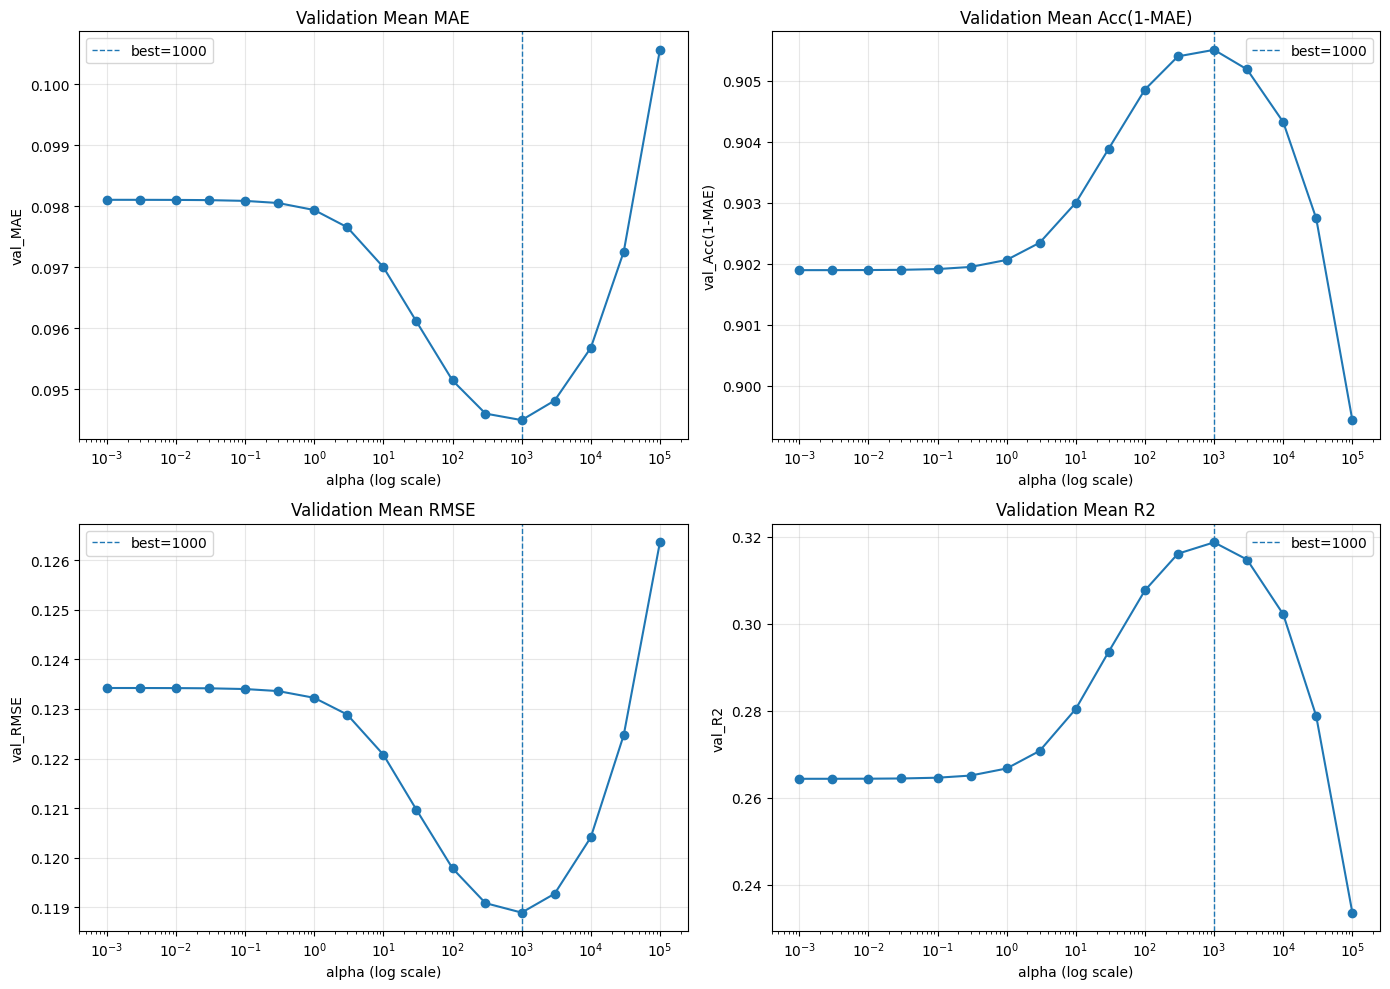

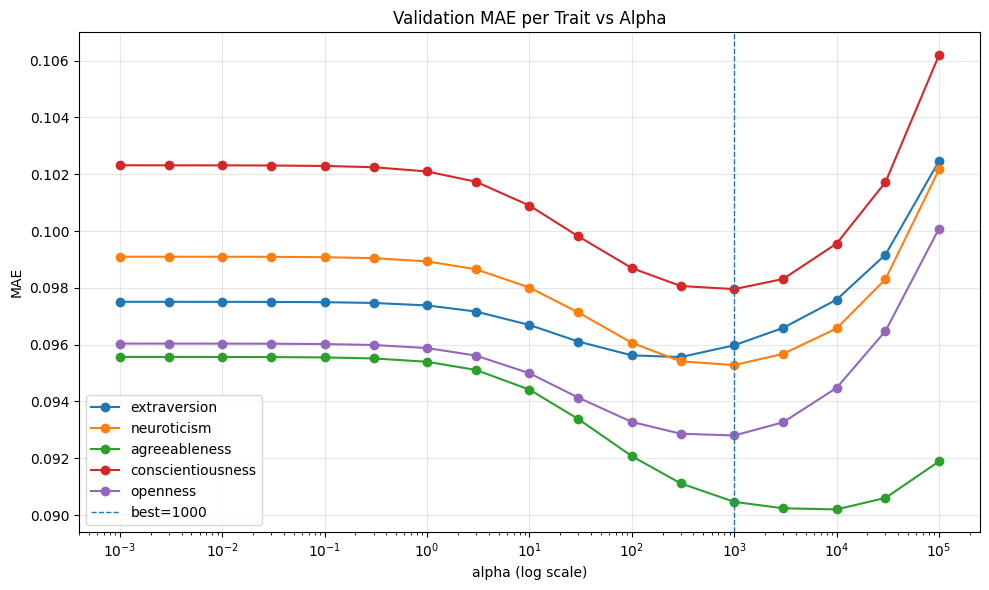

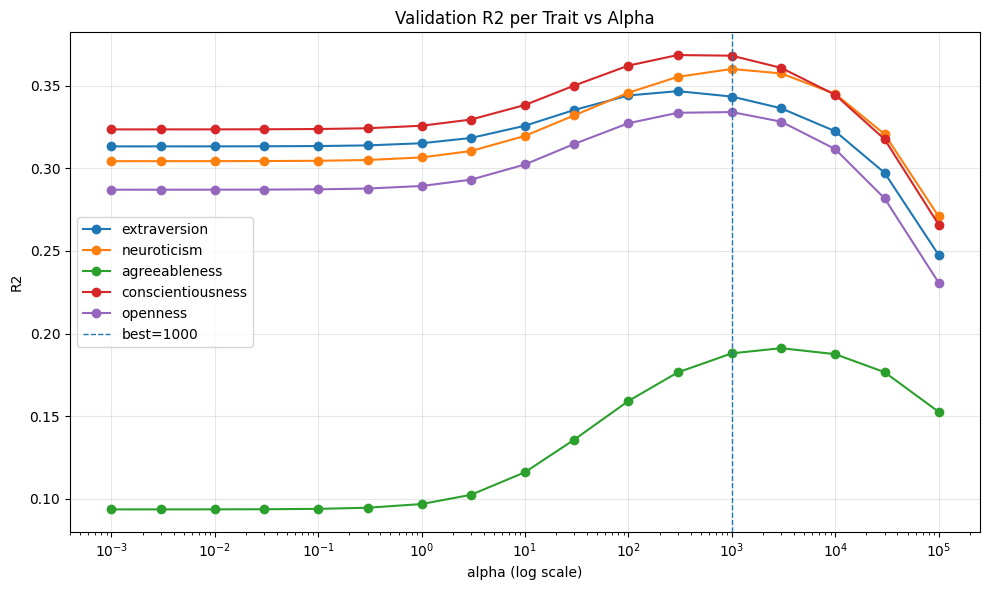

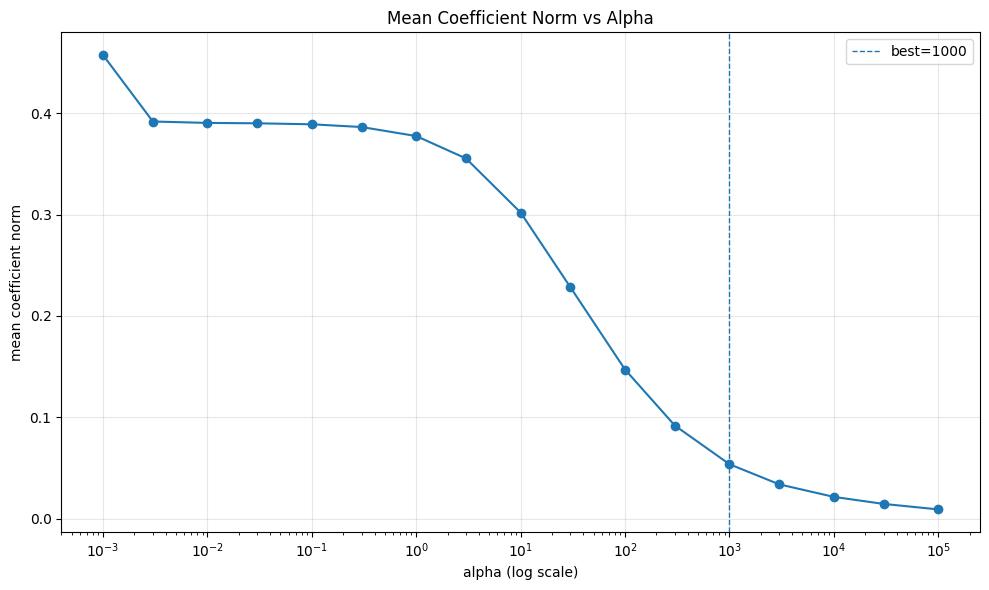

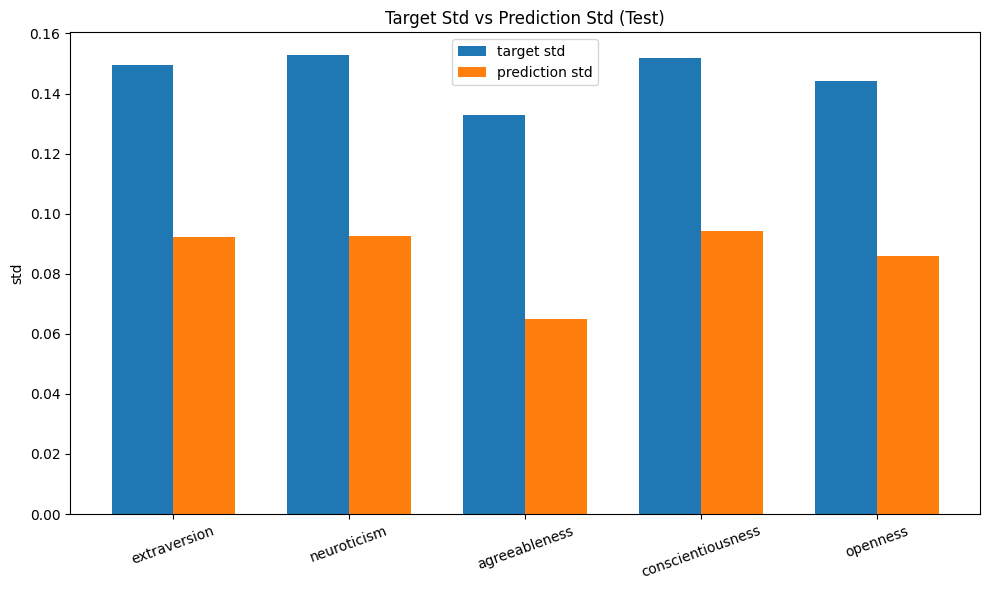

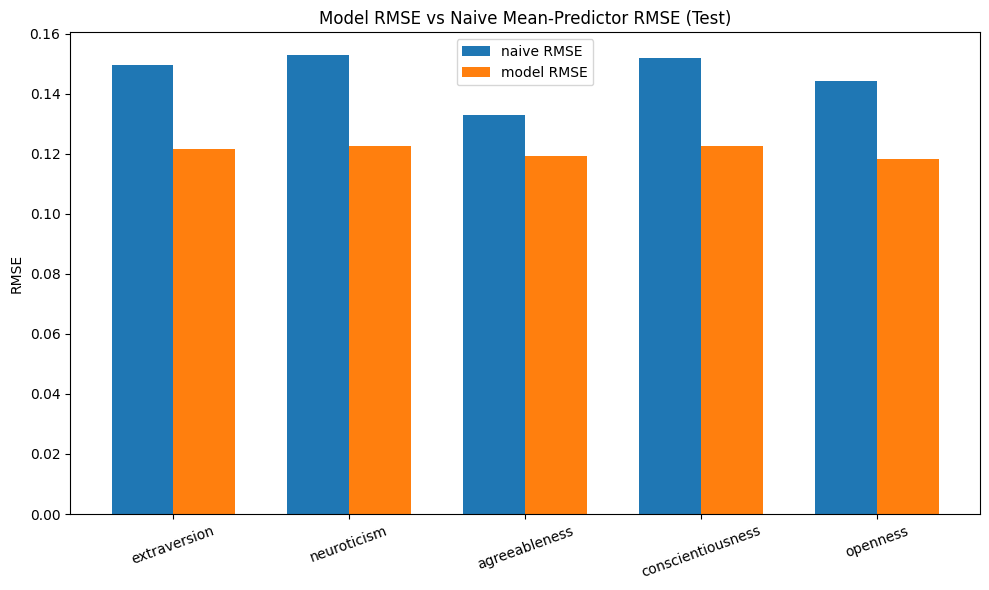

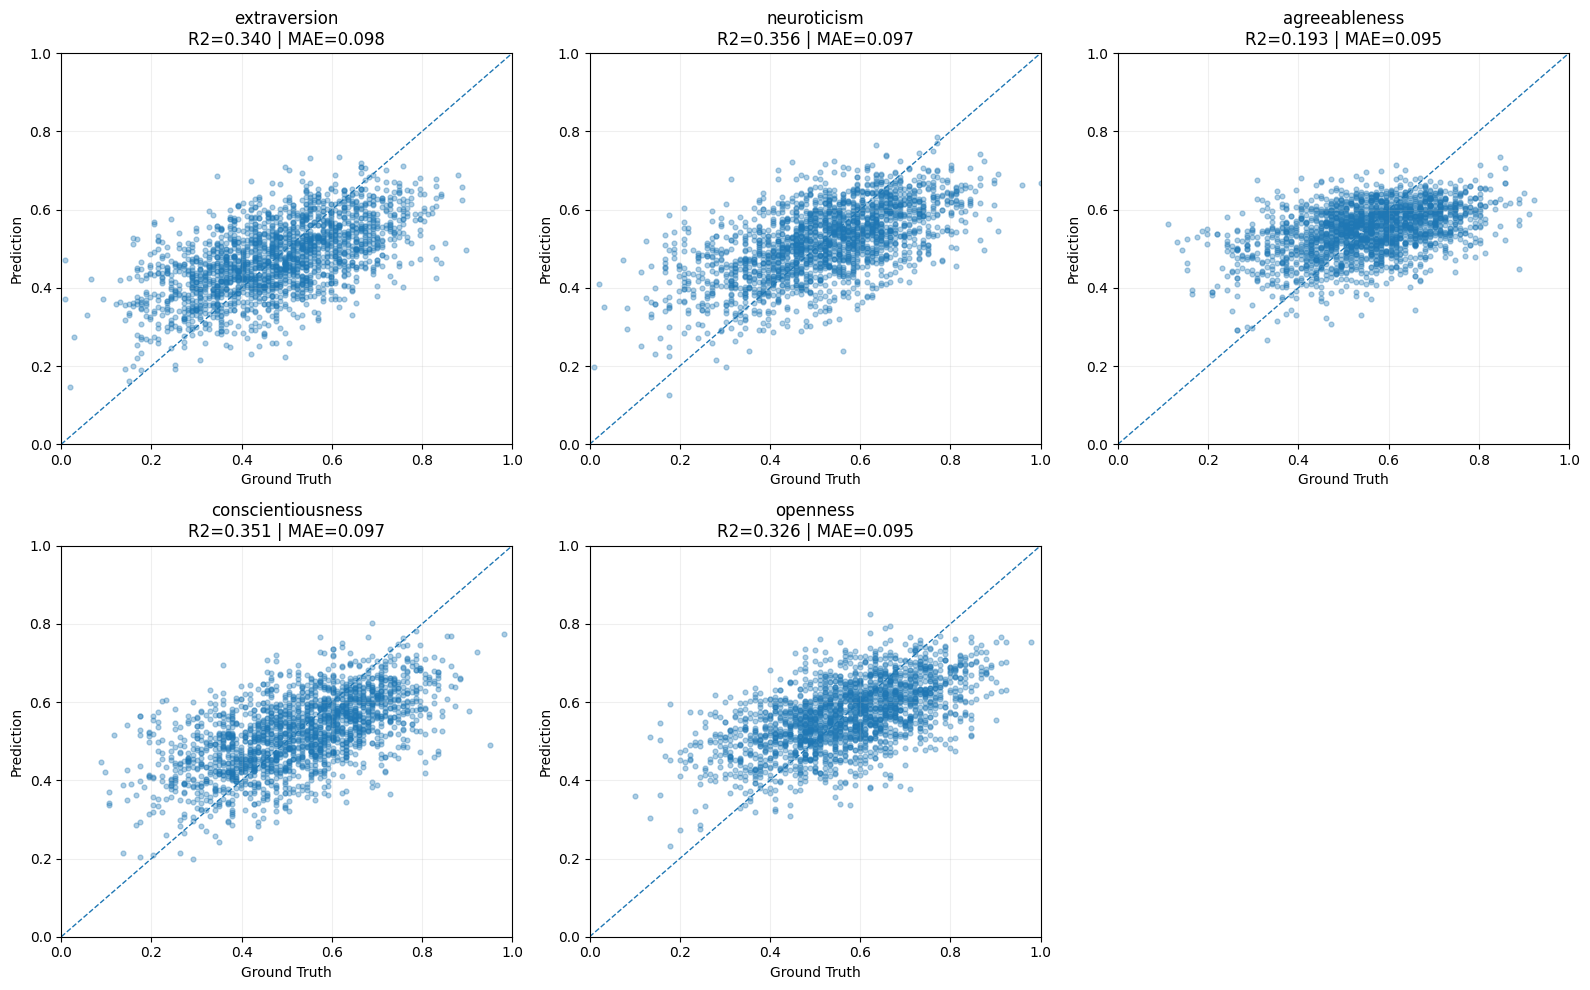

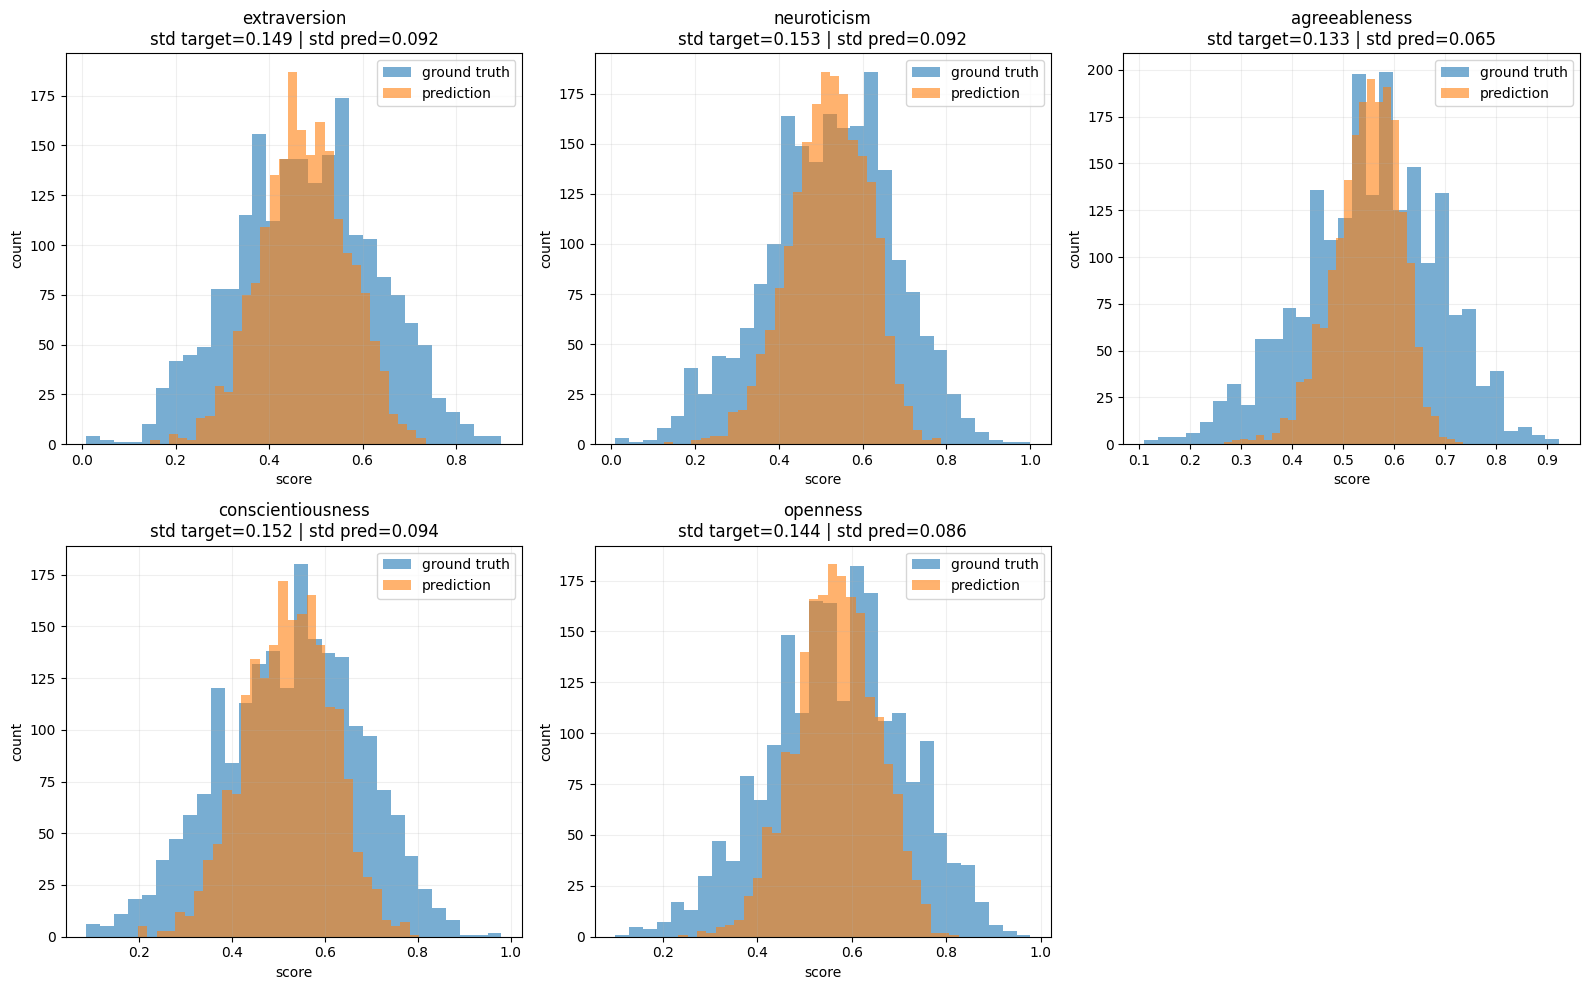


Backbone: wavlm
Split tag folder: baseline_official
Best alpha by validation mean MAE: 1000.0
Best validation mean MAE: 0.094497
Best validation mean Acc(1-MAE): 0.905503
Best validation mean RMSE: 0.118895
Best validation mean R2: 0.318673
Interpretation: best alpha tidak berada di ujung kanan grid. Artinya sudah mulai terlihat titik optimal / titik balik, sehingga alpha yang terlalu besar tidak selalu memperbaiki performa.

Saved all outputs to: E:\tugas-akhir-qiqi\output\V2\baseline_official\results\wavlm
Saved figures to    : E:\tugas-akhir-qiqi\output\V2\baseline_official\results\wavlm\figures


In [11]:
# =========================
# 3) Train Ridge Regressor + Alpha Sweep + Diagnostics
# =========================

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# CONFIG
# =========================

# pilih backbone yang embedding-nya kamu reuse
BACKBONE_KEY = "wavlm"   # "wav2vec2" / "wavlm"

# NOTE:
# Aku pertahankan struktur folder mengikuti cell kamu yang sekarang.
# Kalau foldermu sebenarnya versi strict, ganti "baseline_official" -> "baseline_strict"
SPLIT_TAG = "baseline_official"

# alpha grid diperluas untuk membuktikan:
# apakah makin besar alpha terus membaik, atau ada titik balik
ALPHAS = np.array([
    1e-3, 3e-3,
    1e-2, 3e-2,
    1e-1, 3e-1,
    1, 3,
    10, 30,
    100, 300,
    1_000, 3_000,
    10_000, 30_000,
    100_000
], dtype=float)

assert "ROOT" in globals()
assert "df_train" in globals() and "df_val" in globals() and "df_test" in globals()

EMB_DIR = ROOT / "output" / "V2" / SPLIT_TAG / "embeddings" / BACKBONE_KEY
OUT_DIR = ROOT / "output" / "V2" / SPLIT_TAG / "results" / BACKBONE_KEY
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

assert EMB_DIR.exists(), f"EMB_DIR tidak ada: {EMB_DIR}"

# =========================
# LOAD DATA
# =========================

def load_split(split: str):
    X = np.load(EMB_DIR / f"{split}_emb.npy")
    ids = pd.read_csv(EMB_DIR / f"{split}_clip_id.csv")["clip_id"].astype(str).tolist()
    return X, ids

def align_X_to_df(X, ids, df, name=""):
    id2i = {cid: i for i, cid in enumerate(ids)}
    target_ids = df["clip_id"].astype(str).tolist()

    order = []
    missing = []
    for cid in target_ids:
        i = id2i.get(cid)
        if i is None:
            missing.append(cid)
            order.append(-1)
        else:
            order.append(i)

    if missing:
        print(f"[WARN] {name}: missing embeddings = {len(missing)} / {len(target_ids)} | contoh 5: {missing[:5]}")
        raise ValueError(f"Missing embeddings for {name}: {len(missing)}")

    X_aligned = X[np.array(order)]
    return X_aligned, target_ids

# load + align
X_train_raw, train_ids_raw = load_split("train")
X_val_raw,   val_ids_raw   = load_split("val")
X_test_raw,  test_ids_raw  = load_split("test")

X_train, train_ids = align_X_to_df(X_train_raw, train_ids_raw, df_train, "train")
X_val,   val_ids   = align_X_to_df(X_val_raw,   val_ids_raw,   df_val,   "val")
X_test,  test_ids  = align_X_to_df(X_test_raw,  test_ids_raw,  df_test,  "test")

print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)

# =========================
# LABEL DETECTION
# =========================

def detect_label_cols(df):
    exclude = set([
        c for c in df.columns
        if any(k in c.lower() for k in [
            "clip", "id", "path", "file", "group", "split",
            "ethnicity", "gender", "avg_trait"
        ])
    ])
    num_cols = [c for c in df.columns if (c not in exclude) and pd.api.types.is_numeric_dtype(df[c])]
    if len(num_cols) < 5:
        raise ValueError(f"Kolom numerik kandidat label kurang dari 5: {num_cols}")
    return num_cols[:5]

label_cols = detect_label_cols(df_train)
print("Label cols:", label_cols)

y_train = df_train[label_cols].to_numpy(dtype=np.float32)
y_val   = df_val[label_cols].to_numpy(dtype=np.float32)
y_test  = df_test[label_cols].to_numpy(dtype=np.float32)

# =========================
# SCALE EMBEDDINGS
# =========================

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# =========================
# METRIC HELPERS
# =========================

def make_metrics_df(y_true, y_pred, split_name=""):
    mae  = mean_absolute_error(y_true, y_pred, multioutput="raw_values")
    rmse = np.sqrt(mean_squared_error(y_true, y_pred, multioutput="raw_values"))
    r2   = r2_score(y_true, y_pred, multioutput="raw_values")
    acc  = 1.0 - mae

    dfm = pd.DataFrame({
        "split": split_name,
        "trait": label_cols,
        "Acc(1-MAE)": acc,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    })

    mean_row = pd.DataFrame([{
        "split": split_name,
        "trait": "mean",
        "Acc(1-MAE)": acc.mean(),
        "MAE": mae.mean(),
        "RMSE": rmse.mean(),
        "R2": r2.mean(),
    }])

    return pd.concat([dfm, mean_row], ignore_index=True)

def show_metrics(dfm, title):
    print(f"\n== {title} ==")
    try:
        display(dfm)
    except Exception:
        print(dfm)

def extract_mean_row(dfm):
    row = dfm[dfm["trait"] == "mean"].iloc[0]
    return {
        "Acc(1-MAE)": float(row["Acc(1-MAE)"]),
        "MAE": float(row["MAE"]),
        "RMSE": float(row["RMSE"]),
        "R2": float(row["R2"]),
    }

# =========================
# ALPHA SWEEP (VALIDATION ONLY FOR MODEL SELECTION)
# =========================

alpha_rows = []
alpha_trait_rows = []

best_alpha = None
best_val_mae = np.inf
best_model = None

for a in ALPHAS:
    ridge = Ridge(alpha=float(a), random_state=42)
    model = MultiOutputRegressor(ridge)
    model.fit(X_train_s, y_train)

    pred_val = model.predict(X_val_s)
    df_val_metrics = make_metrics_df(y_val, pred_val, split_name="val")
    mean_metrics = extract_mean_row(df_val_metrics)

    # mean coefficient norm, buat lihat efek shrinkage saat alpha membesar
    coef_norms = [np.linalg.norm(est.coef_) for est in model.estimators_]
    intercept_norms = [np.linalg.norm(np.atleast_1d(est.intercept_)) for est in model.estimators_]

    alpha_rows.append({
        "alpha": float(a),
        "val_Acc(1-MAE)": mean_metrics["Acc(1-MAE)"],
        "val_MAE": mean_metrics["MAE"],
        "val_RMSE": mean_metrics["RMSE"],
        "val_R2": mean_metrics["R2"],
        "mean_coef_norm": float(np.mean(coef_norms)),
        "mean_intercept_norm": float(np.mean(intercept_norms)),
    })

    tmp_trait = df_val_metrics[df_val_metrics["trait"] != "mean"].copy()
    tmp_trait["alpha"] = float(a)
    alpha_trait_rows.append(tmp_trait)

    print(
        f"alpha={a:>9.4g} | "
        f"val MAE={mean_metrics['MAE']:.6f} | "
        f"val Acc={mean_metrics['Acc(1-MAE)']:.6f} | "
        f"val RMSE={mean_metrics['RMSE']:.6f} | "
        f"val R2={mean_metrics['R2']:.6f}"
    )

    if mean_metrics["MAE"] < best_val_mae:
        best_val_mae = mean_metrics["MAE"]
        best_alpha = float(a)
        best_model = model

alpha_sweep_df = pd.DataFrame(alpha_rows).sort_values("alpha").reset_index(drop=True)
alpha_trait_df = pd.concat(alpha_trait_rows, ignore_index=True)

print(f"\nBest alpha = {best_alpha} | best val mean MAE = {best_val_mae:.6f}")

# simpan summary alpha sweep
alpha_sweep_df.to_csv(OUT_DIR / "alpha_sweep_summary.csv", index=False)
alpha_trait_df.to_csv(OUT_DIR / "alpha_sweep_per_trait.csv", index=False)

# =========================
# FINAL EVAL WITH BEST ALPHA
# =========================

model = best_model
pred_val  = model.predict(X_val_s)
pred_test = model.predict(X_test_s)

m_val  = make_metrics_df(y_val, pred_val, split_name="val")
m_test = make_metrics_df(y_test, pred_test, split_name="test")

show_metrics(m_val,  f"{BACKBONE_KEY} | {SPLIT_TAG.upper()} | VAL")
show_metrics(m_test, f"{BACKBONE_KEY} | {SPLIT_TAG.upper()} | TEST")

# =========================
# SAVE PREDICTIONS
# =========================

pred_val_df = pd.DataFrame({
    "clip_id": val_ids,
    **{f"gt_{c}": y_val[:, i] for i, c in enumerate(label_cols)},
    **{f"pred_{c}": pred_val[:, i] for i, c in enumerate(label_cols)},
})
pred_test_df = pd.DataFrame({
    "clip_id": test_ids,
    **{f"gt_{c}": y_test[:, i] for i, c in enumerate(label_cols)},
    **{f"pred_{c}": pred_test[:, i] for i, c in enumerate(label_cols)},
})

pred_val_df.to_csv(OUT_DIR / "pred_val_full.csv", index=False)
pred_test_df.to_csv(OUT_DIR / "pred_test_full.csv", index=False)

# metrik final
m_val.to_csv(OUT_DIR / "metrics_val.csv", index=False)
m_test.to_csv(OUT_DIR / "metrics_test.csv", index=False)

# model + scaler
joblib.dump(scaler, OUT_DIR / "scaler.joblib")
joblib.dump(model,  OUT_DIR / "ridge_multioutput.joblib")

# =========================
# DIAGNOSIS: KENAPA R2 KECIL?
# =========================

# baseline naif: prediksi selalu mean train
train_mean = y_train.mean(axis=0)
naive_pred_test = np.tile(train_mean, (len(y_test), 1))

test_mae  = mean_absolute_error(y_test, pred_test, multioutput="raw_values")
test_rmse = np.sqrt(mean_squared_error(y_test, pred_test, multioutput="raw_values"))
test_r2   = r2_score(y_test, pred_test, multioutput="raw_values")

naive_mae  = mean_absolute_error(y_test, naive_pred_test, multioutput="raw_values")
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred_test, multioutput="raw_values"))
naive_r2   = r2_score(y_test, naive_pred_test, multioutput="raw_values")

target_mean = y_test.mean(axis=0)
target_std  = y_test.std(axis=0, ddof=0)
target_var  = y_test.var(axis=0, ddof=0)

pred_mean = pred_test.mean(axis=0)
pred_std  = pred_test.std(axis=0, ddof=0)

diag_rows = []
for i, trait in enumerate(label_cols):
    diag_rows.append({
        "trait": trait,
        "target_mean": float(target_mean[i]),
        "target_std": float(target_std[i]),
        "target_var": float(target_var[i]),
        "pred_mean": float(pred_mean[i]),
        "pred_std": float(pred_std[i]),
        "pred_std_over_target_std": float(pred_std[i] / target_std[i]) if target_std[i] > 0 else np.nan,
        "MAE_model": float(test_mae[i]),
        "RMSE_model": float(test_rmse[i]),
        "R2_model": float(test_r2[i]),
        "MAE_naive_train_mean": float(naive_mae[i]),
        "RMSE_naive_train_mean": float(naive_rmse[i]),
        "R2_naive_train_mean": float(naive_r2[i]),
        "RMSE_improvement_vs_naive": float(naive_rmse[i] - test_rmse[i]),
        "RMSE_over_target_std": float(test_rmse[i] / target_std[i]) if target_std[i] > 0 else np.nan,
    })

diag_df = pd.DataFrame(diag_rows)
diag_df.to_csv(OUT_DIR / "r2_diagnosis_test.csv", index=False)

try:
    display(diag_df)
except Exception:
    print(diag_df)

# =========================
# PLOTS
# =========================

# 1) mean metric sweep
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metric_map = [
    ("val_MAE", "Validation Mean MAE"),
    ("val_Acc(1-MAE)", "Validation Mean Acc(1-MAE)"),
    ("val_RMSE", "Validation Mean RMSE"),
    ("val_R2", "Validation Mean R2"),
]

for ax, (col, title) in zip(axes.flatten(), metric_map):
    ax.plot(alpha_sweep_df["alpha"], alpha_sweep_df[col], marker="o")
    ax.axvline(best_alpha, linestyle="--", linewidth=1, label=f"best={best_alpha:g}")
    ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel("alpha (log scale)")
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "alpha_sweep_mean_metrics.png", dpi=200, bbox_inches="tight")
plt.show()

# 2) per-trait MAE vs alpha
plt.figure(figsize=(10, 6))
for trait in label_cols:
    d = alpha_trait_df[alpha_trait_df["trait"] == trait].sort_values("alpha")
    plt.plot(d["alpha"], d["MAE"], marker="o", label=trait)
plt.axvline(best_alpha, linestyle="--", linewidth=1, label=f"best={best_alpha:g}")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("MAE")
plt.title("Validation MAE per Trait vs Alpha")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "alpha_sweep_per_trait_mae.png", dpi=200, bbox_inches="tight")
plt.show()

# 3) per-trait R2 vs alpha
plt.figure(figsize=(10, 6))
for trait in label_cols:
    d = alpha_trait_df[alpha_trait_df["trait"] == trait].sort_values("alpha")
    plt.plot(d["alpha"], d["R2"], marker="o", label=trait)
plt.axvline(best_alpha, linestyle="--", linewidth=1, label=f"best={best_alpha:g}")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("R2")
plt.title("Validation R2 per Trait vs Alpha")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "alpha_sweep_per_trait_r2.png", dpi=200, bbox_inches="tight")
plt.show()

# 4) coefficient norm vs alpha (melihat shrinkage ridge)
plt.figure(figsize=(10, 6))
plt.plot(alpha_sweep_df["alpha"], alpha_sweep_df["mean_coef_norm"], marker="o")
plt.axvline(best_alpha, linestyle="--", linewidth=1, label=f"best={best_alpha:g}")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("mean coefficient norm")
plt.title("Mean Coefficient Norm vs Alpha")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "alpha_sweep_coef_norm.png", dpi=200, bbox_inches="tight")
plt.show()

# 5) target std vs prediction std (diagnosis regression-to-the-mean)
x = np.arange(len(label_cols))
w = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - w/2, diag_df["target_std"], width=w, label="target std")
plt.bar(x + w/2, diag_df["pred_std"], width=w, label="prediction std")
plt.xticks(x, label_cols, rotation=20)
plt.ylabel("std")
plt.title("Target Std vs Prediction Std (Test)")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "diagnosis_target_std_vs_pred_std.png", dpi=200, bbox_inches="tight")
plt.show()

# 6) RMSE model vs RMSE naive
plt.figure(figsize=(10, 6))
plt.bar(x - w/2, diag_df["RMSE_naive_train_mean"], width=w, label="naive RMSE")
plt.bar(x + w/2, diag_df["RMSE_model"], width=w, label="model RMSE")
plt.xticks(x, label_cols, rotation=20)
plt.ylabel("RMSE")
plt.title("Model RMSE vs Naive Mean-Predictor RMSE (Test)")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "diagnosis_rmse_model_vs_naive.png", dpi=200, bbox_inches="tight")
plt.show()

# 7) scatter pred vs gt per trait
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, trait in enumerate(label_cols):
    ax = axes[i]
    ax.scatter(y_test[:, i], pred_test[:, i], s=12, alpha=0.35)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_title(f"{trait}\nR2={test_r2[i]:.3f} | MAE={test_mae[i]:.3f}")
    ax.set_xlabel("Ground Truth")
    ax.set_ylabel("Prediction")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.2)

# hapus subplot kosong kalau ada
for j in range(len(label_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(FIG_DIR / "scatter_pred_vs_gt_test.png", dpi=200, bbox_inches="tight")
plt.show()

# 8) histogram distribusi prediksi vs target
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, trait in enumerate(label_cols):
    ax = axes[i]
    ax.hist(y_test[:, i], bins=30, alpha=0.6, label="ground truth")
    ax.hist(pred_test[:, i], bins=30, alpha=0.6, label="prediction")
    ax.set_title(
        f"{trait}\nstd target={target_std[i]:.3f} | std pred={pred_std[i]:.3f}"
    )
    ax.set_xlabel("score")
    ax.set_ylabel("count")
    ax.grid(True, alpha=0.2)
    ax.legend()

for j in range(len(label_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(FIG_DIR / "hist_target_vs_prediction_test.png", dpi=200, bbox_inches="tight")
plt.show()

# =========================
# AUTO SUMMARY
# =========================

best_idx = alpha_sweep_df["val_MAE"].idxmin()
best_alpha_from_df = alpha_sweep_df.loc[best_idx, "alpha"]
is_best_at_right_edge = np.isclose(best_alpha_from_df, alpha_sweep_df["alpha"].max())

summary_lines = []
summary_lines.append(f"Backbone: {BACKBONE_KEY}")
summary_lines.append(f"Split tag folder: {SPLIT_TAG}")
summary_lines.append(f"Best alpha by validation mean MAE: {best_alpha}")
summary_lines.append(f"Best validation mean MAE: {best_val_mae:.6f}")
summary_lines.append(f"Best validation mean Acc(1-MAE): {alpha_sweep_df.loc[best_idx, 'val_Acc(1-MAE)']:.6f}")
summary_lines.append(f"Best validation mean RMSE: {alpha_sweep_df.loc[best_idx, 'val_RMSE']:.6f}")
summary_lines.append(f"Best validation mean R2: {alpha_sweep_df.loc[best_idx, 'val_R2']:.6f}")

if is_best_at_right_edge:
    summary_lines.append(
        "Interpretation: best alpha masih berada di ujung kanan grid. "
        "Ini berarti belum ada bukti kuat bahwa performa sudah mencapai titik balik. "
        "Kalau dosen ingin pembuktian lebih jauh, alpha bisa diperbesar lagi."
    )
else:
    summary_lines.append(
        "Interpretation: best alpha tidak berada di ujung kanan grid. "
        "Artinya sudah mulai terlihat titik optimal / titik balik, sehingga alpha yang terlalu besar "
        "tidak selalu memperbaiki performa."
    )



summary_text = "\n".join(summary_lines)
print("\n" + "="*80)
print(summary_text)
print("="*80)

(OUT_DIR / "ridge_analysis_summary.txt").write_text(summary_text, encoding="utf-8")

# =========================
# SAVE META
# =========================

meta = {
    "backbone": BACKBONE_KEY,
    "split_tag": SPLIT_TAG,
    "best_alpha": float(best_alpha),
    "alpha_grid": [float(a) for a in ALPHAS],
    "label_cols": label_cols,
    "shapes": {
        "train": list(X_train.shape),
        "val": list(X_val.shape),
        "test": list(X_test.shape),
    },
    "saved_files": [
        "alpha_sweep_summary.csv",
        "alpha_sweep_per_trait.csv",
        "metrics_val.csv",
        "metrics_test.csv",
        "pred_val_full.csv",
        "pred_test_full.csv",
        "r2_diagnosis_test.csv",
        "ridge_analysis_summary.txt",
        "scaler.joblib",
        "ridge_multioutput.joblib",
    ],
    "saved_figures": [
        "alpha_sweep_mean_metrics.png",
        "alpha_sweep_per_trait_mae.png",
        "alpha_sweep_per_trait_r2.png",
        "alpha_sweep_coef_norm.png",
        "diagnosis_target_std_vs_pred_std.png",
        "diagnosis_rmse_model_vs_naive.png",
        "scatter_pred_vs_gt_test.png",
        "hist_target_vs_prediction_test.png",
    ],
}
(OUT_DIR / "meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")

print(f"\nSaved all outputs to: {OUT_DIR}")
print(f"Saved figures to    : {FIG_DIR}")

# **REUSE EMBEDDING V1 - EGEMAPS**

In [14]:
# =========================
# Reuse eGeMAPS (OFFICIAL) -> align to STRICT split (by clip_id) + save
# =========================

import pandas as pd
from pathlib import Path

assert "ROOT" in globals()
assert "df_train" in globals() and "df_val" in globals() and "df_test" in globals()

EG_OFF_DIR = ROOT / "output" / "V1" / "baseline_official" / "egemaps"
assert EG_OFF_DIR.exists(), f"EG_OFF_DIR tidak ada: {EG_OFF_DIR}"

# load official egemaps (train/val/test) lalu gabung jadi pool
eg_train_off = pd.read_csv(EG_OFF_DIR / "train_egemaps.csv")
eg_val_off   = pd.read_csv(EG_OFF_DIR / "val_egemaps.csv")
eg_test_off  = pd.read_csv(EG_OFF_DIR / "test_egemaps.csv")

for df in [eg_train_off, eg_val_off, eg_test_off]:
    df["clip_id"] = df["clip_id"].astype(str)

eg_pool = pd.concat([eg_train_off, eg_val_off, eg_test_off], ignore_index=True)

# kalau ada duplikat clip_id, keep yang pertama (harusnya tidak, tapi aman)
eg_pool = eg_pool.drop_duplicates(subset=["clip_id"], keep="first").set_index("clip_id")

print("eg_pool:", eg_pool.shape, "| unique clip_id:", eg_pool.index.nunique())

def align_egemaps(df_split: pd.DataFrame, name: str) -> pd.DataFrame:
    ids = df_split["clip_id"].astype(str).tolist()
    missing = [cid for cid in ids if cid not in eg_pool.index]
    if missing:
        print(f"[WARN] {name}: missing egemaps = {len(missing)} / {len(ids)} (contoh 5): {missing[:5]}")
        raise ValueError(f"Missing eGeMAPS for {name}: {len(missing)}")
    out = eg_pool.loc[ids].reset_index()  # clip_id balik jadi kolom
    print(f"[STRICT] {name}: {out.shape}")
    return out

eg_train = align_egemaps(df_train, "train")
eg_val   = align_egemaps(df_val,   "val")
eg_test  = align_egemaps(df_test,  "test")


EG_DIR = ROOT / "output" / "V2" / "baseline_official" / "egemaps"
EG_DIR.mkdir(parents=True, exist_ok=True)

eg_train.to_csv(EG_DIR / "train_egemaps.csv", index=False)
eg_val.to_csv(EG_DIR / "val_egemaps.csv", index=False)
eg_test.to_csv(EG_DIR / "test_egemaps.csv", index=False)

print("Saved strict eGeMAPS to:", EG_DIR)


eg_pool: (9974, 88) | unique clip_id: 9974
[STRICT] train: (5988, 89)
[STRICT] val: (1994, 89)
[STRICT] test: (1992, 89)
Saved strict eGeMAPS to: E:\tugas-akhir-qiqi\output\V2\baseline_official\egemaps


eGeMAPS strict train/val/test: (5988, 89) (1994, 89) (1992, 89)
X_train: (5988, 88) | X_val: (1994, 88) | X_test: (1992, 88)
Label cols: ['extraversion', 'neuroticism', 'agreeableness', 'conscientiousness', 'openness']
alpha=    0.001 | val MAE=0.103516 | val Acc=0.896484 | val RMSE=0.130772 | val R2=0.180362
alpha=    0.003 | val MAE=0.103516 | val Acc=0.896484 | val RMSE=0.130771 | val R2=0.180365
alpha=     0.01 | val MAE=0.103514 | val Acc=0.896486 | val RMSE=0.130770 | val R2=0.180380
alpha=     0.03 | val MAE=0.103511 | val Acc=0.896489 | val RMSE=0.130767 | val R2=0.180423
alpha=      0.1 | val MAE=0.103502 | val Acc=0.896498 | val RMSE=0.130757 | val R2=0.180541
alpha=      0.3 | val MAE=0.103488 | val Acc=0.896512 | val RMSE=0.130743 | val R2=0.180715
alpha=        1 | val MAE=0.103471 | val Acc=0.896529 | val RMSE=0.130726 | val R2=0.180933
alpha=        3 | val MAE=0.103450 | val Acc=0.896550 | val RMSE=0.130698 | val R2=0.181270
alpha=       10 | val MAE=0.103397 | val Acc=

,split,trait,Acc(1-MAE),MAE,RMSE,R2
0,val,extraversion,0.895647,0.104353,0.131249,0.211474
1,val,neuroticism,0.895235,0.104765,0.132249,0.216721
2,val,agreeableness,0.906009,0.093991,0.119979,0.110647
3,val,conscientiousness,0.886822,0.113178,0.142316,0.162915
4,val,openness,0.900452,0.099548,0.125974,0.226067
5,val,mean,0.896833,0.103167,0.130353,0.185565



== egemaps | BASELINE_OFFICIAL | TEST ==


,split,trait,Acc(1-MAE),MAE,RMSE,R2
0,test,extraversion,0.892816,0.107184,0.135915,0.173403
1,test,neuroticism,0.893488,0.106512,0.133732,0.233508
2,test,agreeableness,0.901014,0.098986,0.124684,0.118461
3,test,conscientiousness,0.889350,0.110650,0.137647,0.179500
4,test,openness,0.899145,0.100855,0.125806,0.238480
5,test,mean,0.895163,0.104837,0.131557,0.188670


,trait,target_mean,target_std,target_var,pred_mean,pred_std,pred_std_over_target_std,MAE_model,RMSE_model,R2_model,MAE_naive_train_mean,RMSE_naive_train_mean,R2_naive_train_mean,RMSE_improvement_vs_naive,RMSE_over_target_std
0,extraversion,0.478489,0.149493,0.022348,0.476579,0.084579,0.565776,0.107184,0.135915,0.173403,0.121490,0.149510,-0.000230,0.013595,0.909174
1,neuroticism,0.522392,0.152750,0.023333,0.520816,0.075242,0.492582,0.106512,0.133732,0.233508,0.122308,0.152762,-0.000156,0.019030,0.875495
2,agreeableness,0.552341,0.132797,0.017635,0.548156,0.050825,0.382725,0.098986,0.124684,0.118461,0.106054,0.132856,-0.000886,0.008172,0.938903
3,conscientiousness,0.526017,0.151960,0.023092,0.522889,0.068310,0.449524,0.110650,0.137647,0.179500,0.124981,0.151992,-0.000426,0.014345,0.905815
4,openness,0.568753,0.144165,0.020784,0.567169,0.074242,0.514979,0.100855,0.125806,0.238480,0.116458,0.144185,-0.000270,0.018379,0.872651


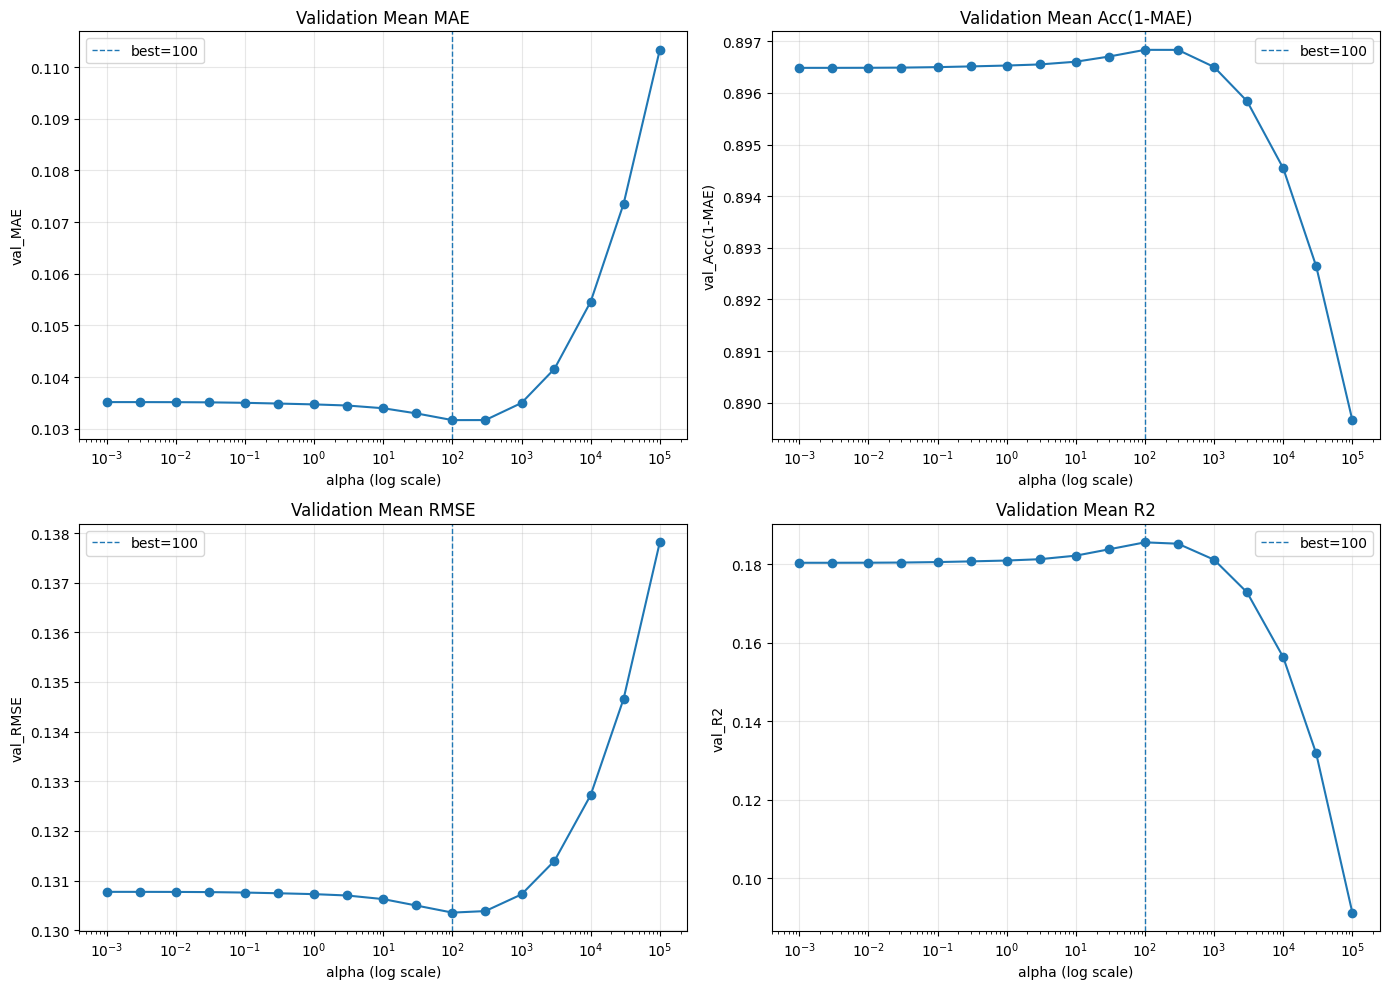

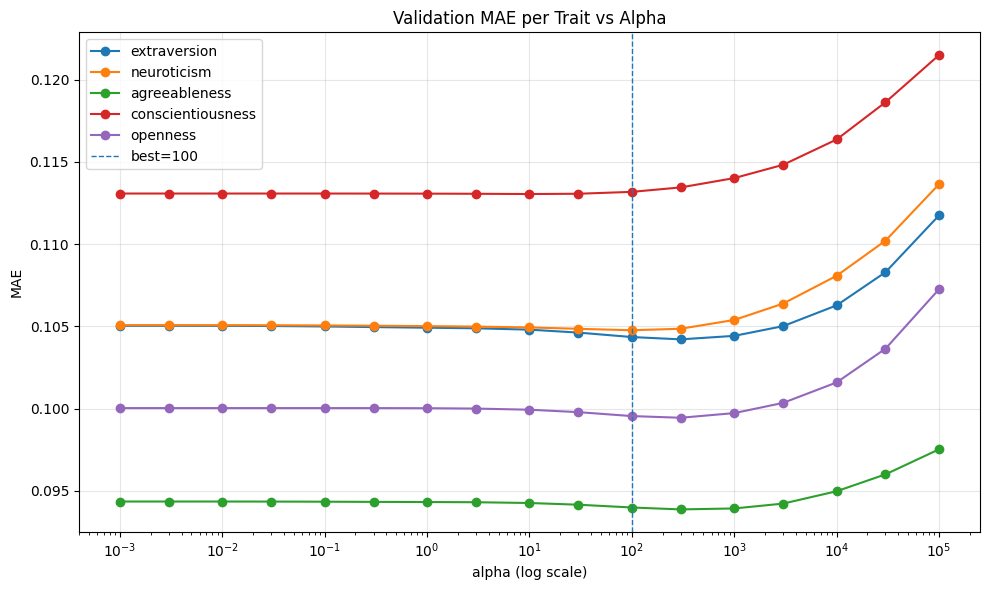

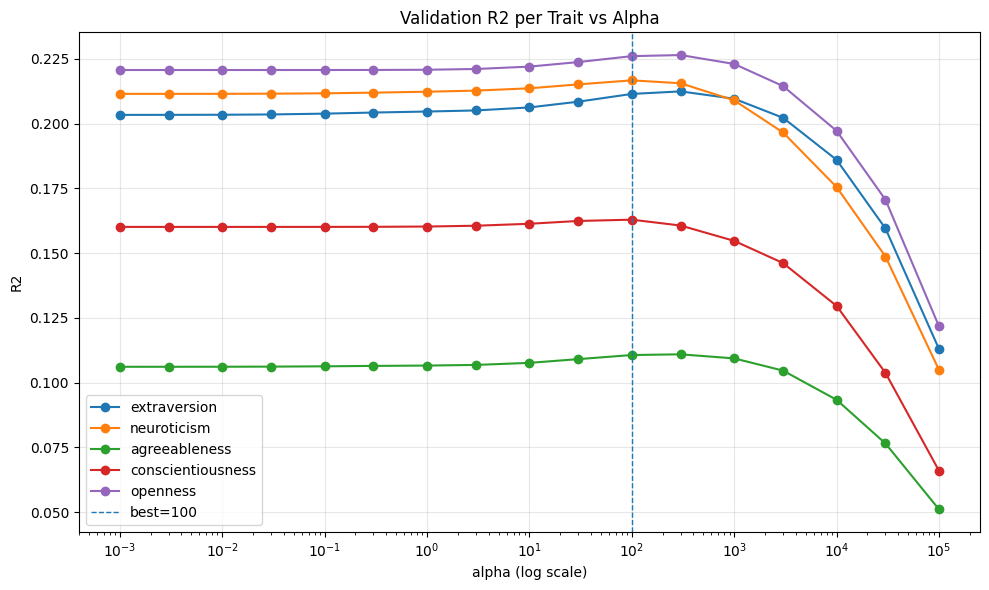

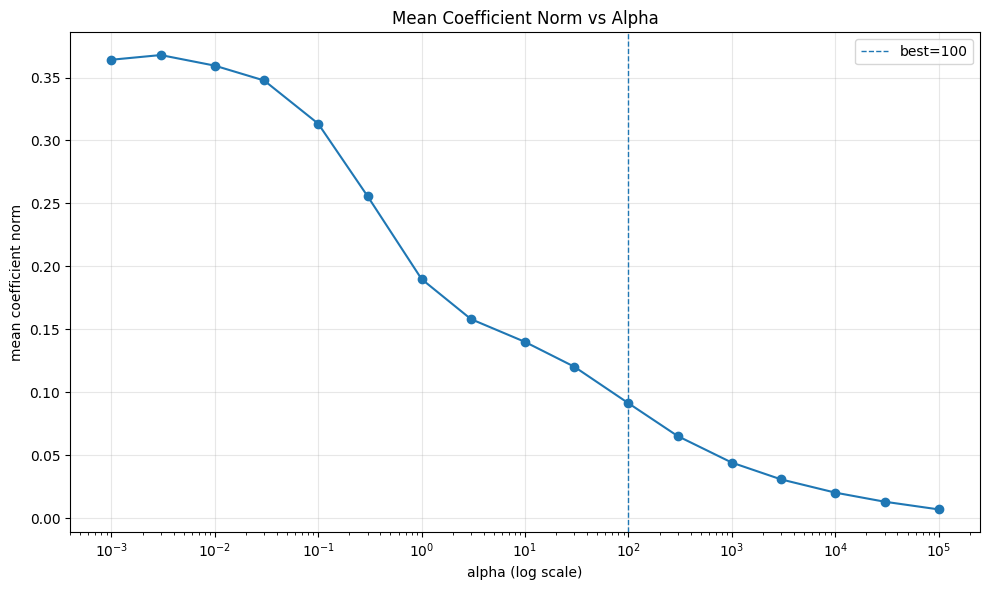

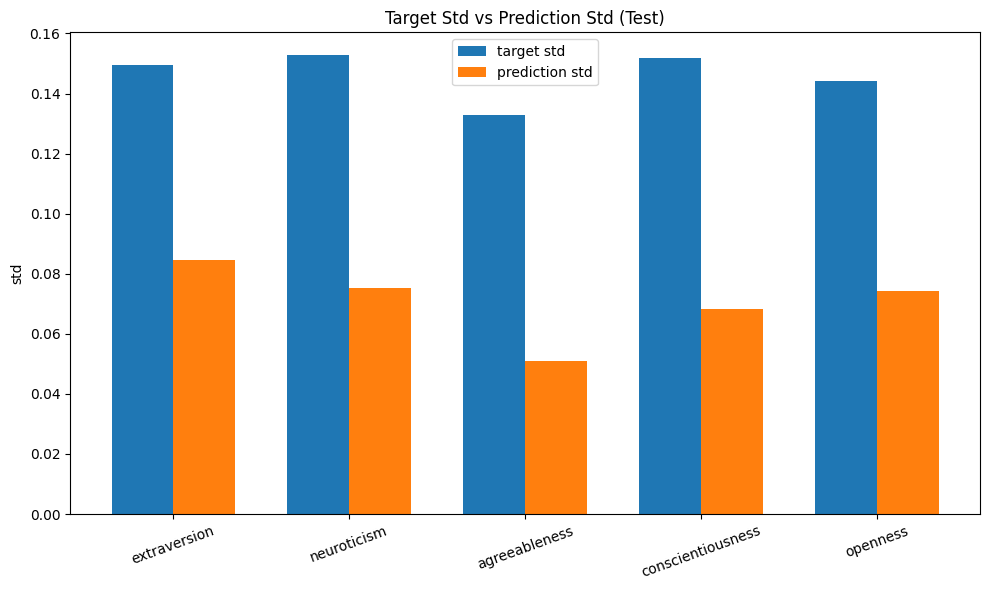

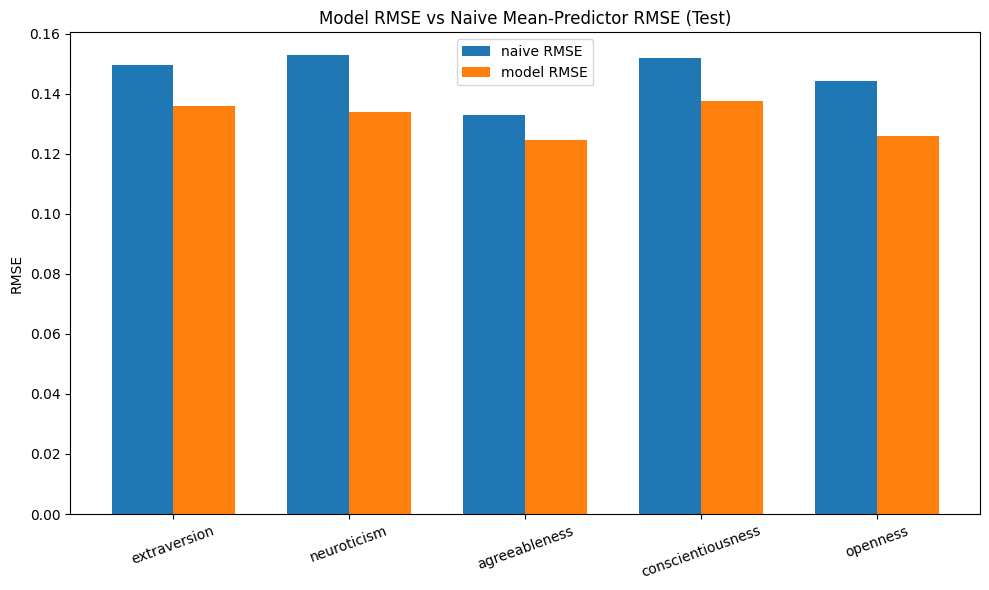

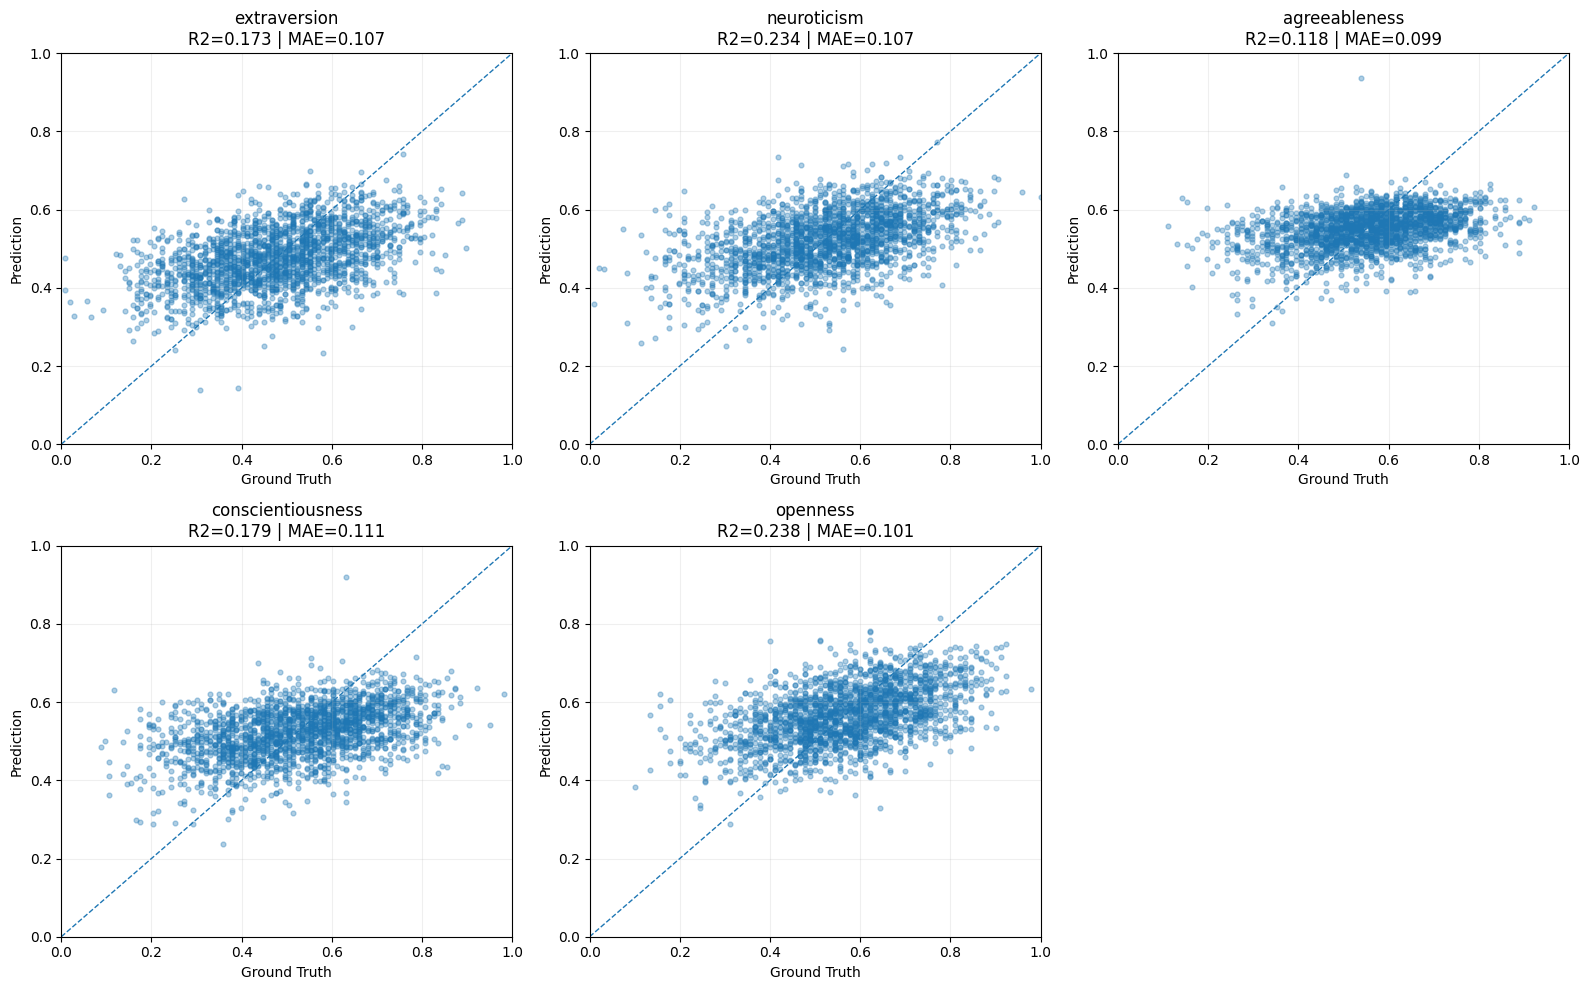

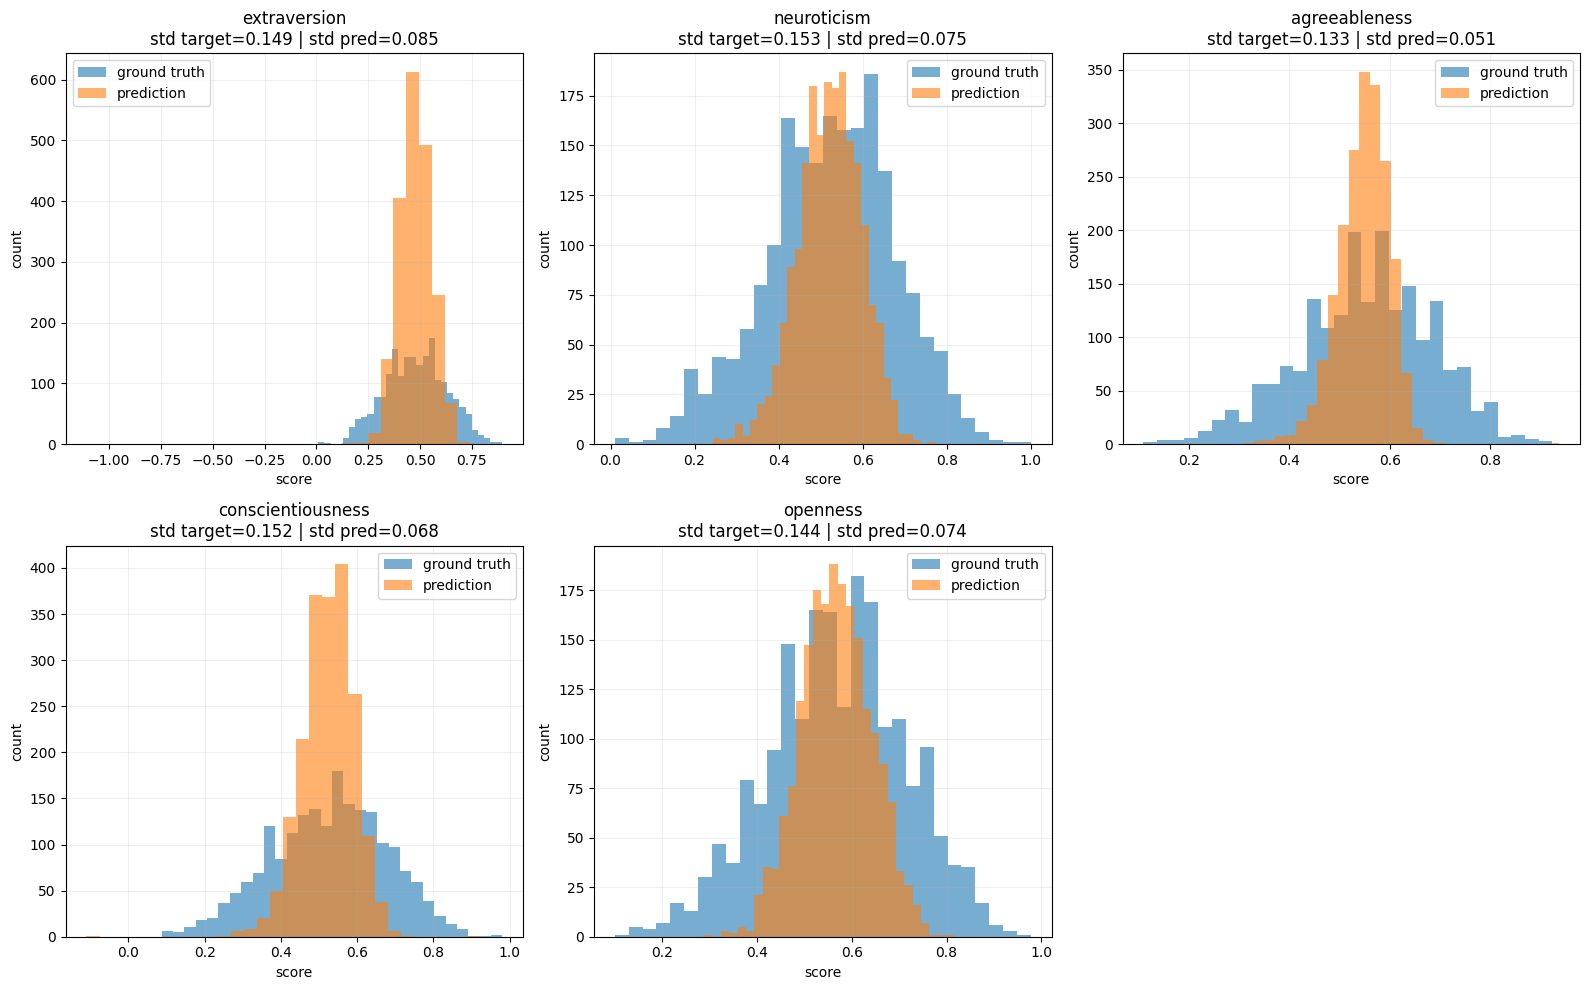


Backbone: egemaps
Split tag folder: baseline_official
Best alpha by validation mean MAE: 100.0
Best validation mean MAE: 0.103167
Best validation mean Acc(1-MAE): 0.896833
Best validation mean RMSE: 0.130353
Best validation mean R2: 0.185565
Interpretation: best alpha tidak berada di ujung kanan grid. Artinya sudah mulai terlihat titik optimal / titik balik, sehingga alpha yang terlalu besar tidak selalu memperbaiki performa.

Saved all outputs to: E:\tugas-akhir-qiqi\output\V2\baseline_official\results\egemaps
Saved figures to    : E:\tugas-akhir-qiqi\output\V2\baseline_official\results\egemaps\figures


In [15]:
# =========================
# 3) Train Ridge Regressor + Alpha Sweep + Diagnostics
# =========================

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# CONFIG
# =========================

# pilih backbone yang embedding-nya kamu reuse
BACKBONE_KEY = "egemaps"   # "wav2vec2" / "wavlm"

# NOTE:
# Aku pertahankan struktur folder mengikuti cell kamu yang sekarang.
# Kalau foldermu sebenarnya versi strict, ganti "baseline_official" -> "baseline_strict"
SPLIT_TAG = "baseline_official"

# alpha grid diperluas untuk membuktikan:
# apakah makin besar alpha terus membaik, atau ada titik balik
ALPHAS = np.array([
    1e-3, 3e-3,
    1e-2, 3e-2,
    1e-1, 3e-1,
    1, 3,
    10, 30,
    100, 300,
    1_000, 3_000,
    10_000, 30_000,
    100_000
], dtype=float)

assert "ROOT" in globals()
assert "df_train" in globals() and "df_val" in globals() and "df_test" in globals()

EMB_DIR = ROOT / "output" / "V2" / SPLIT_TAG / BACKBONE_KEY
OUT_DIR = ROOT / "output" / "V2" / SPLIT_TAG / "results" / BACKBONE_KEY
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

assert EMB_DIR.exists(), f"EMB_DIR tidak ada: {EMB_DIR}"

# =========================
# LOAD DATA
# =========================
# --- load eGeMAPS features (strict)
eg_train = pd.read_csv(EG_DIR / "train_egemaps.csv")
eg_val   = pd.read_csv(EG_DIR / "val_egemaps.csv")
eg_test  = pd.read_csv(EG_DIR / "test_egemaps.csv")

print("eGeMAPS strict train/val/test:", eg_train.shape, eg_val.shape, eg_test.shape)

# --- pastikan urutan sama dengan df_train/df_val/df_test (berdasarkan clip_id)
eg_train["clip_id"] = eg_train["clip_id"].astype(str)
eg_val["clip_id"]   = eg_val["clip_id"].astype(str)
eg_test["clip_id"]  = eg_test["clip_id"].astype(str)

eg_train = eg_train.set_index("clip_id").loc[df_train["clip_id"].astype(str)].reset_index()
eg_val   = eg_val.set_index("clip_id").loc[df_val["clip_id"].astype(str)].reset_index()
eg_test  = eg_test.set_index("clip_id").loc[df_test["clip_id"].astype(str)].reset_index()

# --- X (fitur) dan ids
train_ids = eg_train["clip_id"].astype(str).tolist()
val_ids   = eg_val["clip_id"].astype(str).tolist()
test_ids  = eg_test["clip_id"].astype(str).tolist()

X_train = eg_train.drop(columns=["clip_id"]).to_numpy(dtype=np.float32)
X_val   = eg_val.drop(columns=["clip_id"]).to_numpy(dtype=np.float32)
X_test  = eg_test.drop(columns=["clip_id"]).to_numpy(dtype=np.float32)


print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)

# =========================
# LABEL DETECTION
# =========================

def detect_label_cols(df):
    exclude = set([
        c for c in df.columns
        if any(k in c.lower() for k in [
            "clip", "id", "path", "file", "group", "split",
            "ethnicity", "gender", "avg_trait"
        ])
    ])
    num_cols = [c for c in df.columns if (c not in exclude) and pd.api.types.is_numeric_dtype(df[c])]
    if len(num_cols) < 5:
        raise ValueError(f"Kolom numerik kandidat label kurang dari 5: {num_cols}")
    return num_cols[:5]

label_cols = detect_label_cols(df_train)
print("Label cols:", label_cols)

y_train = df_train[label_cols].to_numpy(dtype=np.float32)
y_val   = df_val[label_cols].to_numpy(dtype=np.float32)
y_test  = df_test[label_cols].to_numpy(dtype=np.float32)

# =========================
# SCALE EMBEDDINGS
# =========================

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# =========================
# METRIC HELPERS
# =========================

def make_metrics_df(y_true, y_pred, split_name=""):
    mae  = mean_absolute_error(y_true, y_pred, multioutput="raw_values")
    rmse = np.sqrt(mean_squared_error(y_true, y_pred, multioutput="raw_values"))
    r2   = r2_score(y_true, y_pred, multioutput="raw_values")
    acc  = 1.0 - mae

    dfm = pd.DataFrame({
        "split": split_name,
        "trait": label_cols,
        "Acc(1-MAE)": acc,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    })

    mean_row = pd.DataFrame([{
        "split": split_name,
        "trait": "mean",
        "Acc(1-MAE)": acc.mean(),
        "MAE": mae.mean(),
        "RMSE": rmse.mean(),
        "R2": r2.mean(),
    }])

    return pd.concat([dfm, mean_row], ignore_index=True)

def show_metrics(dfm, title):
    print(f"\n== {title} ==")
    try:
        display(dfm)
    except Exception:
        print(dfm)

def extract_mean_row(dfm):
    row = dfm[dfm["trait"] == "mean"].iloc[0]
    return {
        "Acc(1-MAE)": float(row["Acc(1-MAE)"]),
        "MAE": float(row["MAE"]),
        "RMSE": float(row["RMSE"]),
        "R2": float(row["R2"]),
    }

# =========================
# ALPHA SWEEP (VALIDATION ONLY FOR MODEL SELECTION)
# =========================

alpha_rows = []
alpha_trait_rows = []

best_alpha = None
best_val_mae = np.inf
best_model = None

for a in ALPHAS:
    ridge = Ridge(alpha=float(a), random_state=42)
    model = MultiOutputRegressor(ridge)
    model.fit(X_train_s, y_train)

    pred_val = model.predict(X_val_s)
    df_val_metrics = make_metrics_df(y_val, pred_val, split_name="val")
    mean_metrics = extract_mean_row(df_val_metrics)

    # mean coefficient norm, buat lihat efek shrinkage saat alpha membesar
    coef_norms = [np.linalg.norm(est.coef_) for est in model.estimators_]
    intercept_norms = [np.linalg.norm(np.atleast_1d(est.intercept_)) for est in model.estimators_]

    alpha_rows.append({
        "alpha": float(a),
        "val_Acc(1-MAE)": mean_metrics["Acc(1-MAE)"],
        "val_MAE": mean_metrics["MAE"],
        "val_RMSE": mean_metrics["RMSE"],
        "val_R2": mean_metrics["R2"],
        "mean_coef_norm": float(np.mean(coef_norms)),
        "mean_intercept_norm": float(np.mean(intercept_norms)),
    })

    tmp_trait = df_val_metrics[df_val_metrics["trait"] != "mean"].copy()
    tmp_trait["alpha"] = float(a)
    alpha_trait_rows.append(tmp_trait)

    print(
        f"alpha={a:>9.4g} | "
        f"val MAE={mean_metrics['MAE']:.6f} | "
        f"val Acc={mean_metrics['Acc(1-MAE)']:.6f} | "
        f"val RMSE={mean_metrics['RMSE']:.6f} | "
        f"val R2={mean_metrics['R2']:.6f}"
    )

    if mean_metrics["MAE"] < best_val_mae:
        best_val_mae = mean_metrics["MAE"]
        best_alpha = float(a)
        best_model = model

alpha_sweep_df = pd.DataFrame(alpha_rows).sort_values("alpha").reset_index(drop=True)
alpha_trait_df = pd.concat(alpha_trait_rows, ignore_index=True)

print(f"\nBest alpha = {best_alpha} | best val mean MAE = {best_val_mae:.6f}")

# simpan summary alpha sweep
alpha_sweep_df.to_csv(OUT_DIR / "alpha_sweep_summary.csv", index=False)
alpha_trait_df.to_csv(OUT_DIR / "alpha_sweep_per_trait.csv", index=False)

# =========================
# FINAL EVAL WITH BEST ALPHA
# =========================

model = best_model
pred_val  = model.predict(X_val_s)
pred_test = model.predict(X_test_s)

m_val  = make_metrics_df(y_val, pred_val, split_name="val")
m_test = make_metrics_df(y_test, pred_test, split_name="test")

show_metrics(m_val,  f"{BACKBONE_KEY} | {SPLIT_TAG.upper()} | VAL")
show_metrics(m_test, f"{BACKBONE_KEY} | {SPLIT_TAG.upper()} | TEST")

# =========================
# SAVE PREDICTIONS
# =========================

pred_val_df = pd.DataFrame({
    "clip_id": val_ids,
    **{f"gt_{c}": y_val[:, i] for i, c in enumerate(label_cols)},
    **{f"pred_{c}": pred_val[:, i] for i, c in enumerate(label_cols)},
})
pred_test_df = pd.DataFrame({
    "clip_id": test_ids,
    **{f"gt_{c}": y_test[:, i] for i, c in enumerate(label_cols)},
    **{f"pred_{c}": pred_test[:, i] for i, c in enumerate(label_cols)},
})

pred_val_df.to_csv(OUT_DIR / "pred_val_full.csv", index=False)
pred_test_df.to_csv(OUT_DIR / "pred_test_full.csv", index=False)

# metrik final
m_val.to_csv(OUT_DIR / "metrics_val.csv", index=False)
m_test.to_csv(OUT_DIR / "metrics_test.csv", index=False)

# model + scaler
joblib.dump(scaler, OUT_DIR / "scaler.joblib")
joblib.dump(model,  OUT_DIR / "ridge_multioutput.joblib")

# =========================
# DIAGNOSIS: KENAPA R2 KECIL?
# =========================

# baseline naif: prediksi selalu mean train
train_mean = y_train.mean(axis=0)
naive_pred_test = np.tile(train_mean, (len(y_test), 1))

test_mae  = mean_absolute_error(y_test, pred_test, multioutput="raw_values")
test_rmse = np.sqrt(mean_squared_error(y_test, pred_test, multioutput="raw_values"))
test_r2   = r2_score(y_test, pred_test, multioutput="raw_values")

naive_mae  = mean_absolute_error(y_test, naive_pred_test, multioutput="raw_values")
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred_test, multioutput="raw_values"))
naive_r2   = r2_score(y_test, naive_pred_test, multioutput="raw_values")

target_mean = y_test.mean(axis=0)
target_std  = y_test.std(axis=0, ddof=0)
target_var  = y_test.var(axis=0, ddof=0)

pred_mean = pred_test.mean(axis=0)
pred_std  = pred_test.std(axis=0, ddof=0)

diag_rows = []
for i, trait in enumerate(label_cols):
    diag_rows.append({
        "trait": trait,
        "target_mean": float(target_mean[i]),
        "target_std": float(target_std[i]),
        "target_var": float(target_var[i]),
        "pred_mean": float(pred_mean[i]),
        "pred_std": float(pred_std[i]),
        "pred_std_over_target_std": float(pred_std[i] / target_std[i]) if target_std[i] > 0 else np.nan,
        "MAE_model": float(test_mae[i]),
        "RMSE_model": float(test_rmse[i]),
        "R2_model": float(test_r2[i]),
        "MAE_naive_train_mean": float(naive_mae[i]),
        "RMSE_naive_train_mean": float(naive_rmse[i]),
        "R2_naive_train_mean": float(naive_r2[i]),
        "RMSE_improvement_vs_naive": float(naive_rmse[i] - test_rmse[i]),
        "RMSE_over_target_std": float(test_rmse[i] / target_std[i]) if target_std[i] > 0 else np.nan,
    })

diag_df = pd.DataFrame(diag_rows)
diag_df.to_csv(OUT_DIR / "r2_diagnosis_test.csv", index=False)

try:
    display(diag_df)
except Exception:
    print(diag_df)

# =========================
# PLOTS
# =========================

# 1) mean metric sweep
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metric_map = [
    ("val_MAE", "Validation Mean MAE"),
    ("val_Acc(1-MAE)", "Validation Mean Acc(1-MAE)"),
    ("val_RMSE", "Validation Mean RMSE"),
    ("val_R2", "Validation Mean R2"),
]

for ax, (col, title) in zip(axes.flatten(), metric_map):
    ax.plot(alpha_sweep_df["alpha"], alpha_sweep_df[col], marker="o")
    ax.axvline(best_alpha, linestyle="--", linewidth=1, label=f"best={best_alpha:g}")
    ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel("alpha (log scale)")
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "alpha_sweep_mean_metrics.png", dpi=200, bbox_inches="tight")
plt.show()

# 2) per-trait MAE vs alpha
plt.figure(figsize=(10, 6))
for trait in label_cols:
    d = alpha_trait_df[alpha_trait_df["trait"] == trait].sort_values("alpha")
    plt.plot(d["alpha"], d["MAE"], marker="o", label=trait)
plt.axvline(best_alpha, linestyle="--", linewidth=1, label=f"best={best_alpha:g}")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("MAE")
plt.title("Validation MAE per Trait vs Alpha")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "alpha_sweep_per_trait_mae.png", dpi=200, bbox_inches="tight")
plt.show()

# 3) per-trait R2 vs alpha
plt.figure(figsize=(10, 6))
for trait in label_cols:
    d = alpha_trait_df[alpha_trait_df["trait"] == trait].sort_values("alpha")
    plt.plot(d["alpha"], d["R2"], marker="o", label=trait)
plt.axvline(best_alpha, linestyle="--", linewidth=1, label=f"best={best_alpha:g}")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("R2")
plt.title("Validation R2 per Trait vs Alpha")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "alpha_sweep_per_trait_r2.png", dpi=200, bbox_inches="tight")
plt.show()

# 4) coefficient norm vs alpha (melihat shrinkage ridge)
plt.figure(figsize=(10, 6))
plt.plot(alpha_sweep_df["alpha"], alpha_sweep_df["mean_coef_norm"], marker="o")
plt.axvline(best_alpha, linestyle="--", linewidth=1, label=f"best={best_alpha:g}")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("mean coefficient norm")
plt.title("Mean Coefficient Norm vs Alpha")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "alpha_sweep_coef_norm.png", dpi=200, bbox_inches="tight")
plt.show()

# 5) target std vs prediction std (diagnosis regression-to-the-mean)
x = np.arange(len(label_cols))
w = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - w/2, diag_df["target_std"], width=w, label="target std")
plt.bar(x + w/2, diag_df["pred_std"], width=w, label="prediction std")
plt.xticks(x, label_cols, rotation=20)
plt.ylabel("std")
plt.title("Target Std vs Prediction Std (Test)")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "diagnosis_target_std_vs_pred_std.png", dpi=200, bbox_inches="tight")
plt.show()

# 6) RMSE model vs RMSE naive
plt.figure(figsize=(10, 6))
plt.bar(x - w/2, diag_df["RMSE_naive_train_mean"], width=w, label="naive RMSE")
plt.bar(x + w/2, diag_df["RMSE_model"], width=w, label="model RMSE")
plt.xticks(x, label_cols, rotation=20)
plt.ylabel("RMSE")
plt.title("Model RMSE vs Naive Mean-Predictor RMSE (Test)")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "diagnosis_rmse_model_vs_naive.png", dpi=200, bbox_inches="tight")
plt.show()

# 7) scatter pred vs gt per trait
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, trait in enumerate(label_cols):
    ax = axes[i]
    ax.scatter(y_test[:, i], pred_test[:, i], s=12, alpha=0.35)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_title(f"{trait}\nR2={test_r2[i]:.3f} | MAE={test_mae[i]:.3f}")
    ax.set_xlabel("Ground Truth")
    ax.set_ylabel("Prediction")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.2)

# hapus subplot kosong kalau ada
for j in range(len(label_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(FIG_DIR / "scatter_pred_vs_gt_test.png", dpi=200, bbox_inches="tight")
plt.show()

# 8) histogram distribusi prediksi vs target
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, trait in enumerate(label_cols):
    ax = axes[i]
    ax.hist(y_test[:, i], bins=30, alpha=0.6, label="ground truth")
    ax.hist(pred_test[:, i], bins=30, alpha=0.6, label="prediction")
    ax.set_title(
        f"{trait}\nstd target={target_std[i]:.3f} | std pred={pred_std[i]:.3f}"
    )
    ax.set_xlabel("score")
    ax.set_ylabel("count")
    ax.grid(True, alpha=0.2)
    ax.legend()

for j in range(len(label_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(FIG_DIR / "hist_target_vs_prediction_test.png", dpi=200, bbox_inches="tight")
plt.show()

# =========================
# AUTO SUMMARY
# =========================

best_idx = alpha_sweep_df["val_MAE"].idxmin()
best_alpha_from_df = alpha_sweep_df.loc[best_idx, "alpha"]
is_best_at_right_edge = np.isclose(best_alpha_from_df, alpha_sweep_df["alpha"].max())

summary_lines = []
summary_lines.append(f"Backbone: {BACKBONE_KEY}")
summary_lines.append(f"Split tag folder: {SPLIT_TAG}")
summary_lines.append(f"Best alpha by validation mean MAE: {best_alpha}")
summary_lines.append(f"Best validation mean MAE: {best_val_mae:.6f}")
summary_lines.append(f"Best validation mean Acc(1-MAE): {alpha_sweep_df.loc[best_idx, 'val_Acc(1-MAE)']:.6f}")
summary_lines.append(f"Best validation mean RMSE: {alpha_sweep_df.loc[best_idx, 'val_RMSE']:.6f}")
summary_lines.append(f"Best validation mean R2: {alpha_sweep_df.loc[best_idx, 'val_R2']:.6f}")

if is_best_at_right_edge:
    summary_lines.append(
        "Interpretation: best alpha masih berada di ujung kanan grid. "
        "Ini berarti belum ada bukti kuat bahwa performa sudah mencapai titik balik. "
        "Kalau dosen ingin pembuktian lebih jauh, alpha bisa diperbesar lagi."
    )
else:
    summary_lines.append(
        "Interpretation: best alpha tidak berada di ujung kanan grid. "
        "Artinya sudah mulai terlihat titik optimal / titik balik, sehingga alpha yang terlalu besar "
        "tidak selalu memperbaiki performa."
    )



summary_text = "\n".join(summary_lines)
print("\n" + "="*80)
print(summary_text)
print("="*80)

(OUT_DIR / "ridge_analysis_summary.txt").write_text(summary_text, encoding="utf-8")

# =========================
# SAVE META
# =========================

meta = {
    "backbone": BACKBONE_KEY,
    "split_tag": SPLIT_TAG,
    "best_alpha": float(best_alpha),
    "alpha_grid": [float(a) for a in ALPHAS],
    "label_cols": label_cols,
    "shapes": {
        "train": list(X_train.shape),
        "val": list(X_val.shape),
        "test": list(X_test.shape),
    },
    "saved_files": [
        "alpha_sweep_summary.csv",
        "alpha_sweep_per_trait.csv",
        "metrics_val.csv",
        "metrics_test.csv",
        "pred_val_full.csv",
        "pred_test_full.csv",
        "r2_diagnosis_test.csv",
        "ridge_analysis_summary.txt",
        "scaler.joblib",
        "ridge_multioutput.joblib",
    ],
    "saved_figures": [
        "alpha_sweep_mean_metrics.png",
        "alpha_sweep_per_trait_mae.png",
        "alpha_sweep_per_trait_r2.png",
        "alpha_sweep_coef_norm.png",
        "diagnosis_target_std_vs_pred_std.png",
        "diagnosis_rmse_model_vs_naive.png",
        "scatter_pred_vs_gt_test.png",
        "hist_target_vs_prediction_test.png",
    ],
}
(OUT_DIR / "meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")

print(f"\nSaved all outputs to: {OUT_DIR}")
print(f"Saved figures to    : {FIG_DIR}")

# **PERBANDINGAN AKHIR BASELINE OFFICIAL**

BASE_RESULTS_DIR: E:\tugas-akhir-qiqi\output\V2\baseline_official\results
COMPARE_DIR     : E:\tugas-akhir-qiqi\output\V2\baseline_official\comparison_final

=== SUMMARY COMPARISON (MEAN METRICS) ===


,model,best_alpha,val_Acc(1-MAE),val_MAE,val_RMSE,val_R2,test_Acc(1-MAE),test_MAE,test_RMSE,test_R2,rank_by_test_MAE,rank_by_test_Acc,rank_by_test_RMSE,rank_by_test_R2,overall_rank_score,final_rank
0,wavlm,1000.0,0.905503,0.094497,0.118895,0.318673,0.903623,0.096377,0.120835,0.313054,1,1,1,1,4,1
1,hubert,1000.0,0.904053,0.095947,0.120795,0.297344,0.902526,0.097474,0.121944,0.300851,2,2,2,2,8,2
2,wav2vec2,100.0,0.902387,0.097613,0.122423,0.278639,0.901239,0.098761,0.123295,0.285255,3,3,3,3,12,3
3,egemaps,100.0,0.896833,0.103167,0.130353,0.185565,0.895163,0.104837,0.131557,0.188670,4,4,4,4,16,4


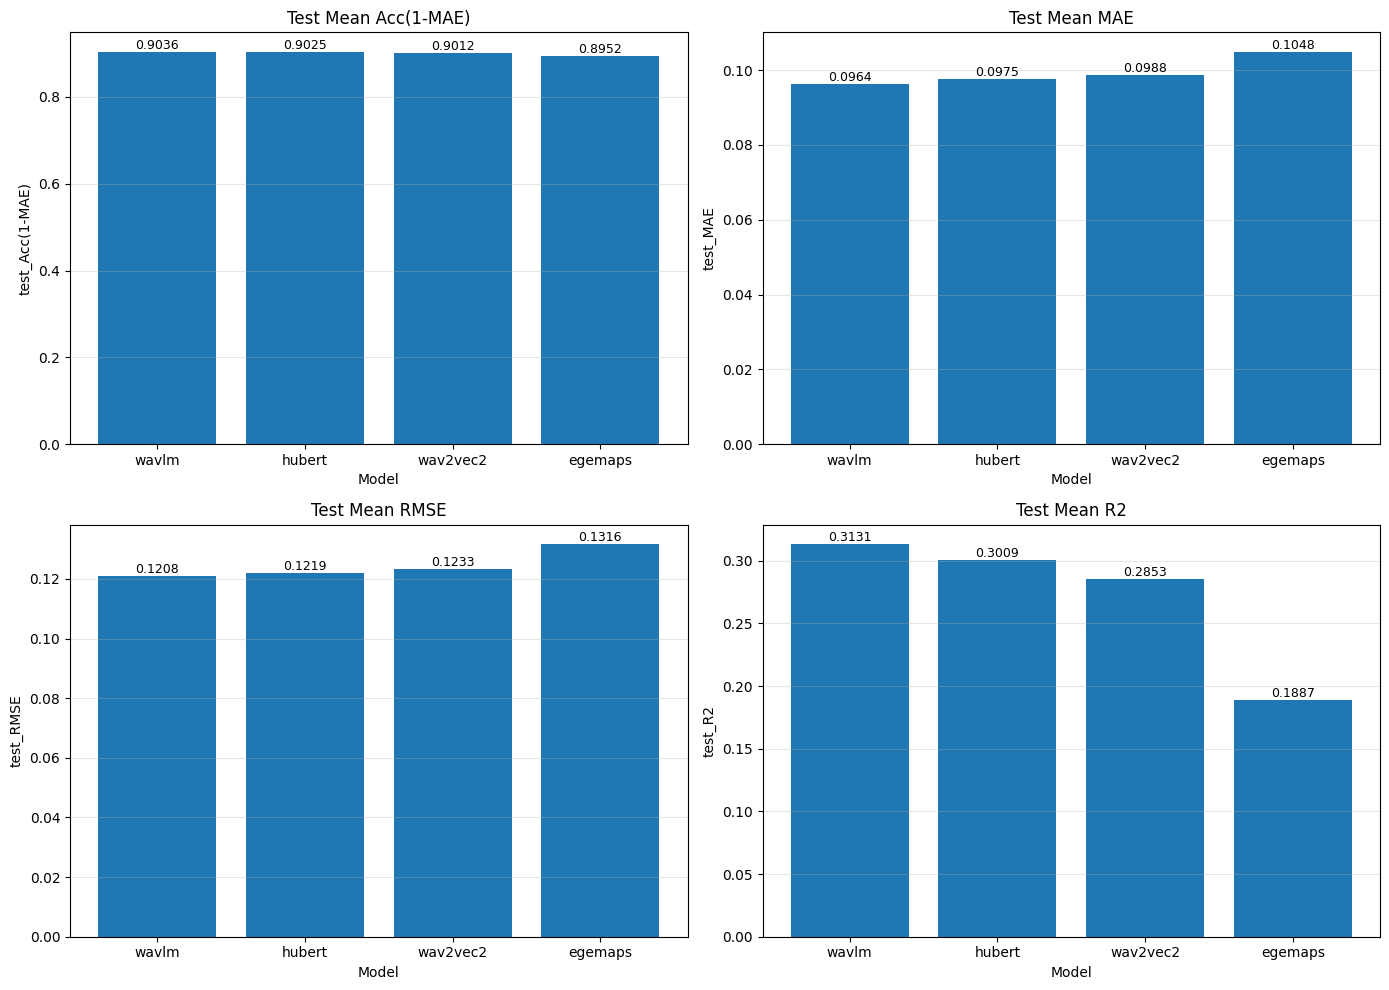

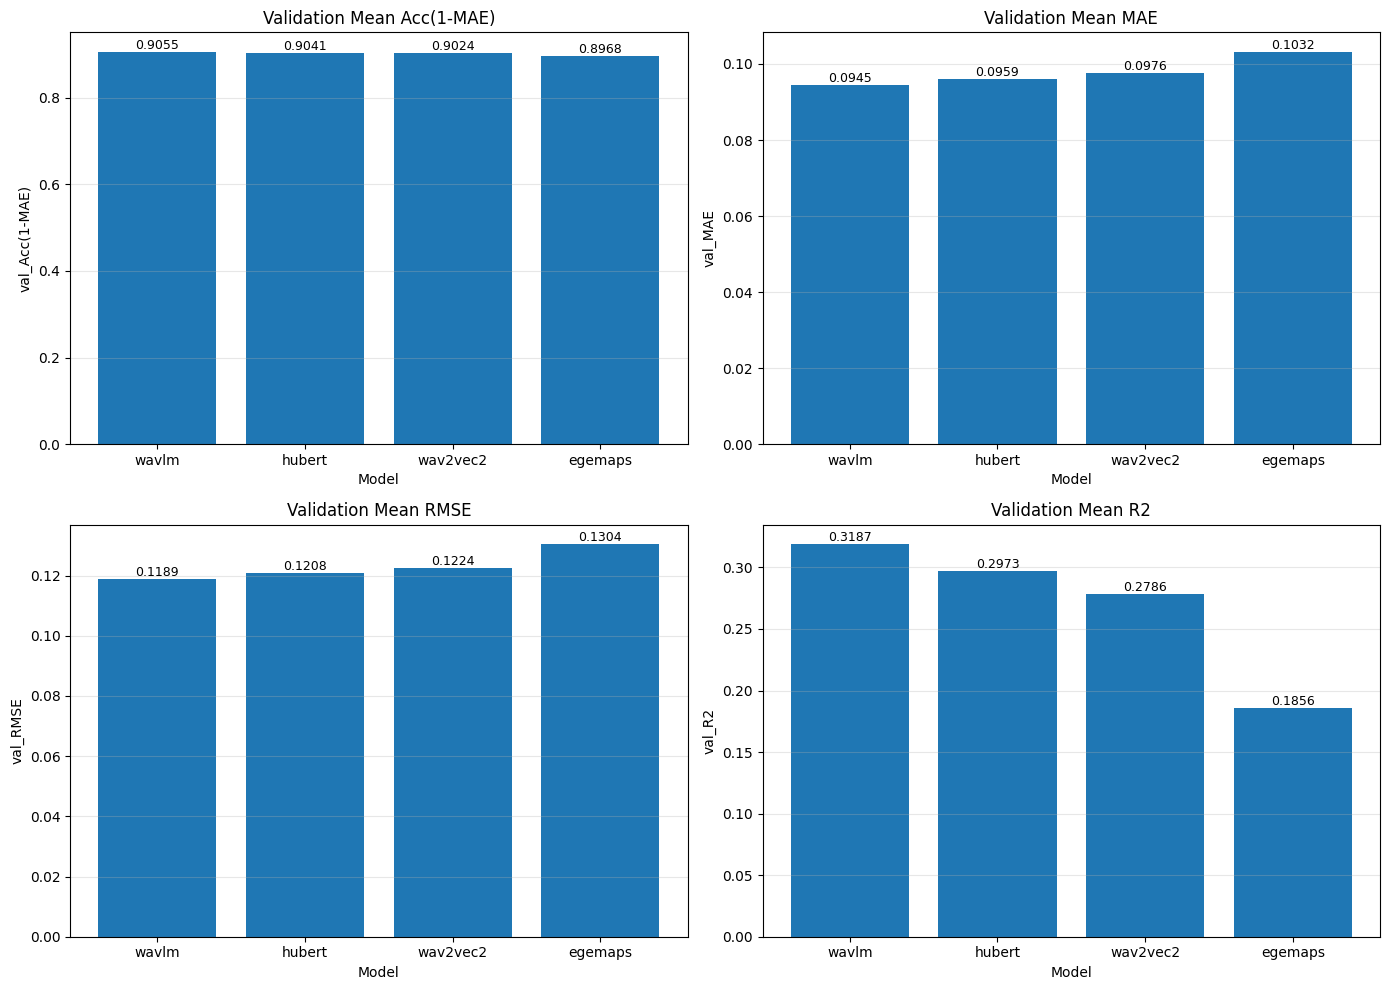

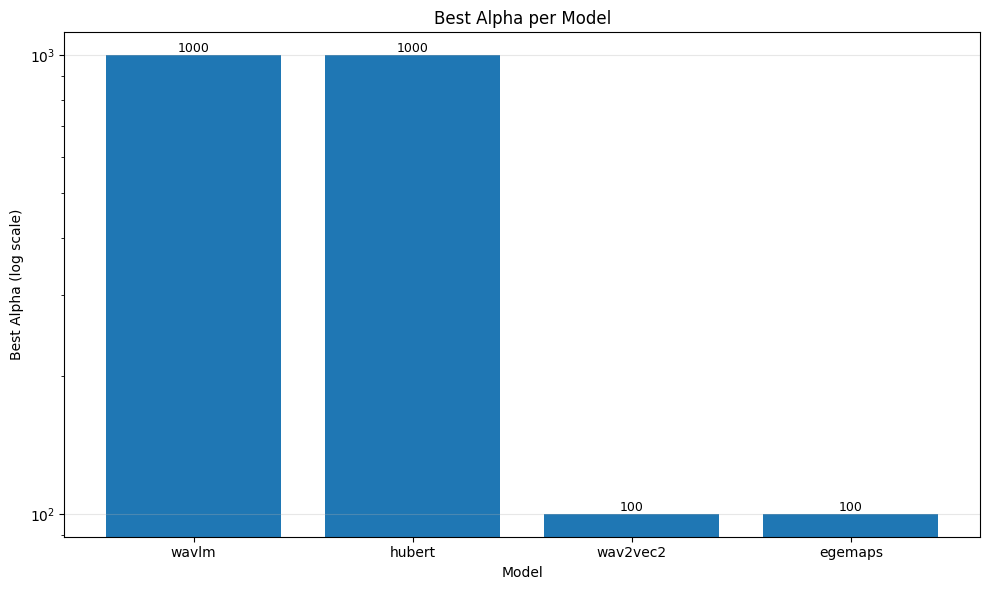

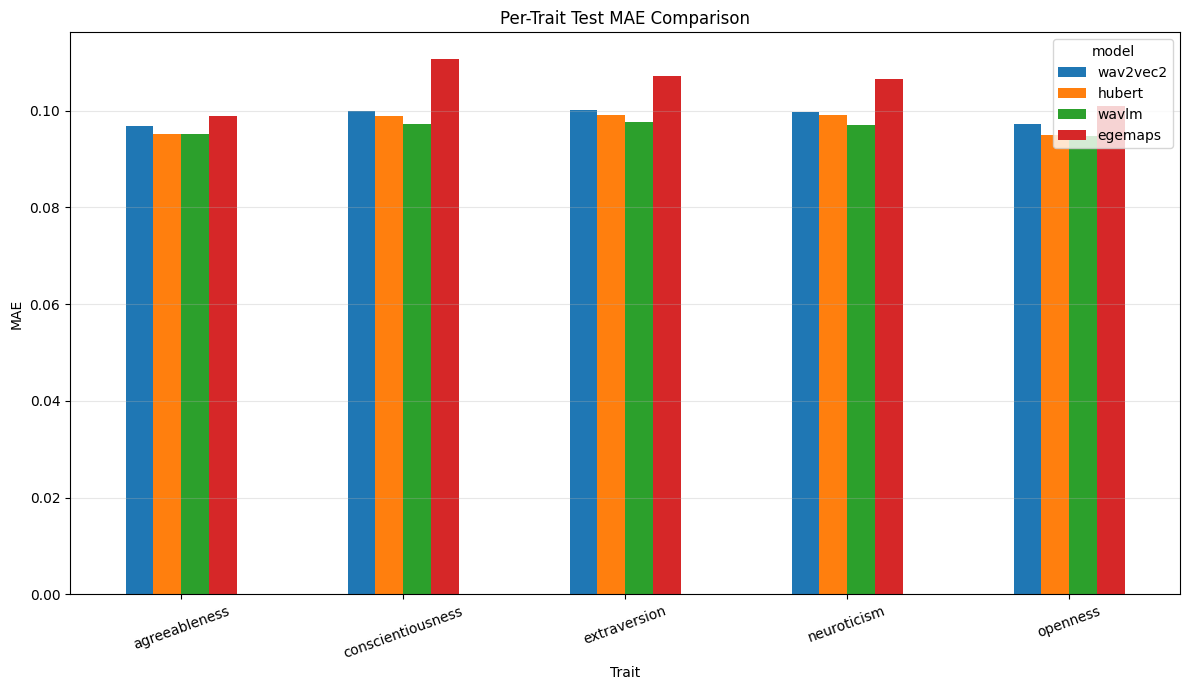

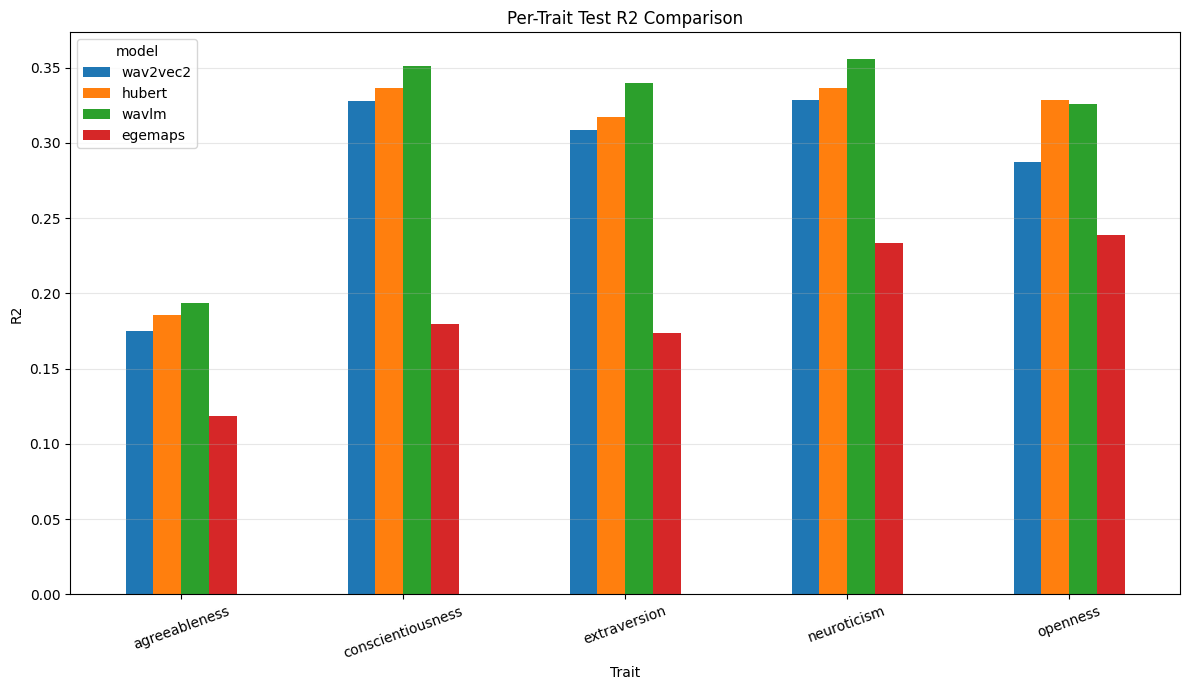

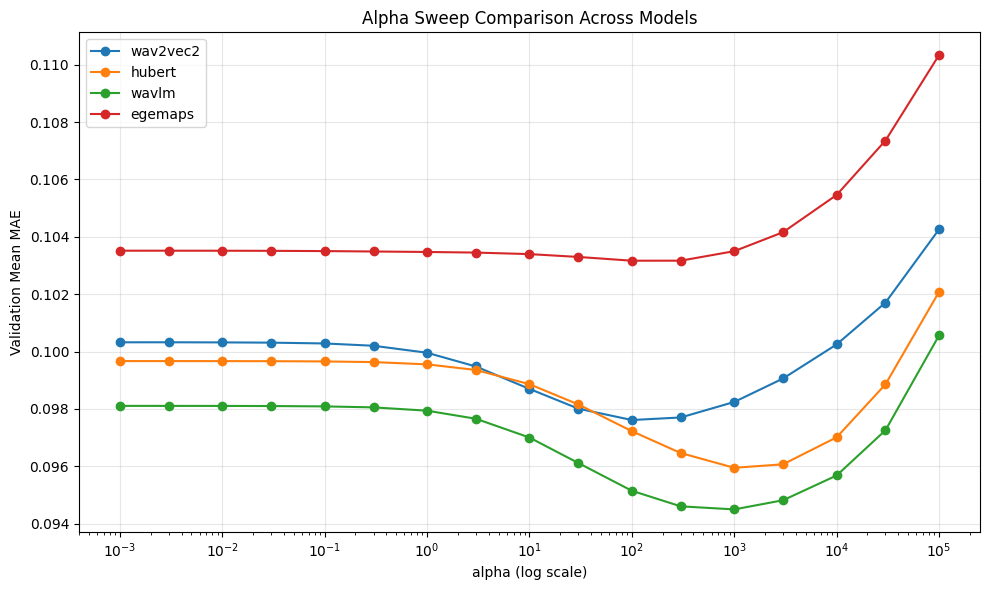


KESIMPULAN PERBANDINGAN AKHIR BASELINE

Model terbaik berdasarkan ranking gabungan metrik test adalah: wavlm.
Model ini memperoleh nilai test Acc(1-MAE) = 0.9036, MAE = 0.0964, RMSE = 0.1208, dan R2 = 0.3131.

Urutan model berdasarkan final rank:
- Peringkat 1: wavlm | test Acc=0.9036 | MAE=0.0964 | RMSE=0.1208 | R2=0.3131 | best alpha=1000.0
- Peringkat 2: hubert | test Acc=0.9025 | MAE=0.0975 | RMSE=0.1219 | R2=0.3009 | best alpha=1000.0
- Peringkat 3: wav2vec2 | test Acc=0.9012 | MAE=0.0988 | RMSE=0.1233 | R2=0.2853 | best alpha=100.0
- Peringkat 4: egemaps | test Acc=0.8952 | MAE=0.1048 | RMSE=0.1316 | R2=0.1887 | best alpha=100.0

Pemenang per trait berdasarkan test MAE:
- Trait agreeableness: terbaik = hubert (MAE=0.0952, R2=0.1859)
- Trait conscientiousness: terbaik = wavlm (MAE=0.0972, R2=0.3509)
- Trait extraversion: terbaik = wavlm (MAE=0.0977, R2=0.3396)
- Trait neuroticism: terbaik = wavlm (MAE=0.0970, R2=0.3556)
- Trait openness: terbaik = wavlm (MAE=0.0948, R2=0.3259)

I

In [16]:
# =========================
# FINAL COMPARISON: wav2vec2 vs HuBERT vs WavLM vs eGeMAPS
# + save tables, plots, and final conclusion
# =========================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

assert "ROOT" in globals()

# ---------------------------------
# CONFIG
# ---------------------------------
SPLIT_TAG = "baseline_official"   # ganti jika perlu
MODEL_KEYS = ["wav2vec2", "hubert", "wavlm", "egemaps"]

BASE_RESULTS_DIR = ROOT / "output" / "V2" / SPLIT_TAG / "results"
COMPARE_DIR = ROOT / "output" / "V2" / SPLIT_TAG / "comparison_final"
FIG_DIR = COMPARE_DIR / "figures"

COMPARE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_RESULTS_DIR:", BASE_RESULTS_DIR)
print("COMPARE_DIR     :", COMPARE_DIR)

# ---------------------------------
# HELPERS
# ---------------------------------
def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def read_metrics_mean(path: Path):
    df = pd.read_csv(path)
    # robust: ambil row mean
    mean_mask = df["trait"].astype(str).str.lower() == "mean"
    if mean_mask.sum() == 0:
        raise ValueError(f"Tidak ditemukan row 'mean' pada {path}")
    row = df.loc[mean_mask].iloc[0]
    return {
        "Acc(1-MAE)": float(row["Acc(1-MAE)"]),
        "MAE": float(row["MAE"]),
        "RMSE": float(row["RMSE"]),
        "R2": float(row["R2"]),
    }

def read_metrics_per_trait(path: Path, model_name: str, split_name: str):
    df = pd.read_csv(path).copy()
    df = df[df["trait"].astype(str).str.lower() != "mean"].copy()
    df["model"] = model_name
    df["split"] = split_name
    return df[["model", "split", "trait", "Acc(1-MAE)", "MAE", "RMSE", "R2"]]

def safe_get_best_alpha(model_dir: Path):
    meta_path = model_dir / "meta.json"
    if meta_path.exists():
        meta = load_json(meta_path)
        return meta.get("best_alpha", meta.get("alpha", np.nan))
    return np.nan

def safe_get_alpha_sweep(model_dir: Path):
    p = model_dir / "alpha_sweep_summary.csv"
    if p.exists():
        df = pd.read_csv(p)
        if "alpha" in df.columns and "val_MAE" in df.columns:
            return df
    return None

# ---------------------------------
# LOAD ALL MODEL RESULTS
# ---------------------------------
summary_rows = []
per_trait_val_all = []
per_trait_test_all = []
alpha_sweep_dict = {}

missing_models = []

for model_key in MODEL_KEYS:
    model_dir = BASE_RESULTS_DIR / model_key
    val_path = model_dir / "metrics_val.csv"
    test_path = model_dir / "metrics_test.csv"

    if not (model_dir.exists() and val_path.exists() and test_path.exists()):
        missing_models.append(model_key)
        print(f"[WARN] Hasil untuk model '{model_key}' belum lengkap, dilewati.")
        continue

    val_mean = read_metrics_mean(val_path)
    test_mean = read_metrics_mean(test_path)
    best_alpha = safe_get_best_alpha(model_dir)

    summary_rows.append({
        "model": model_key,
        "best_alpha": best_alpha,

        "val_Acc(1-MAE)": val_mean["Acc(1-MAE)"],
        "val_MAE": val_mean["MAE"],
        "val_RMSE": val_mean["RMSE"],
        "val_R2": val_mean["R2"],

        "test_Acc(1-MAE)": test_mean["Acc(1-MAE)"],
        "test_MAE": test_mean["MAE"],
        "test_RMSE": test_mean["RMSE"],
        "test_R2": test_mean["R2"],
    })

    per_trait_val_all.append(read_metrics_per_trait(val_path, model_key, "val"))
    per_trait_test_all.append(read_metrics_per_trait(test_path, model_key, "test"))

    sweep_df = safe_get_alpha_sweep(model_dir)
    if sweep_df is not None:
        alpha_sweep_dict[model_key] = sweep_df.copy()

if len(summary_rows) == 0:
    raise ValueError("Tidak ada hasil model yang bisa dibandingkan. Pastikan semua cell training/eval sebelumnya sudah dijalankan.")

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(["test_MAE", "test_RMSE", "test_R2"], ascending=[True, True, False]).reset_index(drop=True)

per_trait_val_df = pd.concat(per_trait_val_all, ignore_index=True) if per_trait_val_all else pd.DataFrame()
per_trait_test_df = pd.concat(per_trait_test_all, ignore_index=True) if per_trait_test_all else pd.DataFrame()

# ranking
summary_ranked = summary_df.copy()
summary_ranked["rank_by_test_MAE"] = summary_ranked["test_MAE"].rank(method="min", ascending=True).astype(int)
summary_ranked["rank_by_test_Acc"] = summary_ranked["test_Acc(1-MAE)"].rank(method="min", ascending=False).astype(int)
summary_ranked["rank_by_test_RMSE"] = summary_ranked["test_RMSE"].rank(method="min", ascending=True).astype(int)
summary_ranked["rank_by_test_R2"] = summary_ranked["test_R2"].rank(method="min", ascending=False).astype(int)

# overall score sederhana untuk ranking gabungan
summary_ranked["overall_rank_score"] = (
    summary_ranked["rank_by_test_MAE"] +
    summary_ranked["rank_by_test_Acc"] +
    summary_ranked["rank_by_test_RMSE"] +
    summary_ranked["rank_by_test_R2"]
)
summary_ranked = summary_ranked.sort_values(
    ["overall_rank_score", "test_MAE", "test_RMSE", "test_R2"],
    ascending=[True, True, True, False]
).reset_index(drop=True)
summary_ranked["final_rank"] = np.arange(1, len(summary_ranked) + 1)

# ---------------------------------
# DISPLAY + SAVE TABLES
# ---------------------------------
print("\n=== SUMMARY COMPARISON (MEAN METRICS) ===")
try:
    display(summary_ranked)
except Exception:
    print(summary_ranked)

summary_df.to_csv(COMPARE_DIR / "comparison_summary_mean_metrics.csv", index=False)
summary_ranked.to_csv(COMPARE_DIR / "comparison_summary_ranked.csv", index=False)
if not per_trait_val_df.empty:
    per_trait_val_df.to_csv(COMPARE_DIR / "comparison_per_trait_val.csv", index=False)
if not per_trait_test_df.empty:
    per_trait_test_df.to_csv(COMPARE_DIR / "comparison_per_trait_test.csv", index=False)

# ---------------------------------
# PLOT 1: mean metrics (TEST)
# ---------------------------------
plot_df = summary_ranked.copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_to_plot = [
    ("test_Acc(1-MAE)", "Test Mean Acc(1-MAE)"),
    ("test_MAE", "Test Mean MAE"),
    ("test_RMSE", "Test Mean RMSE"),
    ("test_R2", "Test Mean R2"),
]

for ax, (col, title) in zip(axes.flatten(), metrics_to_plot):
    ax.bar(plot_df["model"], plot_df[col])
    ax.set_title(title)
    ax.set_xlabel("Model")
    ax.set_ylabel(col)
    ax.grid(True, axis="y", alpha=0.3)

    # angka di atas bar
    vals = plot_df[col].tolist()
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "comparison_mean_metrics_test.png", dpi=200, bbox_inches="tight")
plt.show()

# ---------------------------------
# PLOT 2: mean metrics (VAL)
# ---------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_to_plot_val = [
    ("val_Acc(1-MAE)", "Validation Mean Acc(1-MAE)"),
    ("val_MAE", "Validation Mean MAE"),
    ("val_RMSE", "Validation Mean RMSE"),
    ("val_R2", "Validation Mean R2"),
]

for ax, (col, title) in zip(axes.flatten(), metrics_to_plot_val):
    ax.bar(plot_df["model"], plot_df[col])
    ax.set_title(title)
    ax.set_xlabel("Model")
    ax.set_ylabel(col)
    ax.grid(True, axis="y", alpha=0.3)

    vals = plot_df[col].tolist()
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "comparison_mean_metrics_val.png", dpi=200, bbox_inches="tight")
plt.show()

# ---------------------------------
# PLOT 3: best alpha comparison
# ---------------------------------
if plot_df["best_alpha"].notna().any():
    plt.figure(figsize=(10, 6))
    plt.bar(plot_df["model"], plot_df["best_alpha"])
    plt.yscale("log")
    plt.xlabel("Model")
    plt.ylabel("Best Alpha (log scale)")
    plt.title("Best Alpha per Model")
    plt.grid(True, axis="y", alpha=0.3)

    for i, v in enumerate(plot_df["best_alpha"].tolist()):
        if pd.notna(v):
            plt.text(i, v, f"{v:g}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "comparison_best_alpha.png", dpi=200, bbox_inches="tight")
    plt.show()

# ---------------------------------
# PLOT 4: per-trait TEST MAE
# ---------------------------------
if not per_trait_test_df.empty:
    pivot_mae = per_trait_test_df.pivot(index="trait", columns="model", values="MAE")
    pivot_mae = pivot_mae[[m for m in MODEL_KEYS if m in pivot_mae.columns]]

    ax = pivot_mae.plot(kind="bar", figsize=(12, 7))
    ax.set_title("Per-Trait Test MAE Comparison")
    ax.set_xlabel("Trait")
    ax.set_ylabel("MAE")
    ax.grid(True, axis="y", alpha=0.3)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "comparison_per_trait_test_mae.png", dpi=200, bbox_inches="tight")
    plt.show()

# ---------------------------------
# PLOT 5: per-trait TEST R2
# ---------------------------------
if not per_trait_test_df.empty:
    pivot_r2 = per_trait_test_df.pivot(index="trait", columns="model", values="R2")
    pivot_r2 = pivot_r2[[m for m in MODEL_KEYS if m in pivot_r2.columns]]

    ax = pivot_r2.plot(kind="bar", figsize=(12, 7))
    ax.set_title("Per-Trait Test R2 Comparison")
    ax.set_xlabel("Trait")
    ax.set_ylabel("R2")
    ax.grid(True, axis="y", alpha=0.3)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "comparison_per_trait_test_r2.png", dpi=200, bbox_inches="tight")
    plt.show()

# ---------------------------------
# PLOT 6: alpha sweep overlay (VAL MAE)
# ---------------------------------
if len(alpha_sweep_dict) > 0:
    plt.figure(figsize=(10, 6))
    for model_key, df_sw in alpha_sweep_dict.items():
        d = df_sw.sort_values("alpha")
        plt.plot(d["alpha"], d["val_MAE"], marker="o", label=model_key)
    plt.xscale("log")
    plt.xlabel("alpha (log scale)")
    plt.ylabel("Validation Mean MAE")
    plt.title("Alpha Sweep Comparison Across Models")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "comparison_alpha_sweep_val_mae.png", dpi=200, bbox_inches="tight")
    plt.show()

# ---------------------------------
# AUTO CONCLUSION
# ---------------------------------
best_model_row = summary_ranked.iloc[0]
best_model = best_model_row["model"]

# trait winners by test MAE
trait_winner_lines = []
if not per_trait_test_df.empty:
    trait_winners = (
        per_trait_test_df
        .sort_values(["trait", "MAE"], ascending=[True, True])
        .groupby("trait", as_index=False)
        .first()[["trait", "model", "MAE", "R2"]]
    )
    trait_winners.to_csv(COMPARE_DIR / "comparison_trait_winners_test.csv", index=False)

    for _, row in trait_winners.iterrows():
        trait_winner_lines.append(
            f"- Trait {row['trait']}: terbaik = {row['model']} "
            f"(MAE={row['MAE']:.4f}, R2={row['R2']:.4f})"
        )
else:
    trait_winners = pd.DataFrame()

# cek apakah best alpha ada di ujung kanan grid
alpha_edge_lines = []
for model_key, df_sw in alpha_sweep_dict.items():
    d = df_sw.sort_values("alpha").reset_index(drop=True)
    best_idx = d["val_MAE"].idxmin()
    best_alpha = d.loc[best_idx, "alpha"]
    is_edge = np.isclose(best_alpha, d["alpha"].max())
    if is_edge:
        alpha_edge_lines.append(
            f"- {model_key}: best alpha masih di ujung kanan grid ({best_alpha:g}), "
            f"jadi masih ada indikasi bahwa alpha yang lebih besar mungkin masih perlu diuji."
        )
    else:
        alpha_edge_lines.append(
            f"- {model_key}: best alpha = {best_alpha:g} tidak berada di ujung kanan grid, "
            f"sehingga sudah tampak adanya titik optimal / titik balik performa."
        )

conclusion_lines = []
conclusion_lines.append("KESIMPULAN PERBANDINGAN AKHIR BASELINE")
conclusion_lines.append("=" * 70)
conclusion_lines.append("")
conclusion_lines.append(f"Model terbaik berdasarkan ranking gabungan metrik test adalah: {best_model}.")
conclusion_lines.append(
    f"Model ini memperoleh nilai test Acc(1-MAE) = {best_model_row['test_Acc(1-MAE)']:.4f}, "
    f"MAE = {best_model_row['test_MAE']:.4f}, "
    f"RMSE = {best_model_row['test_RMSE']:.4f}, "
    f"dan R2 = {best_model_row['test_R2']:.4f}."
)
conclusion_lines.append("")
conclusion_lines.append("Urutan model berdasarkan final rank:")
for _, row in summary_ranked.iterrows():
    conclusion_lines.append(
        f"- Peringkat {int(row['final_rank'])}: {row['model']} | "
        f"test Acc={row['test_Acc(1-MAE)']:.4f} | "
        f"MAE={row['test_MAE']:.4f} | "
        f"RMSE={row['test_RMSE']:.4f} | "
        f"R2={row['test_R2']:.4f} | "
        f"best alpha={row['best_alpha'] if pd.notna(row['best_alpha']) else 'NA'}"
    )

if len(trait_winner_lines) > 0:
    conclusion_lines.append("")
    conclusion_lines.append("Pemenang per trait berdasarkan test MAE:")
    conclusion_lines.extend(trait_winner_lines)

if len(alpha_edge_lines) > 0:
    conclusion_lines.append("")
    conclusion_lines.append("Interpretasi hasil tuning alpha:")
    conclusion_lines.extend(alpha_edge_lines)

conclusion_lines.append("")
conclusion_lines.append("Catatan interpretasi:")
conclusion_lines.append(
    "- Nilai Acc(1-MAE) yang tinggi menunjukkan error absolut rata-rata relatif kecil pada skala target 0 sampai 1."
)
conclusion_lines.append(
    "- Nilai R2 yang tetap rendah menunjukkan bahwa meskipun error absolut kecil, model belum mampu menjelaskan variasi target secara kuat."
)
conclusion_lines.append(
    "- Kondisi ini dapat terjadi karena distribusi label sempit, prediksi cenderung mendekati rata-rata, atau varians target relatif kecil."
)
conclusion_lines.append(
    "- Dengan demikian, evaluasi akhir sebaiknya tidak hanya melihat Acc(1-MAE), tetapi juga MAE, RMSE, dan R2 secara bersama-sama."
)

conclusion_text = "\n".join(conclusion_lines)
print("\n" + conclusion_text)

(COMPARE_DIR / "final_conclusion.txt").write_text(conclusion_text, encoding="utf-8")

# ---------------------------------
# OPTIONAL: short paragraph for thesis/report
# ---------------------------------
best_row = summary_ranked.iloc[0]
second_row = summary_ranked.iloc[1] if len(summary_ranked) > 1 else None

narasi = []
narasi.append(
    f"Berdasarkan hasil perbandingan empat model baseline, model {best_row['model']} menunjukkan "
    f"kinerja terbaik pada data uji dengan nilai Acc(1-MAE) sebesar {best_row['test_Acc(1-MAE)']:.4f}, "
    f"MAE sebesar {best_row['test_MAE']:.4f}, RMSE sebesar {best_row['test_RMSE']:.4f}, "
    f"dan R2 sebesar {best_row['test_R2']:.4f}."
)

if second_row is not None:
    narasi.append(
        f"Model dengan performa berikutnya adalah {second_row['model']} dengan MAE sebesar "
        f"{second_row['test_MAE']:.4f} dan R2 sebesar {second_row['test_R2']:.4f}."
    )

narasi.append(
    "Secara umum, model berbasis SSL speech representation menunjukkan performa yang lebih baik "
    "dibandingkan eGeMAPS pada evaluasi agregat. Namun demikian, nilai R2 seluruh model masih relatif terbatas, "
    "yang mengindikasikan bahwa prediksi sudah cukup dekat secara absolut, tetapi kemampuan model dalam "
    "menjelaskan variasi target masih belum tinggi."
)

narasi_text = "\n".join(narasi)
print("\n=== NARASI SINGKAT UNTUK LAPORAN ===\n")
print(narasi_text)

(COMPARE_DIR / "narasi_singkat_untuk_laporan.txt").write_text(narasi_text, encoding="utf-8")

print("\nSaved all comparison artifacts to:", COMPARE_DIR)
print("Saved figures to:", FIG_DIR)

if len(missing_models) > 0:
    print("\n[INFO] Model yang belum ikut perbandingan karena file belum lengkap:", missing_models)